# 난임환자 대상 임신 성공 여부 예측 AI 프로그램

## 📋 목차

| 번호 | 섹션 | 설명 |
|:---:|---|---|
| 0 | [라이브러리 Import](#0-라이브러리-import) | 분석에 필요한 패키지 로드 |
| 1 | [데이터 불러오기](#1-데이터-불러오기) | train / test / submission CSV 로드 |
| 2 | [EDA 및 데이터 전처리](#2-eda-확인-후-데이터-전처리) | 기본 EDA, 결측치·이상치 분석 및 처리 |
| 2-1 | [기본 통계 및 Target 분석](#2-1-기본-통계-및-target-분석) | 데이터 통계 요약, 타겟 분포 확인 |
| 2-2 | [변수 타입별 EDA](#2-2-변수-타입별-eda) | 문자형·연속형·범주형 변수 시각화 분석 |
| 2-3 | [결측치 분석](#2-3-결측치-분석) | 결측치 현황 및 분포 파악 |
| 2-4 | [이상치 및 다중공선성 분석](#2-4-이상치-및-다중공선성-분석) | IQR 기반 이상치, 왜도, 상관관계 히트맵 |
| 3 | [최종 전처리 파이프라인](#3-최종-전처리-파이프라인) | 결측치·희소범주 처리, 파생변수 생성 |
| 4 | [모델 학습](#4-모델-학습) | 인코딩 → Optuna 튜닝 → OOF 스태킹 → SHAP → 앙상블 |
| 4-1 | [인코딩 준비](#4-1-인코딩-준비) | 라벨 인코딩 + OOF 타겟 인코딩 |
| 4-2 | [Optuna 하이퍼파라미터 최적화](#4-2-optuna-하이퍼파라미터-최적화) | LGB / XGB / CatBoost 베이지안 서치 |
| 4-3 | [10-Fold × 3-Seed OOF 스태킹](#4-3-10-fold--3-seed-oof-스태킹) | 베이스 모델 OOF 예측 생성 |
| 4-4 | [SHAP 분석 + Noise Pruning](#4-4-shap-분석--noise-pruning) | 변수 중요도 분석 및 노이즈 변수 제거 |
| 4-5 | [스태킹 메타 모델](#4-5-스태킹-메타-모델) | 로지스틱 회귀 메타 모델로 최종 앙상블 |
| 5 | [최종 제출 파일 생성](#5-최종-제출-파일-생성) | submission CSV 저장 |


## 0. 라이브러리 import

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import shap
import xgboost as xgb

from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

from sklearn.model_selection import StratifiedKFold
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')

In [9]:
# 한글 깨짐 방지
import platform

if platform.system() == 'Darwin':
    font_name = 'AppleGothic'
else:
    font_name = 'Malgun Gothic'

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font=font_name)

## 1. 데이터 불러오기

In [10]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')
submission = pd.read_csv('sample_submission.csv')

display(train.head())
display(test.head())
display(submission.head())

,ID,시술 시기 코드,시술 당시 나이,임신 시도 또는 마지막 임신 경과 연수,시술 유형,특정 시술 유형,배란 자극 여부,배란 유도 유형,단일 배아 이식 여부,착상 전 유전 검사 사용 여부,...,기증 배아 사용 여부,대리모 여부,PGD 시술 여부,PGS 시술 여부,난자 채취 경과일,난자 해동 경과일,난자 혼합 경과일,배아 이식 경과일,배아 해동 경과일,임신 성공 여부
0,TRAIN_000000,TRZKPL,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0
1,TRAIN_000001,TRYBLT,만45-50세,NaN,IVF,ICSI,0,알 수 없음,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
2,TRAIN_000002,TRVNRY,만18-34세,NaN,IVF,IVF,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,2.0,NaN,0
3,TRAIN_000003,TRJXFG,만35-37세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
4,TRAIN_000004,TRVNRY,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0


,ID,시술 시기 코드,시술 당시 나이,임신 시도 또는 마지막 임신 경과 연수,시술 유형,특정 시술 유형,배란 자극 여부,배란 유도 유형,단일 배아 이식 여부,착상 전 유전 검사 사용 여부,...,신선 배아 사용 여부,기증 배아 사용 여부,대리모 여부,PGD 시술 여부,PGS 시술 여부,난자 채취 경과일,난자 해동 경과일,난자 혼합 경과일,배아 이식 경과일,배아 해동 경과일
0,TEST_00000,TRYBLT,만35-37세,NaN,IVF,IVF,1,기록되지 않은 시행,0.0,NaN,...,1.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN
1,TEST_00001,TRDQAZ,만18-34세,NaN,IVF,IVF,1,기록되지 않은 시행,0.0,NaN,...,1.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN
2,TEST_00002,TRCMWS,만40-42세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,1.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN
3,TEST_00003,TRJXFG,만40-42세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,1.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,2.0,NaN
4,TEST_00004,TRJXFG,만35-37세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,1.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,5.0,NaN


,ID,probability
0,TEST_00000,0.024318
1,TEST_00001,0.024872
2,TEST_00002,0.127907
3,TEST_00003,0.086950
4,TEST_00004,0.522649


## 2. EDA 확인 및 데이터 전처리

### 2-1. 기본 통계 및 Target 분석

> 학습 데이터의 기초 통계량과 타겟 변수(`임신 성공 여부`)의 클래스 분포를 확인합니다.

In [11]:
# 학습 데이터 통계
train.describe()

,임신 시도 또는 마지막 임신 경과 연수,배란 자극 여부,단일 배아 이식 여부,착상 전 유전 검사 사용 여부,착상 전 유전 진단 사용 여부,남성 주 불임 원인,남성 부 불임 원인,여성 주 불임 원인,여성 부 불임 원인,부부 주 불임 원인,...,기증 배아 사용 여부,대리모 여부,PGD 시술 여부,PGS 시술 여부,난자 채취 경과일,난자 해동 경과일,난자 혼합 경과일,배아 이식 경과일,배아 해동 경과일,임신 성공 여부
count,9370.000000,256351.000000,250060.000000,2718.0,250060.000000,256351.000000,256351.000000,256351.000000,256351.000000,256351.000000,...,250060.000000,250060.000000,2179.0,1929.0,198863.0,1436.000000,202616.000000,212785.000000,40369.000000,256351.000000
mean,9.270651,0.771286,0.233476,1.0,0.012781,0.028516,0.013115,0.030724,0.012432,0.033068,...,0.009830,0.004195,1.0,1.0,0.0,0.001393,0.005385,3.254741,0.045629,0.258349
std,3.550313,0.420005,0.423043,0.0,0.112328,0.166441,0.113767,0.172568,0.110805,0.178814,...,0.098656,0.064633,0.0,0.0,0.0,0.037307,0.111504,1.715697,0.418672,0.437728
min,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.0,1.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,1.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.0,1.0,0.0,0.000000,0.000000,2.000000,0.000000,0.000000
50%,9.000000,1.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.0,1.0,0.0,0.000000,0.000000,3.000000,0.000000,0.000000
75%,11.000000,1.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.0,1.0,0.0,0.000000,0.000000,5.000000,0.000000,1.000000
max,20.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.0,1.0,0.0,1.000000,7.000000,7.000000,7.000000,1.000000


In [12]:
# 학습 데이터 정보
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 256351 entries, 0 to 256350
Data columns (total 69 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     256351 non-null  str    
 1   시술 시기 코드               256351 non-null  str    
 2   시술 당시 나이               256351 non-null  str    
 3   임신 시도 또는 마지막 임신 경과 연수  9370 non-null    float64
 4   시술 유형                  256351 non-null  str    
 5   특정 시술 유형               256349 non-null  str    
 6   배란 자극 여부               256351 non-null  int64  
 7   배란 유도 유형               256351 non-null  str    
 8   단일 배아 이식 여부            250060 non-null  float64
 9   착상 전 유전 검사 사용 여부       2718 non-null    float64
 10  착상 전 유전 진단 사용 여부       250060 non-null  float64
 11  남성 주 불임 원인             256351 non-null  int64  
 12  남성 부 불임 원인             256351 non-null  int64  
 13  여성 주 불임 원인             256351 non-null  int64  
 14  여성 부 불임 원인             256351 non-null  int64  

target_counts ['0'] = 190123  target_counts ['1'] = 66228
target_ratio  ['0'] = 74.17 %  target_ratio  ['1'] = 25.83 %


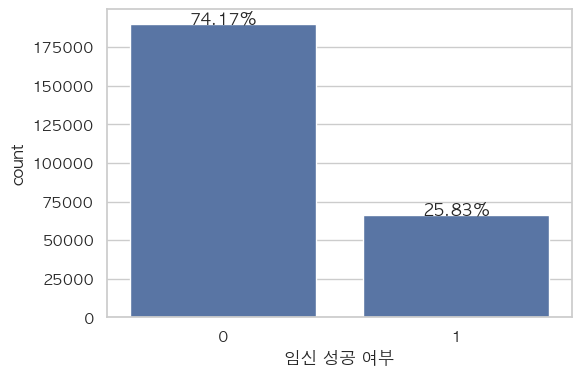

In [13]:
# Target 데이터 분석
target_counts = train['임신 성공 여부'].value_counts()
target_ratio  = round(train['임신 성공 여부'].value_counts(normalize=True) * 100, 2)

print(f"target_counts ['0'] = {target_counts[0]}  target_counts ['1'] = {target_counts[1]}")
print(f"target_ratio  ['0'] = {target_ratio[0]} %  target_ratio  ['1'] = {target_ratio[1]} %")

plt.figure(figsize=(6, 4))
ax = sns.countplot(x='임신 성공 여부', data=train)
for i, patch in enumerate(ax.patches):
    height = patch.get_height()
    ax.text(
        patch.get_x() + patch.get_width() / 2.,
        height,
        '{:.2f}%'.format(target_ratio[i]),
        ha='center'
    )

plt.show()

In [14]:
# 문자열(str) 타입 변수 리스트
str_columns = [
    "시술 시기 코드",
    "시술 당시 나이",
    "시술 유형",
    "특정 시술 유형",
    "배란 유도 유형",
    "배아 생성 주요 이유",
    "총 시술 횟수",
    "클리닉 내 총 시술 횟수",
    "IVF 시술 횟수",
    "DI 시술 횟수",
    "총 임신 횟수",
    "IVF 임신 횟수",
    "DI 임신 횟수",
    "총 출산 횟수",
    "IVF 출산 횟수",
    "DI 출산 횟수",
    "난자 출처",
    "정자 출처",
    "난자 기증자 나이",
    "정자 기증자 나이"
]

# 숫자형-연속형 변수
continuous_numeric_columns = [
    "임신 시도 또는 마지막 임신 경과 연수",
    "총 생성 배아 수",
    "미세주입된 난자 수",
    "미세주입에서 생성된 배아 수",
    "이식된 배아 수",
    "미세주입 배아 이식 수",
    "저장된 배아 수",
    "미세주입 후 저장된 배아 수",
    "해동된 배아 수",
    "해동 난자 수",
    "수집된 신선 난자 수",
    "저장된 신선 난자 수",
    "혼합된 난자 수",
    "파트너 정자와 혼합된 난자 수",
    "기증자 정자와 혼합된 난자 수",
    "난자 채취 경과일",
    "난자 해동 경과일",
    "난자 혼합 경과일",
    "배아 이식 경과일",
    "배아 해동 경과일"
]

# 숫자형-범주형 변수
categorical_numeric_columns = [
    "배란 자극 여부",
    "단일 배아 이식 여부",
    "착상 전 유전 검사 사용 여부",
    "착상 전 유전 진단 사용 여부",
    "남성 주 불임 원인",
    "남성 부 불임 원인",
    "여성 주 불임 원인",
    "여성 부 불임 원인",
    "부부 주 불임 원인",
    "부부 부 불임 원인",
    "불명확 불임 원인",
    "불임 원인 - 난관 질환",
    "불임 원인 - 남성 요인",
    "불임 원인 - 배란 장애",
    "불임 원인 - 여성 요인",
    "불임 원인 - 자궁경부 문제",
    "불임 원인 - 자궁내막증",
    "불임 원인 - 정자 농도",
    "불임 원인 - 정자 면역학적 요인",
    "불임 원인 - 정자 운동성",
    "불임 원인 - 정자 형태",
    "동결 배아 사용 여부",
    "신선 배아 사용 여부",
    "기증 배아 사용 여부",
    "대리모 여부",
    "PGD 시술 여부",
    "PGS 시술 여부",
]

### 2-2. 변수 타입별 EDA

> 문자형(str), 숫자형-연속형, 숫자형-범주형 변수를 각각 시각화하여 분포와 임신 성공률의 관계를 분석합니다.

In [15]:
# 분석 전 str 변수의 unique 값 확인을 위한 메서드
target_str_cols = str_columns[1:]

for col in target_str_cols:
    print(f"=== [{col}] 고유값 확인 ===")
    print(train[col].unique())
    print("-" * 50)

=== [시술 당시 나이] 고유값 확인 ===
<StringArray>
['만18-34세', '만45-50세', '만35-37세', '만38-39세', '만40-42세', '만43-44세', '알 수 없음']
Length: 7, dtype: str
--------------------------------------------------
=== [시술 유형] 고유값 확인 ===
<StringArray>
['IVF', 'DI']
Length: 2, dtype: str
--------------------------------------------------
=== [특정 시술 유형] 고유값 확인 ===
<StringArray>
[                               'ICSI',                                 'IVF',
                             'Unknown',                                 'IUI',
                             'IVF:IVF',                    'IVF / BLASTOCYST',
                            'ICSI:IVF',                           'ICSI / AH',
                           'ICSI:ICSI',                            'IVF:ICSI',
                  'ICSI / BLASTOCYST ',                         'IVF:Unknown',
                        'ICSI:Unknown',                            'IVF / AH',
                                 'IVI',                          'Generic DI',
 'ICSI / BLAST

[1/20] 시술 시기 코드


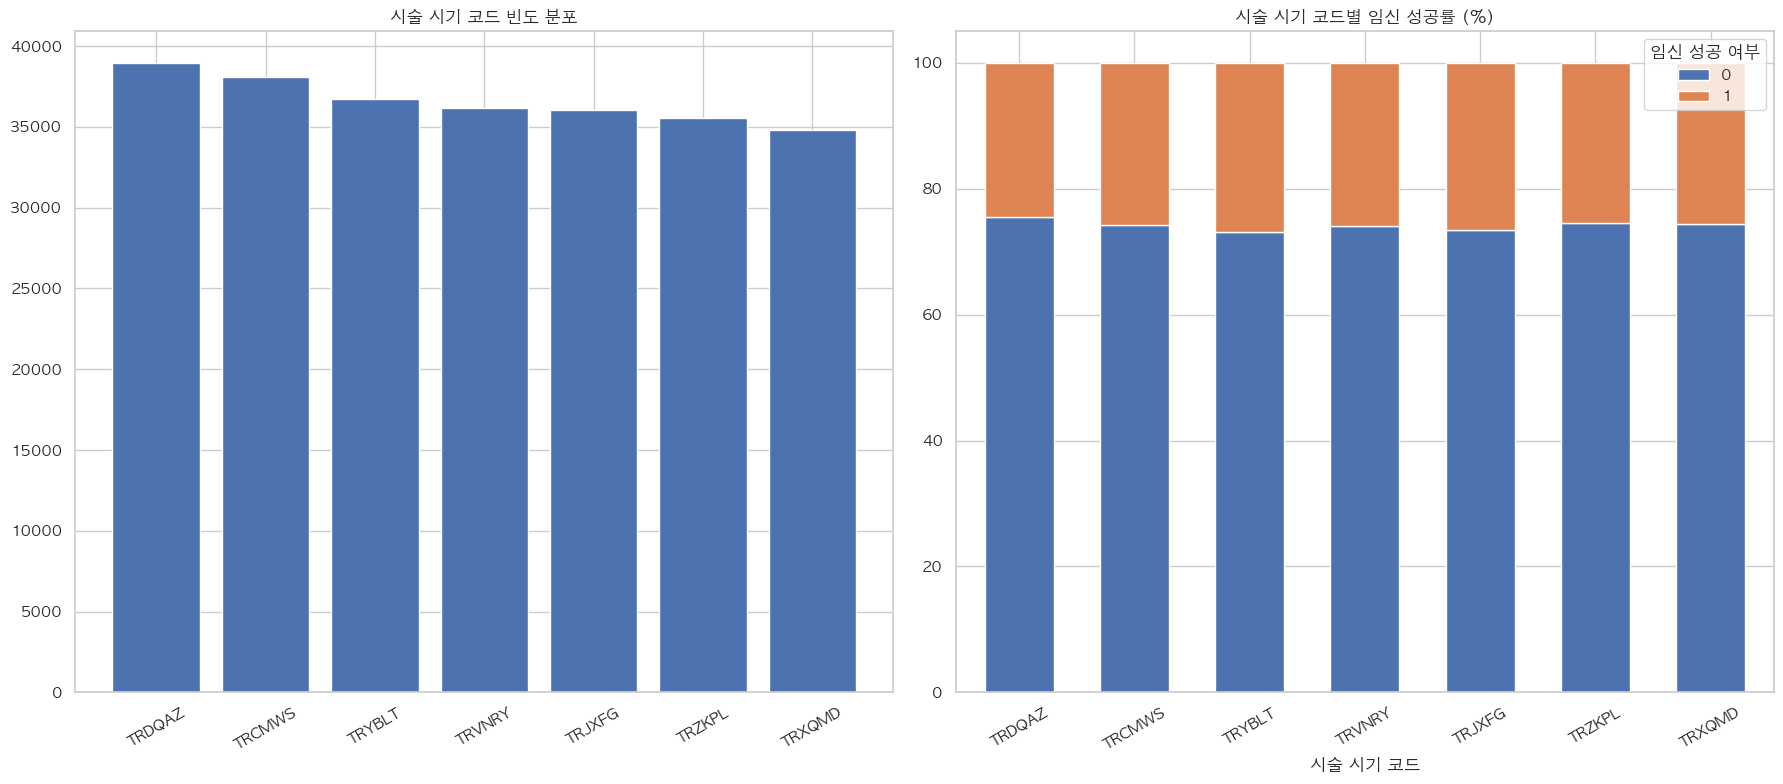

[2/20] 시술 당시 나이


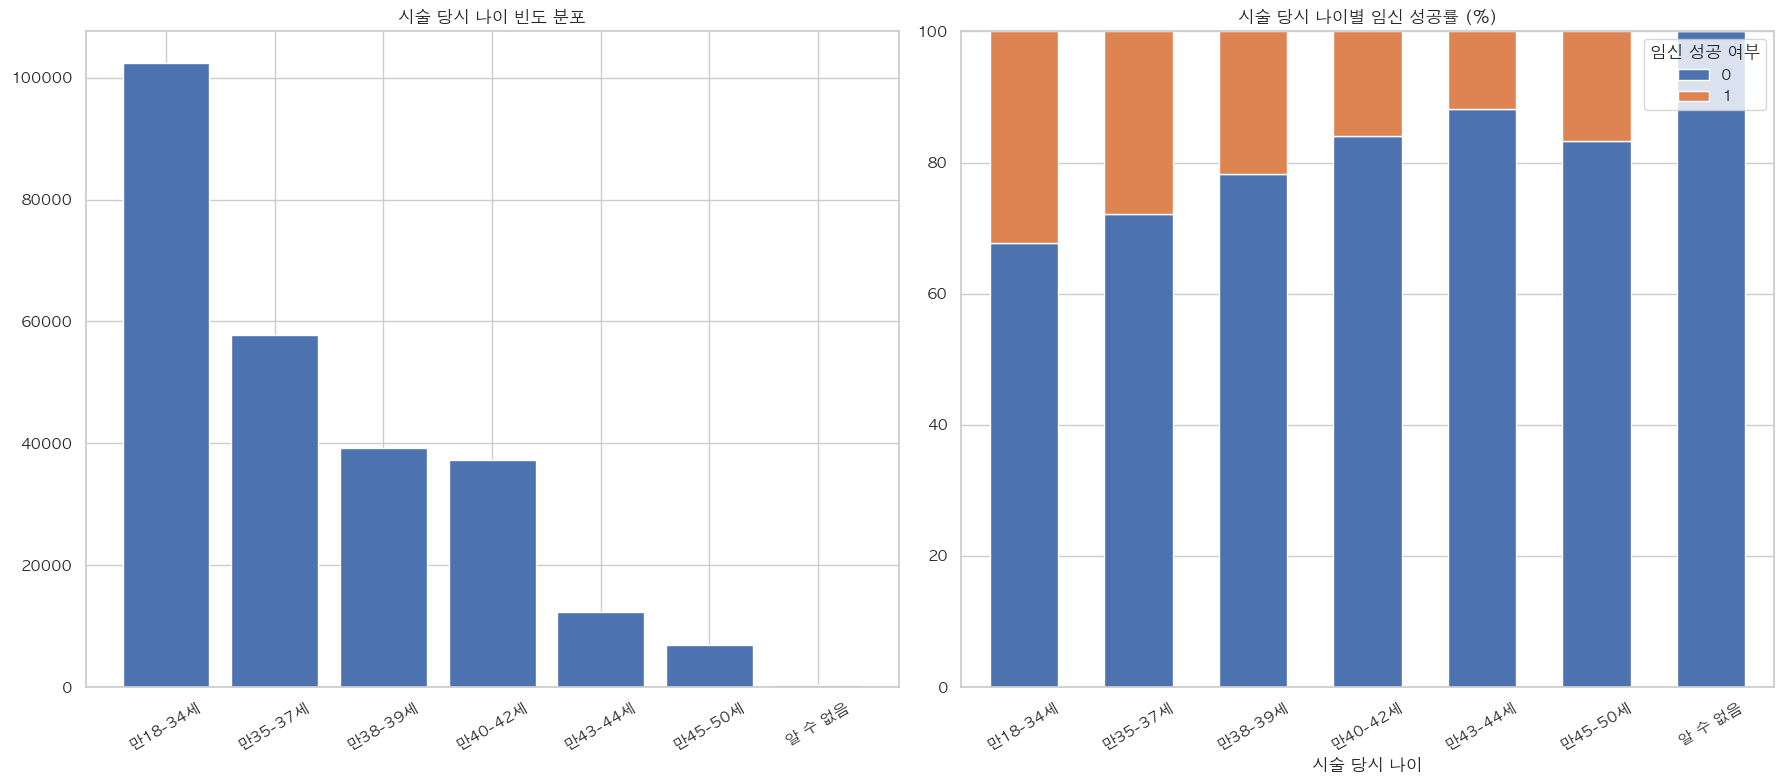

[3/20] 시술 유형


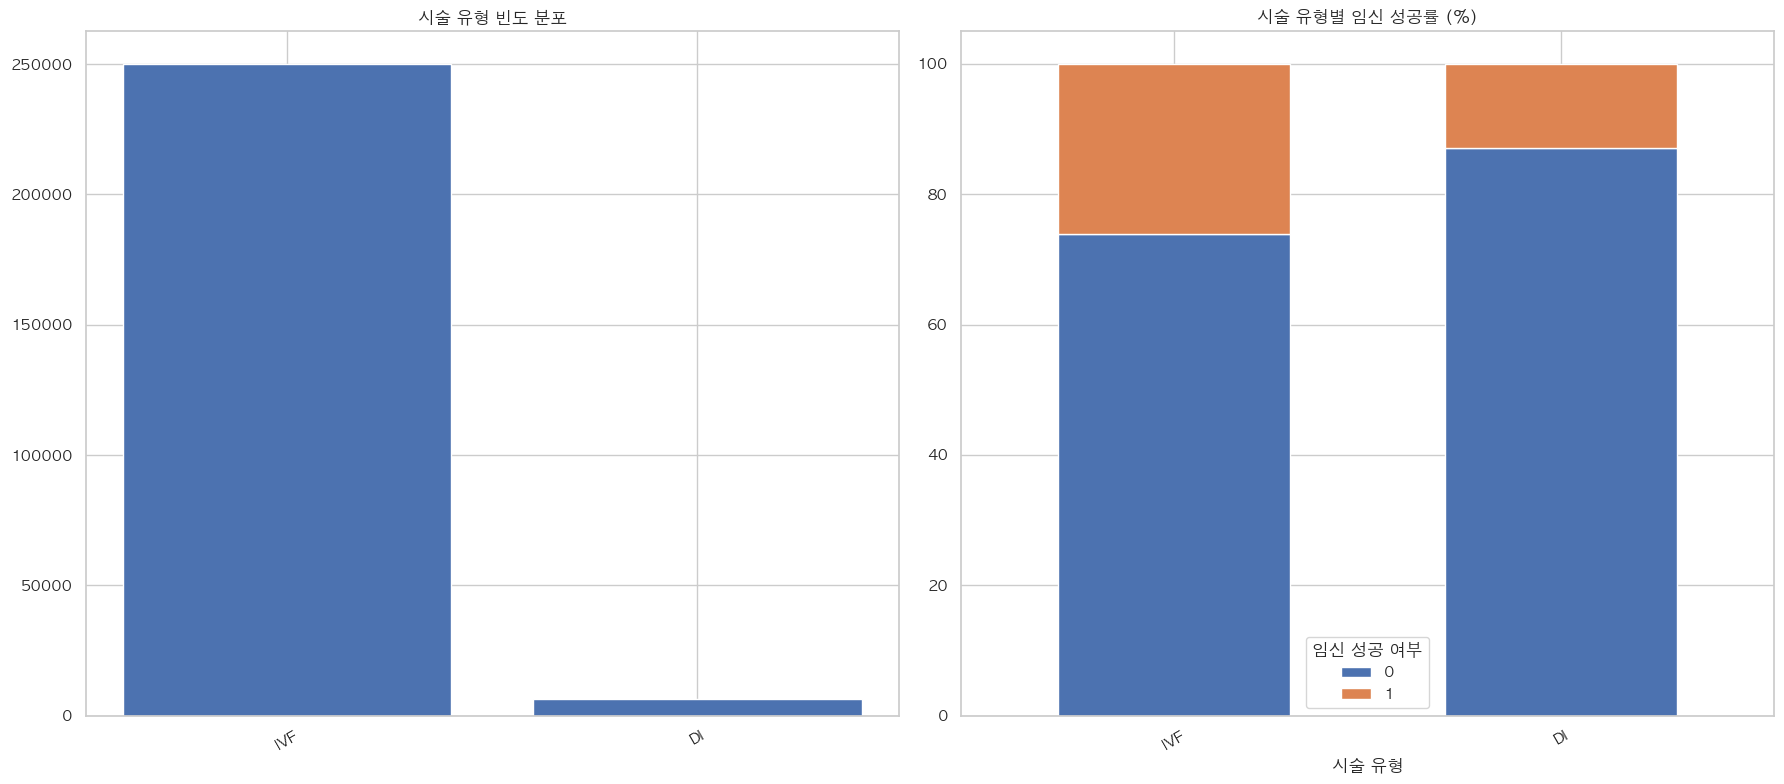

[4/20] 특정 시술 유형


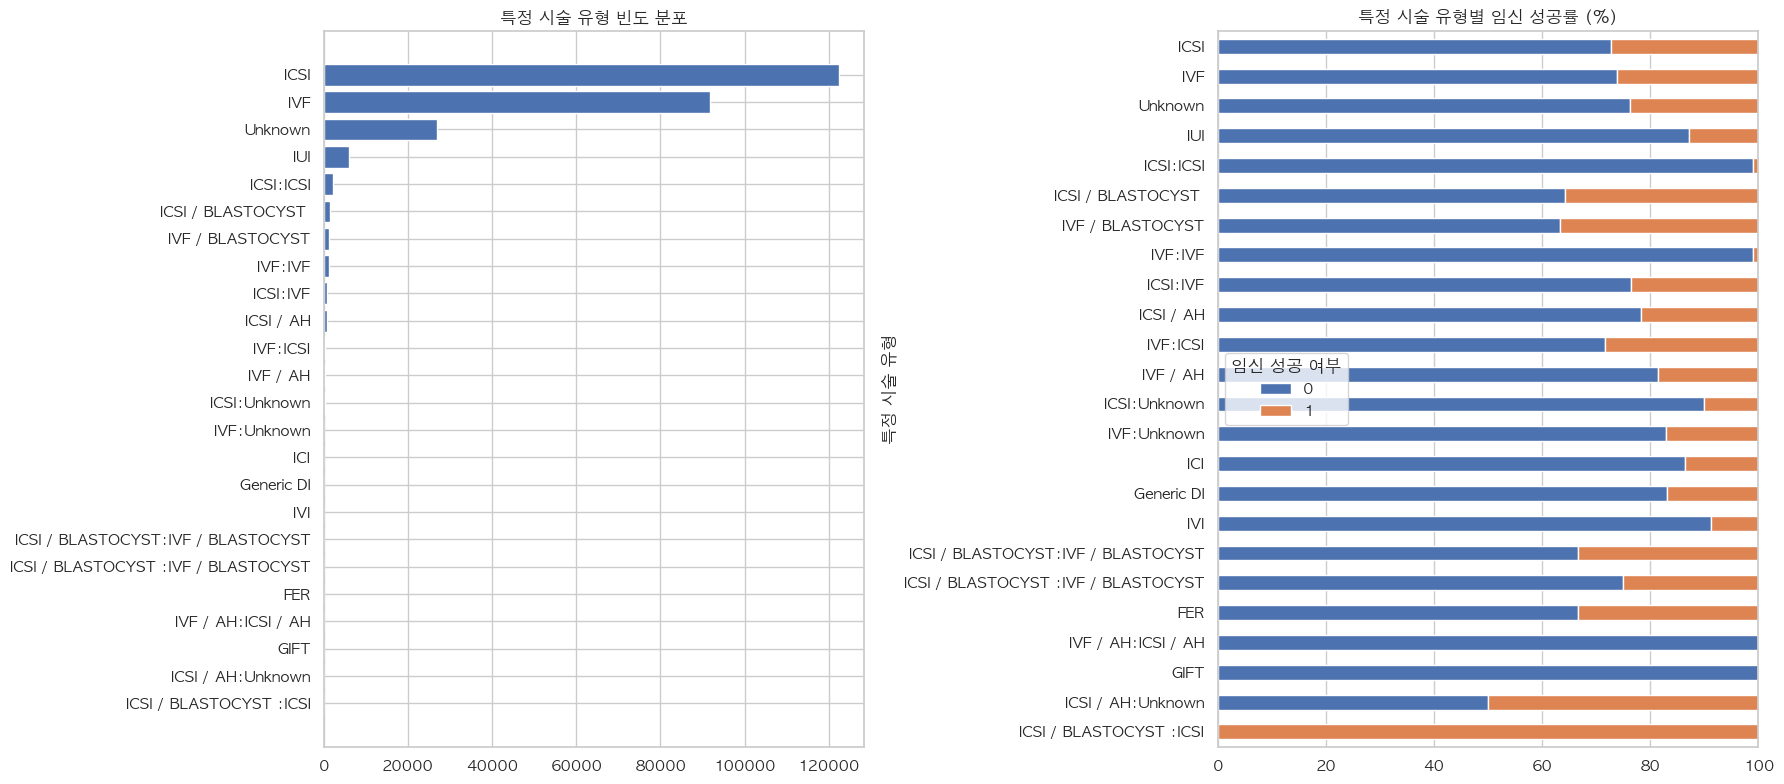

[5/20] 배란 유도 유형


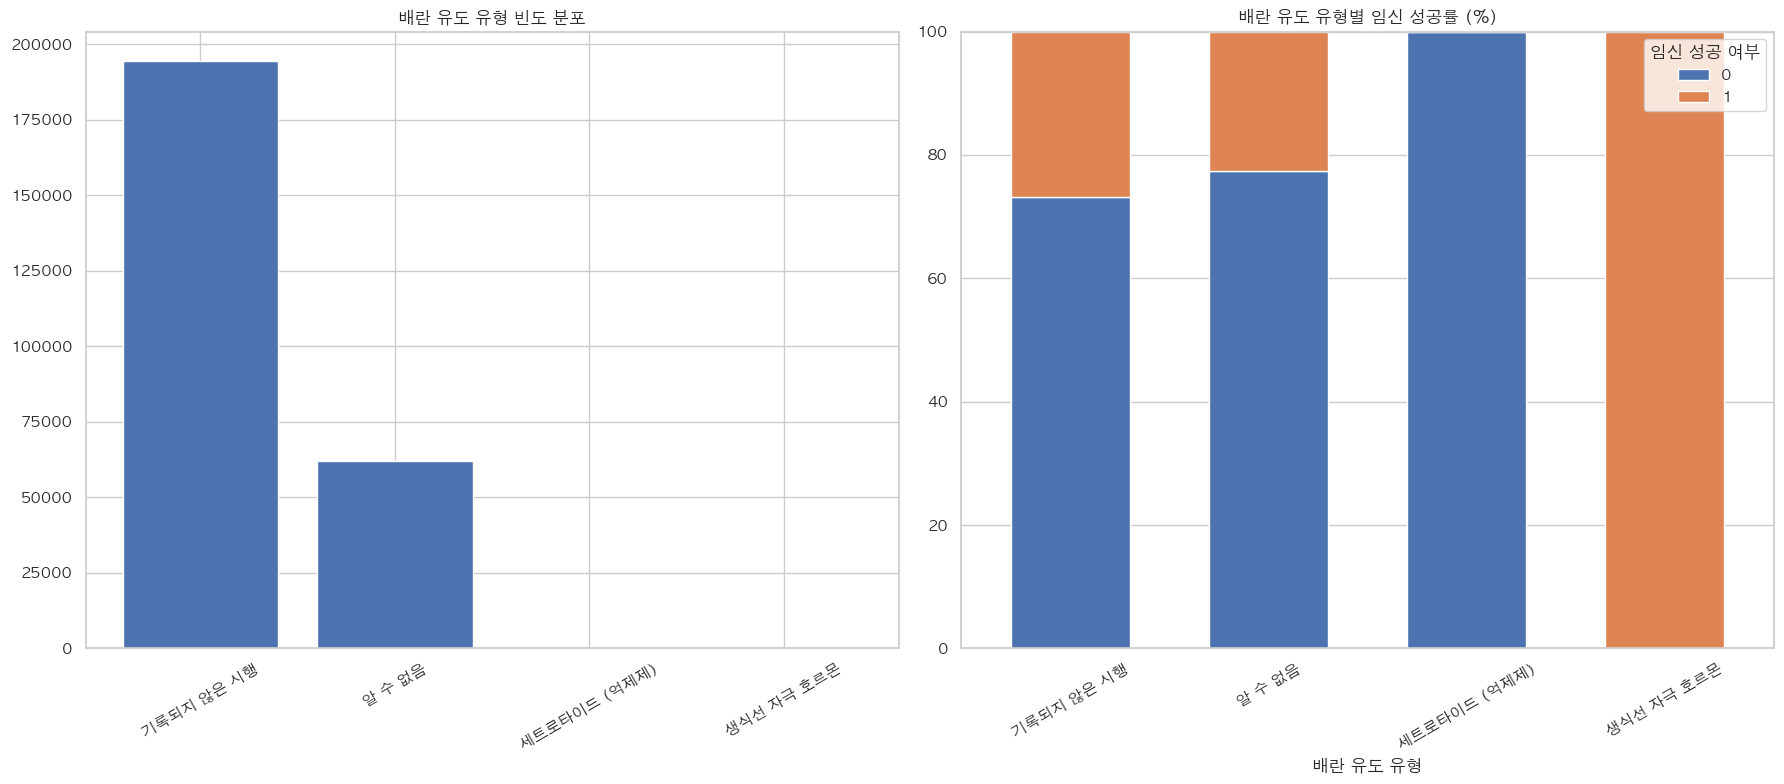

[6/20] 배아 생성 주요 이유


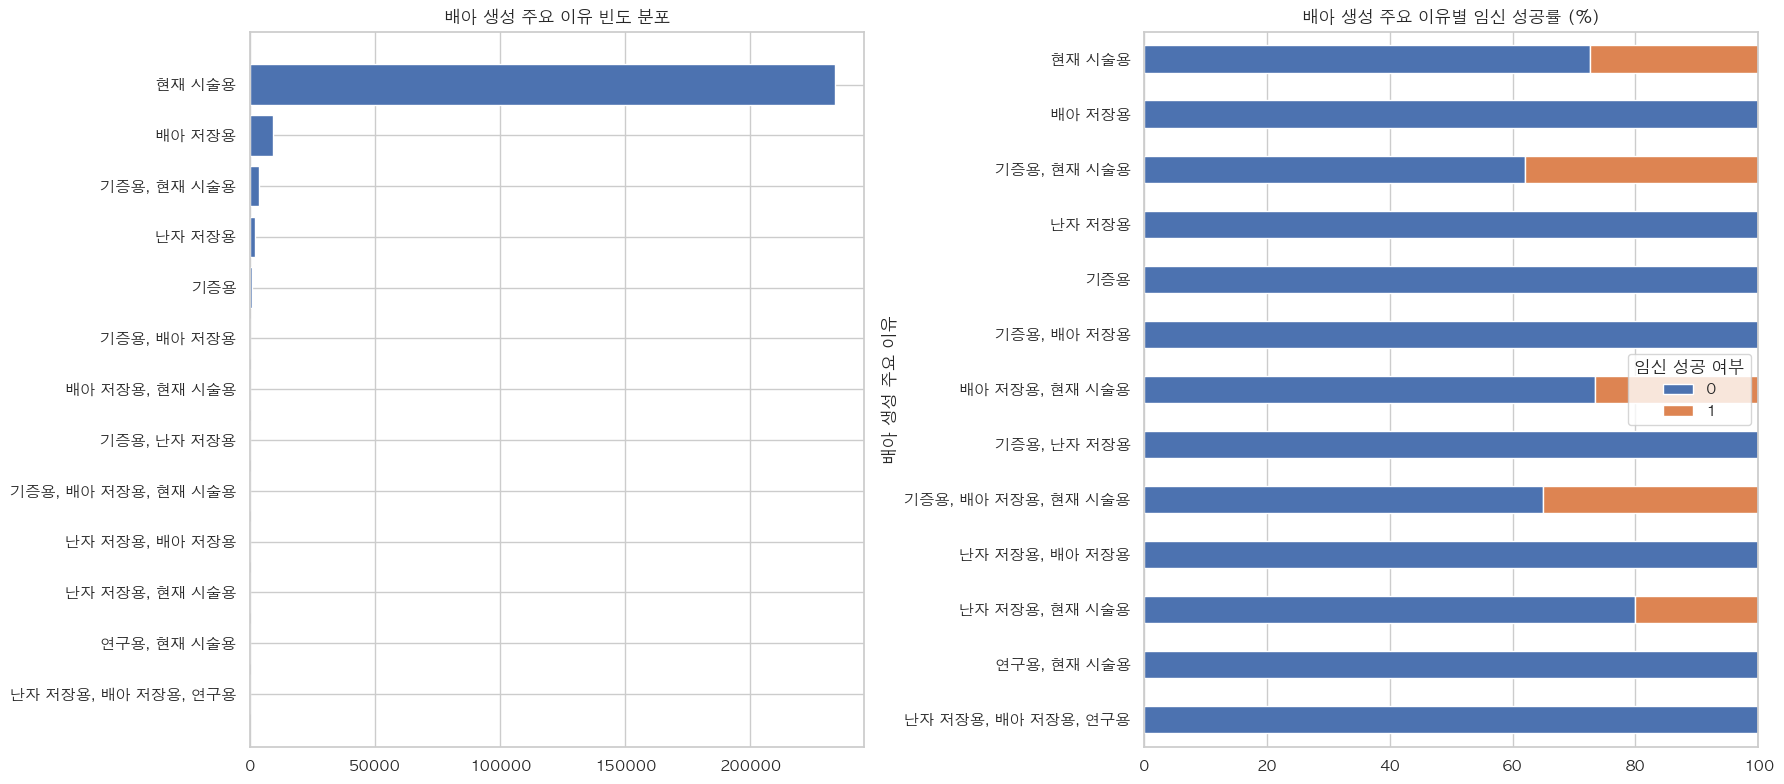

[7/20] 총 시술 횟수


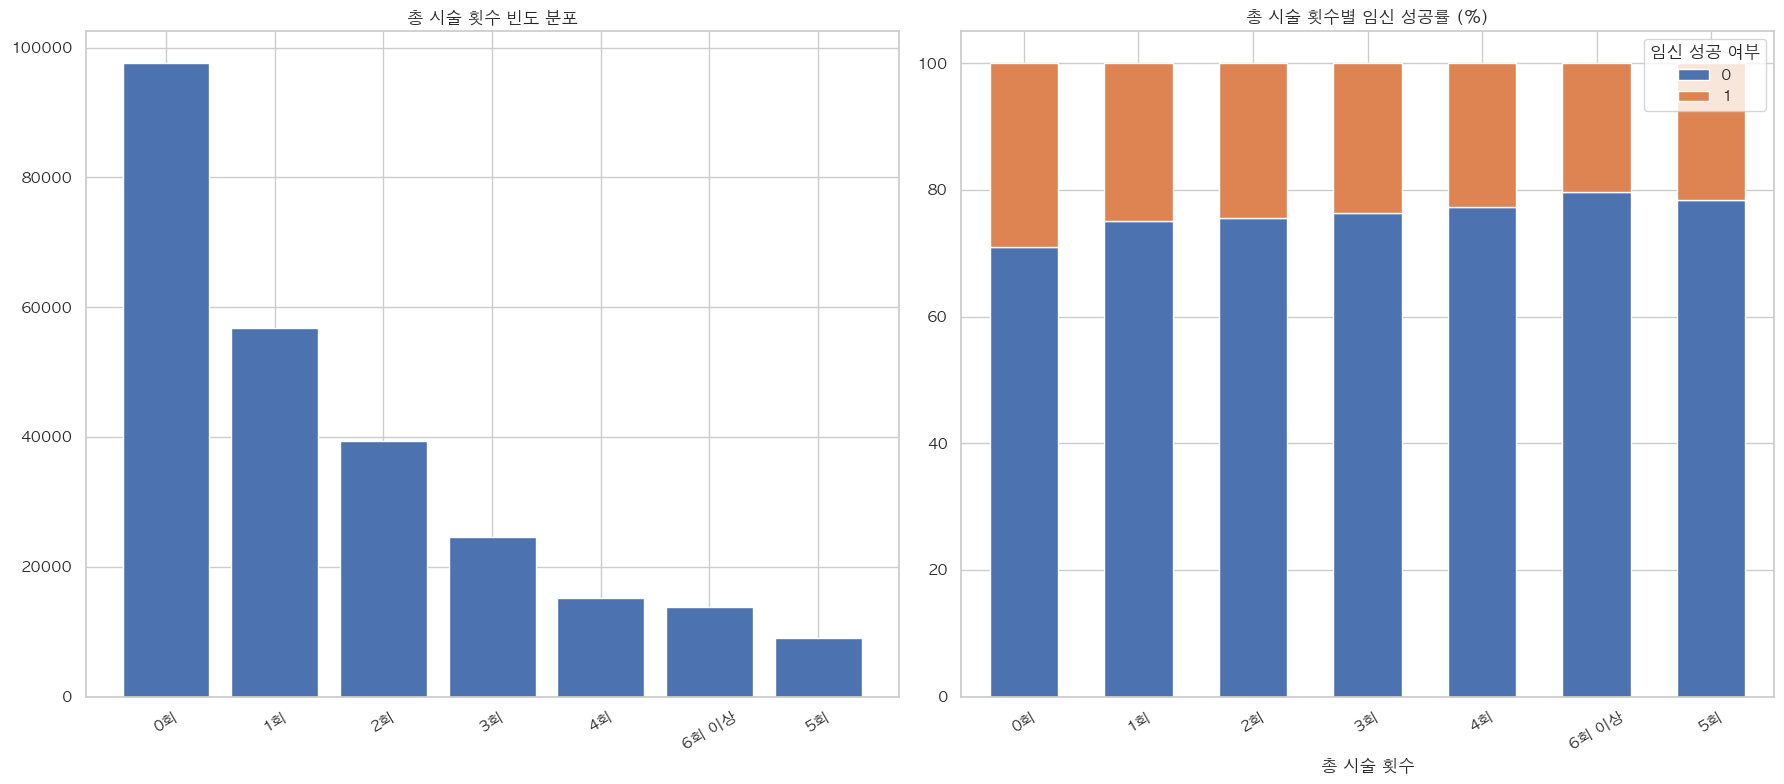

[8/20] 클리닉 내 총 시술 횟수


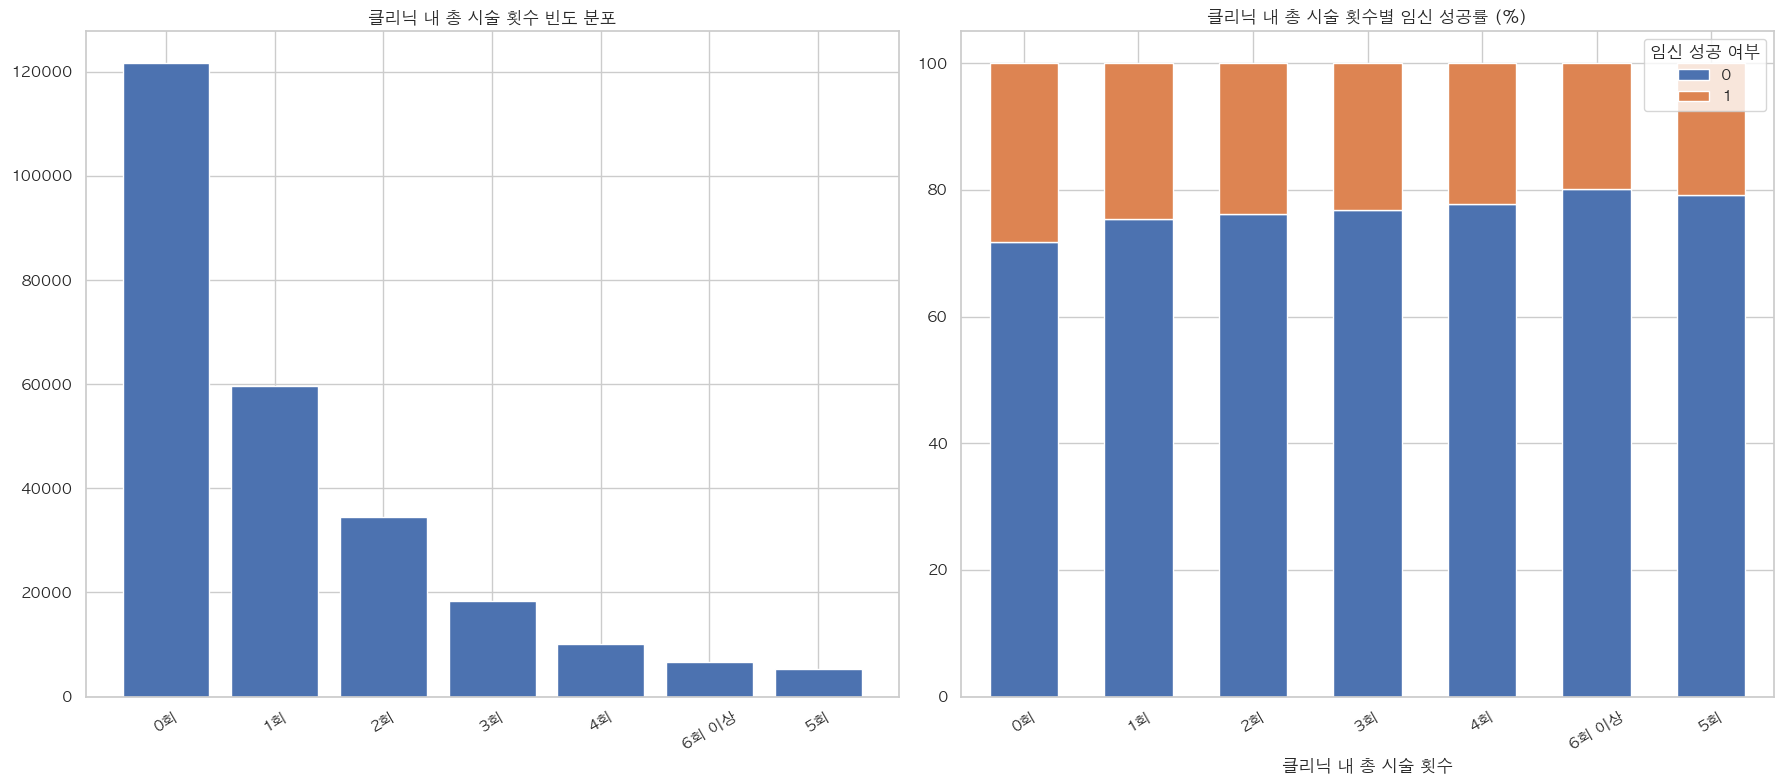

[9/20] IVF 시술 횟수


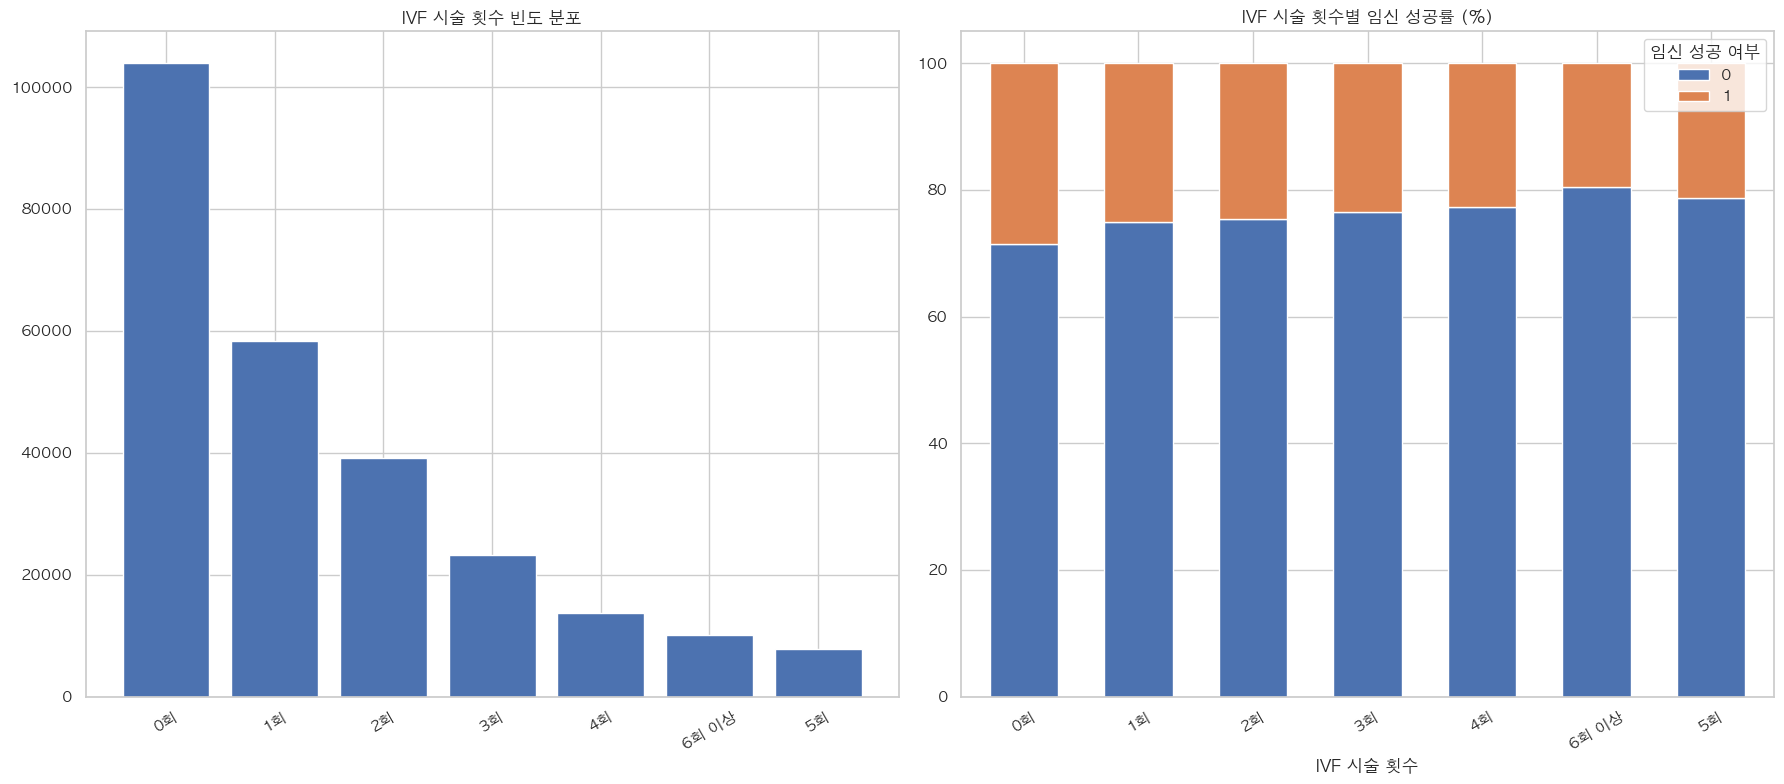

[10/20] DI 시술 횟수


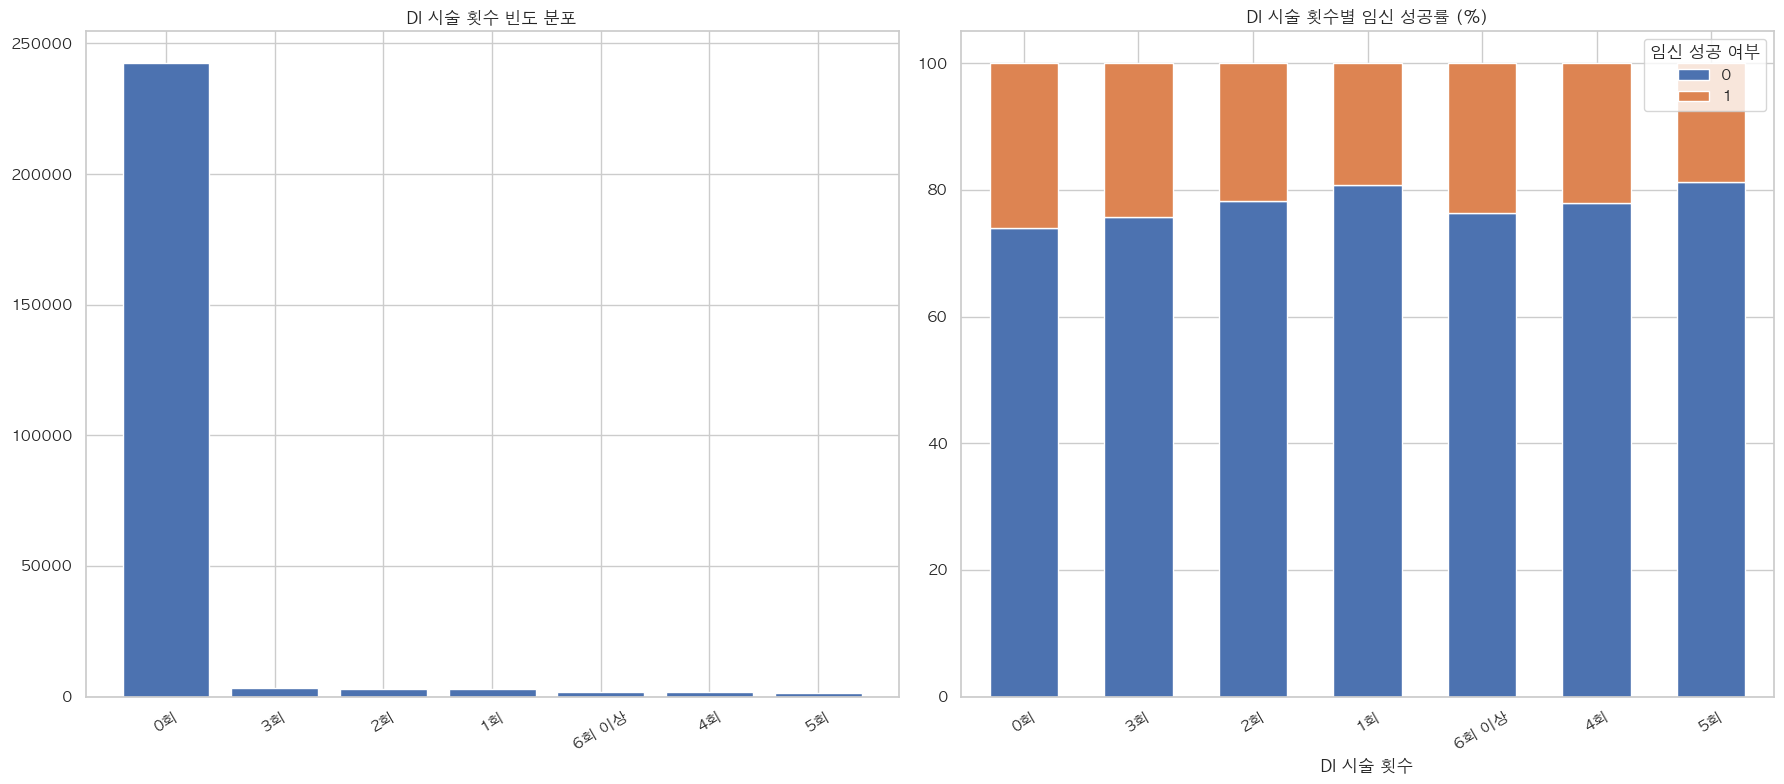

[11/20] 총 임신 횟수


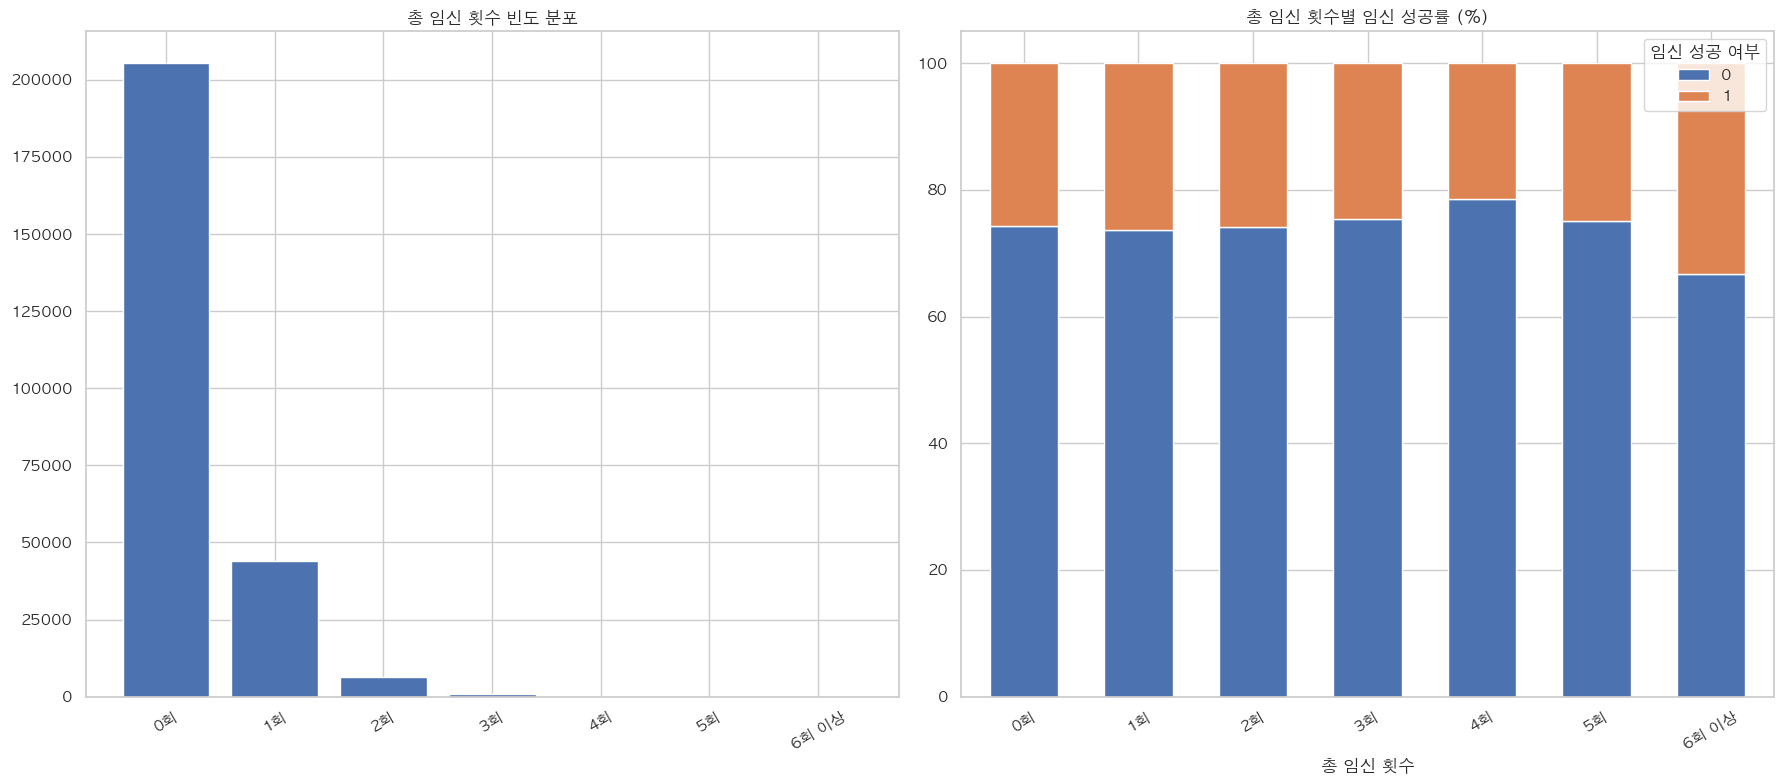

[12/20] IVF 임신 횟수


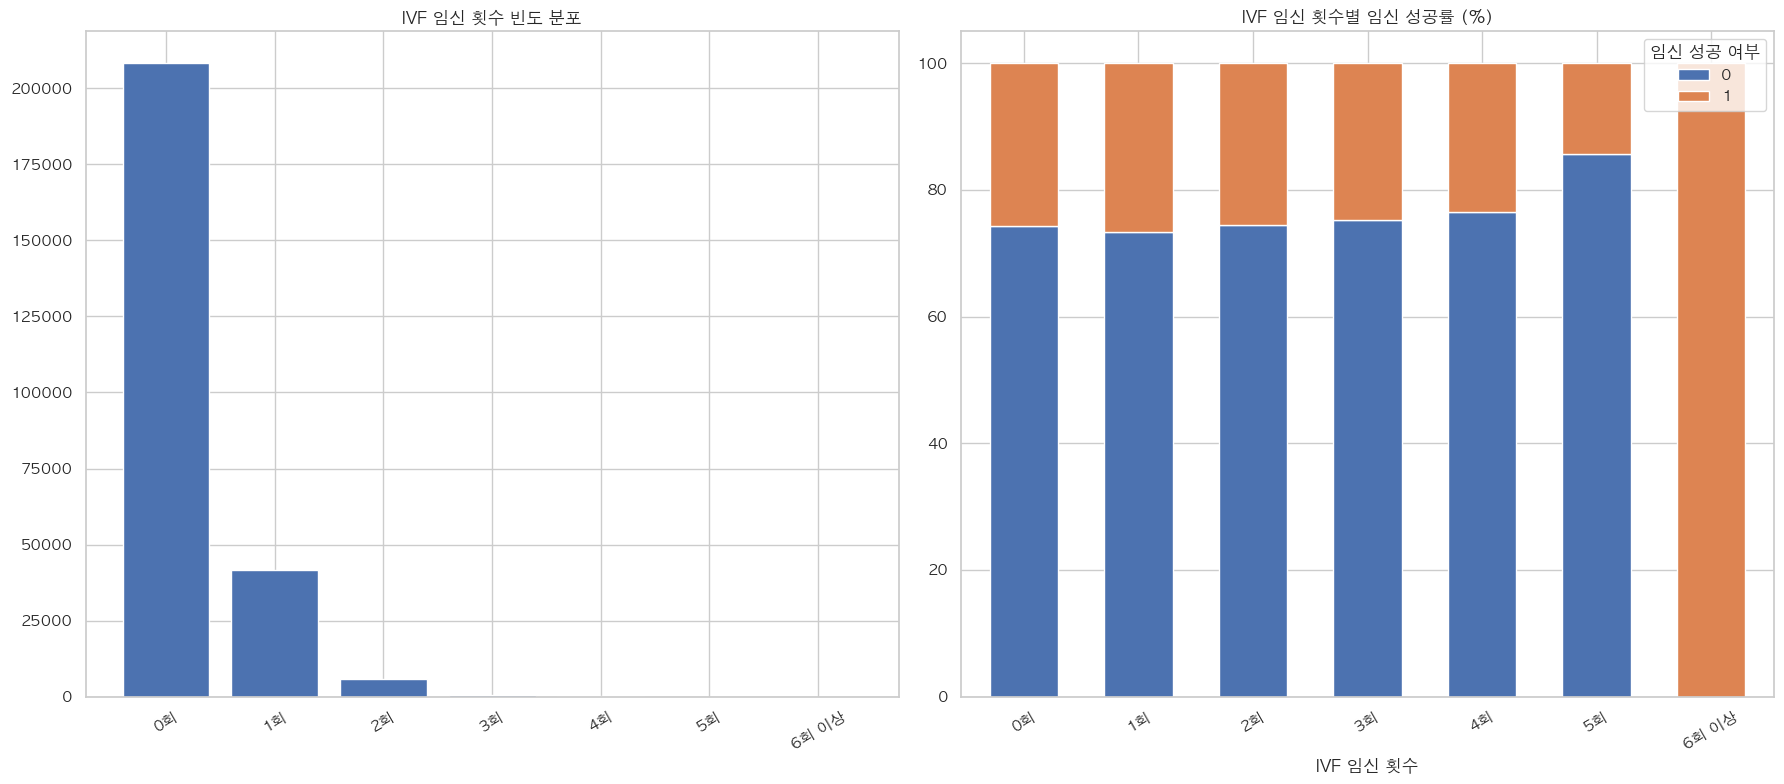

[13/20] DI 임신 횟수


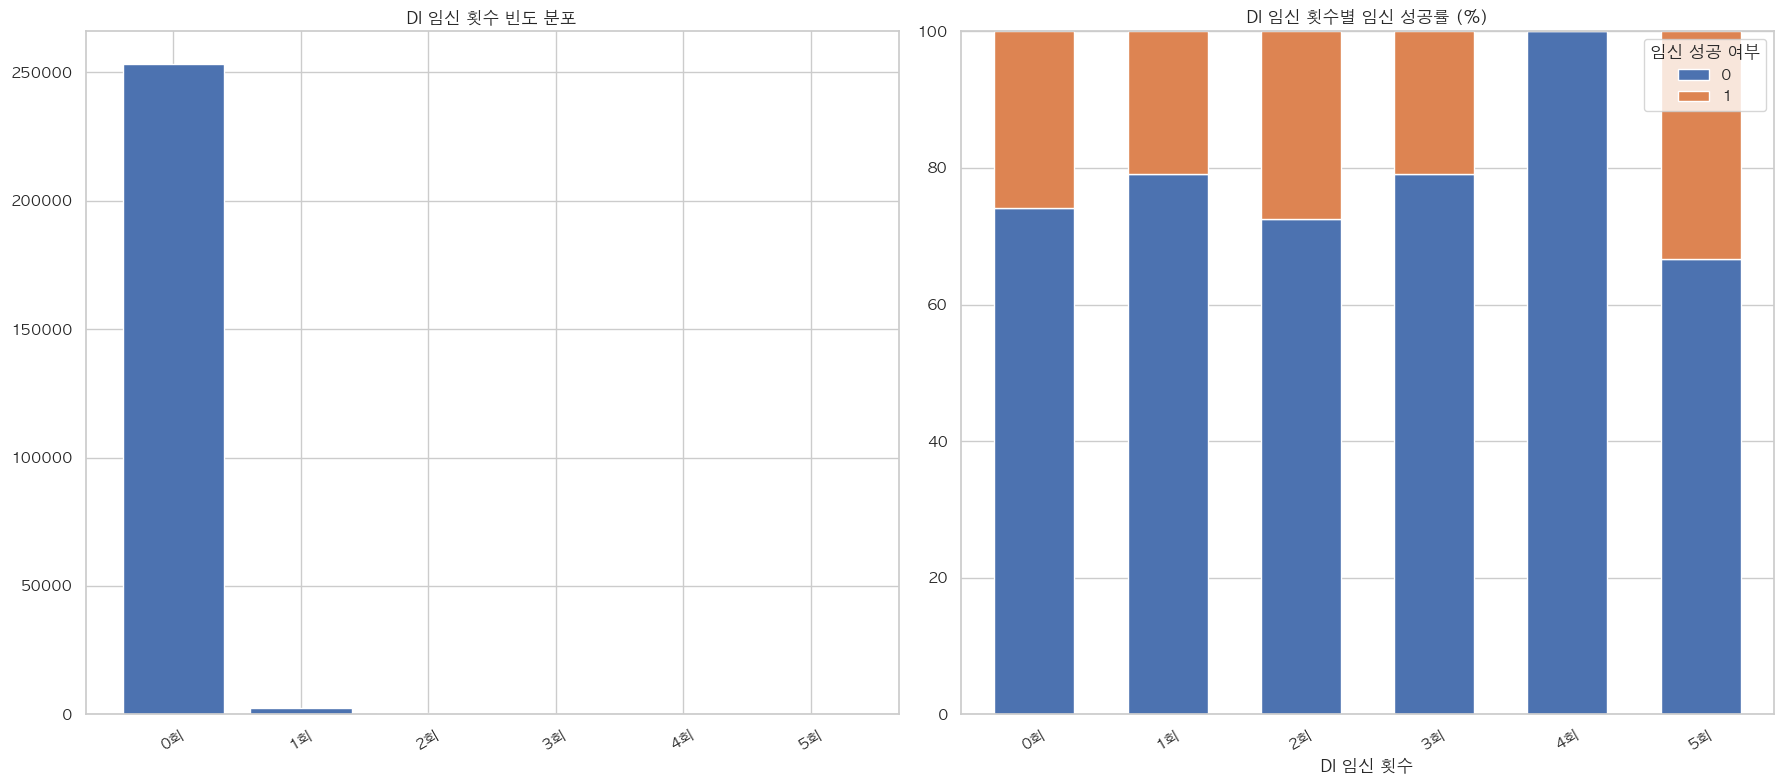

[14/20] 총 출산 횟수


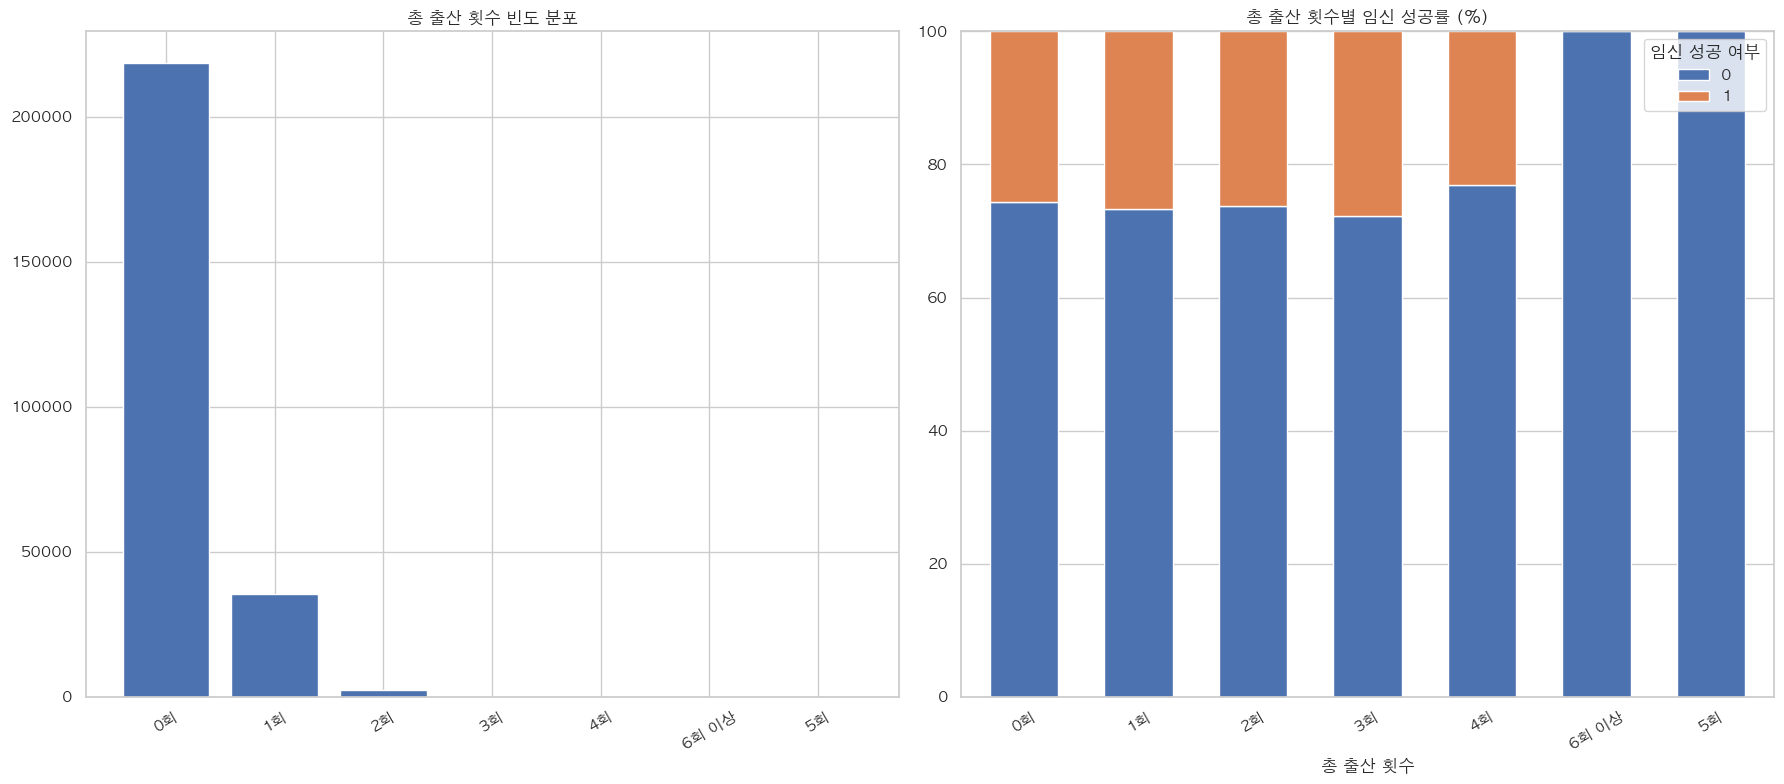

[15/20] IVF 출산 횟수


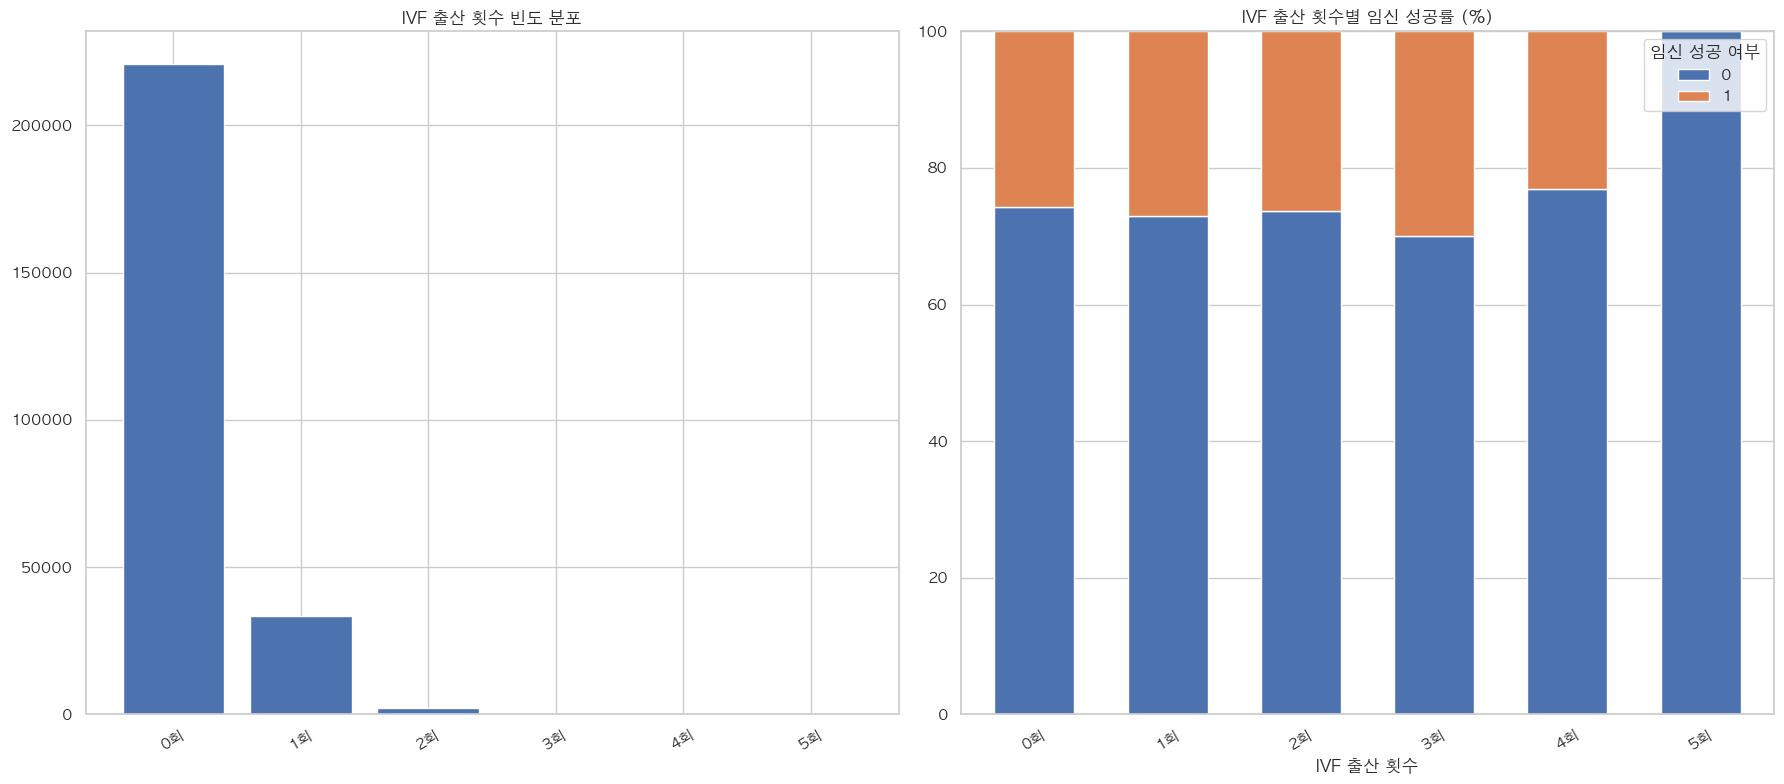

[16/20] DI 출산 횟수


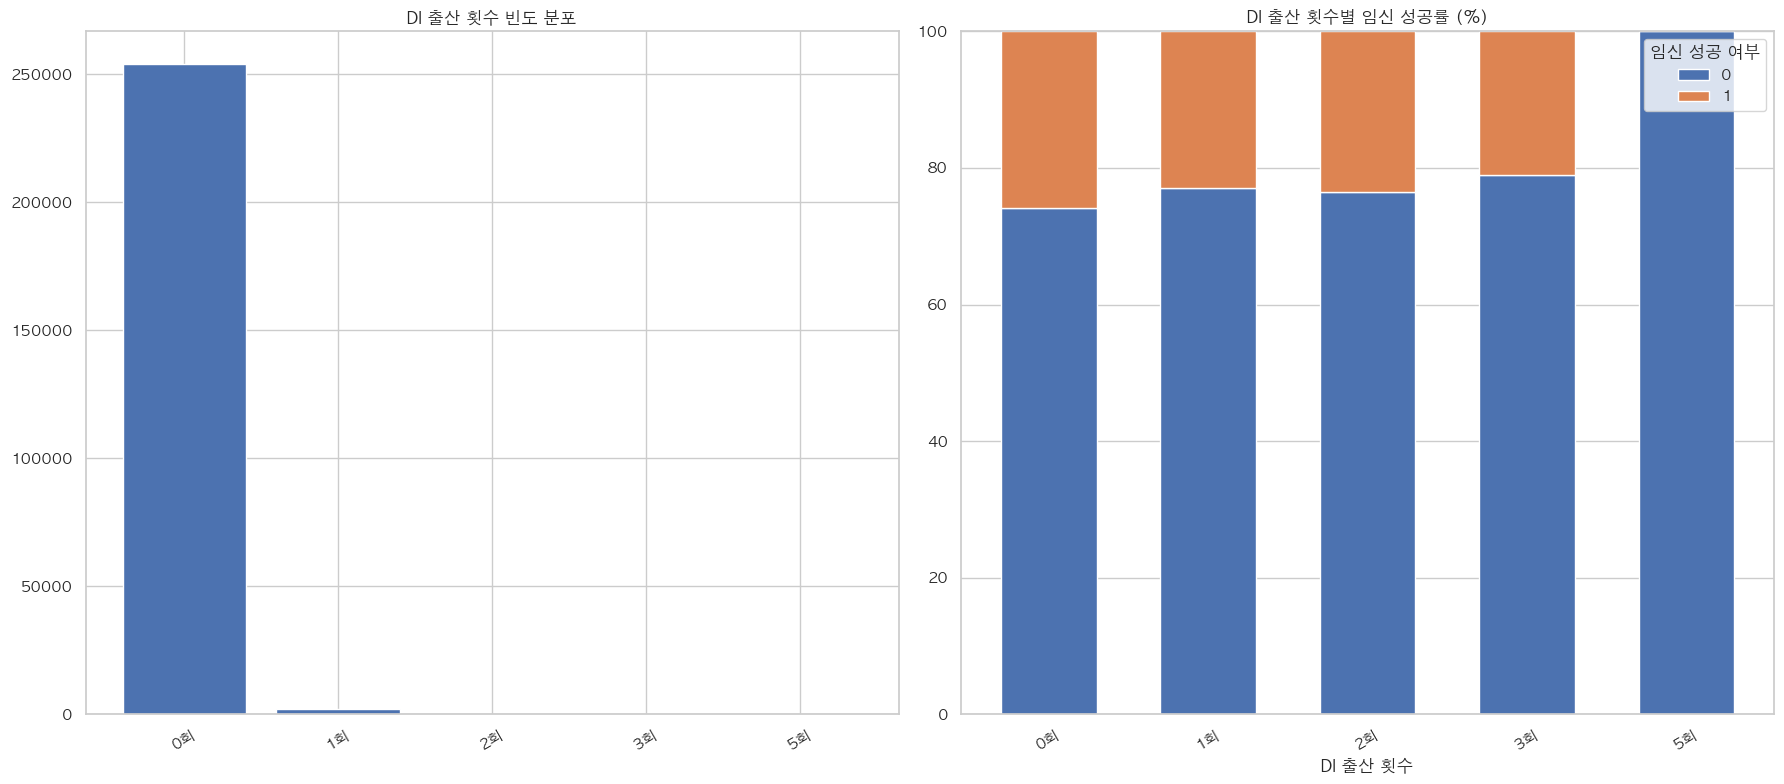

[17/20] 난자 출처


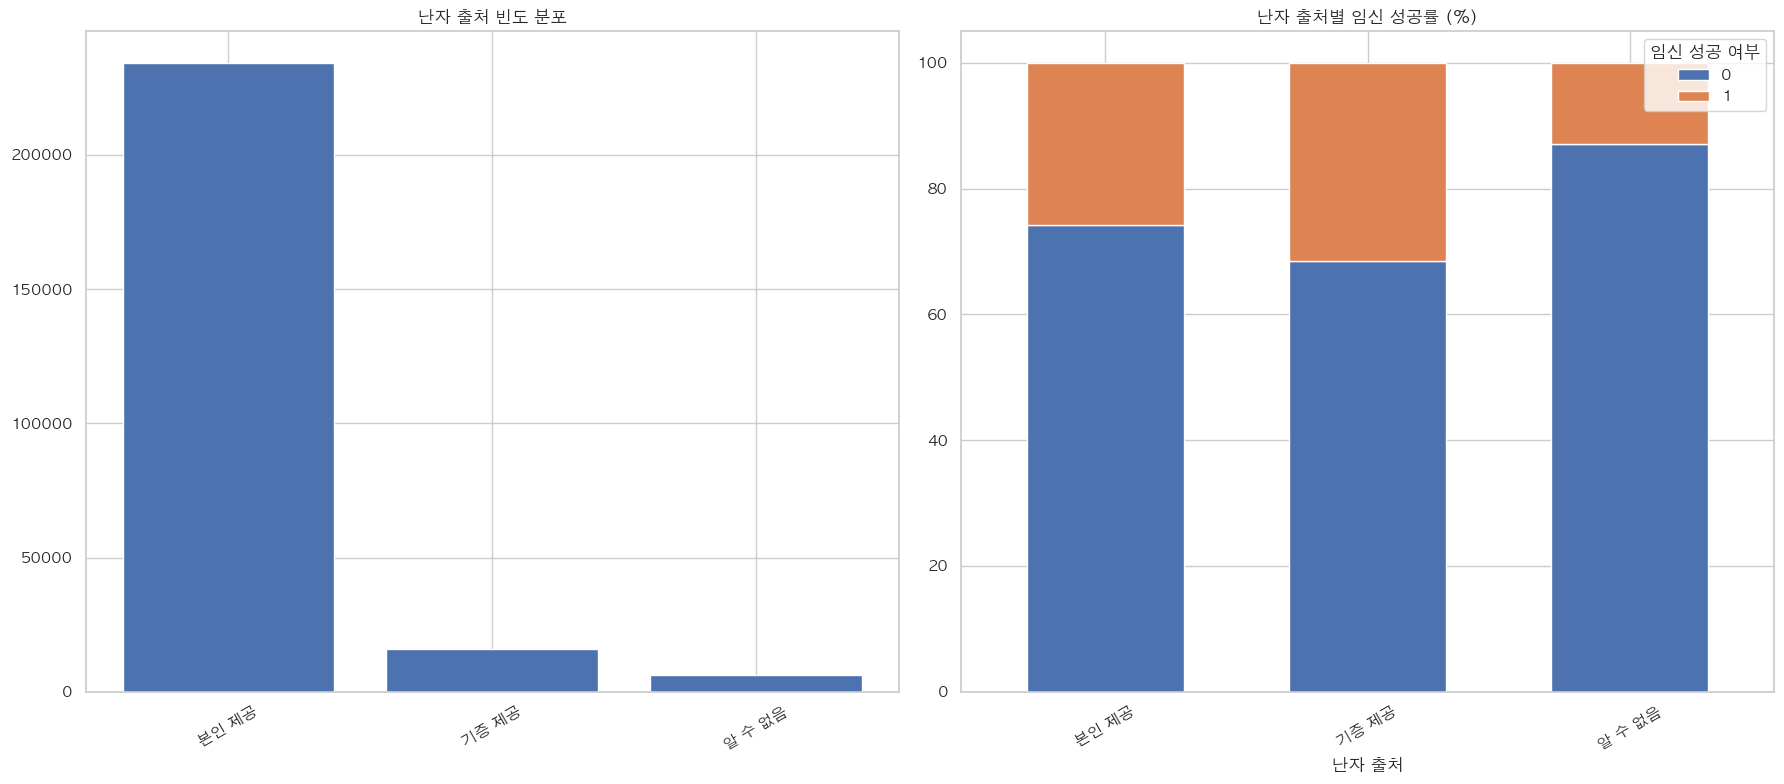

[18/20] 정자 출처


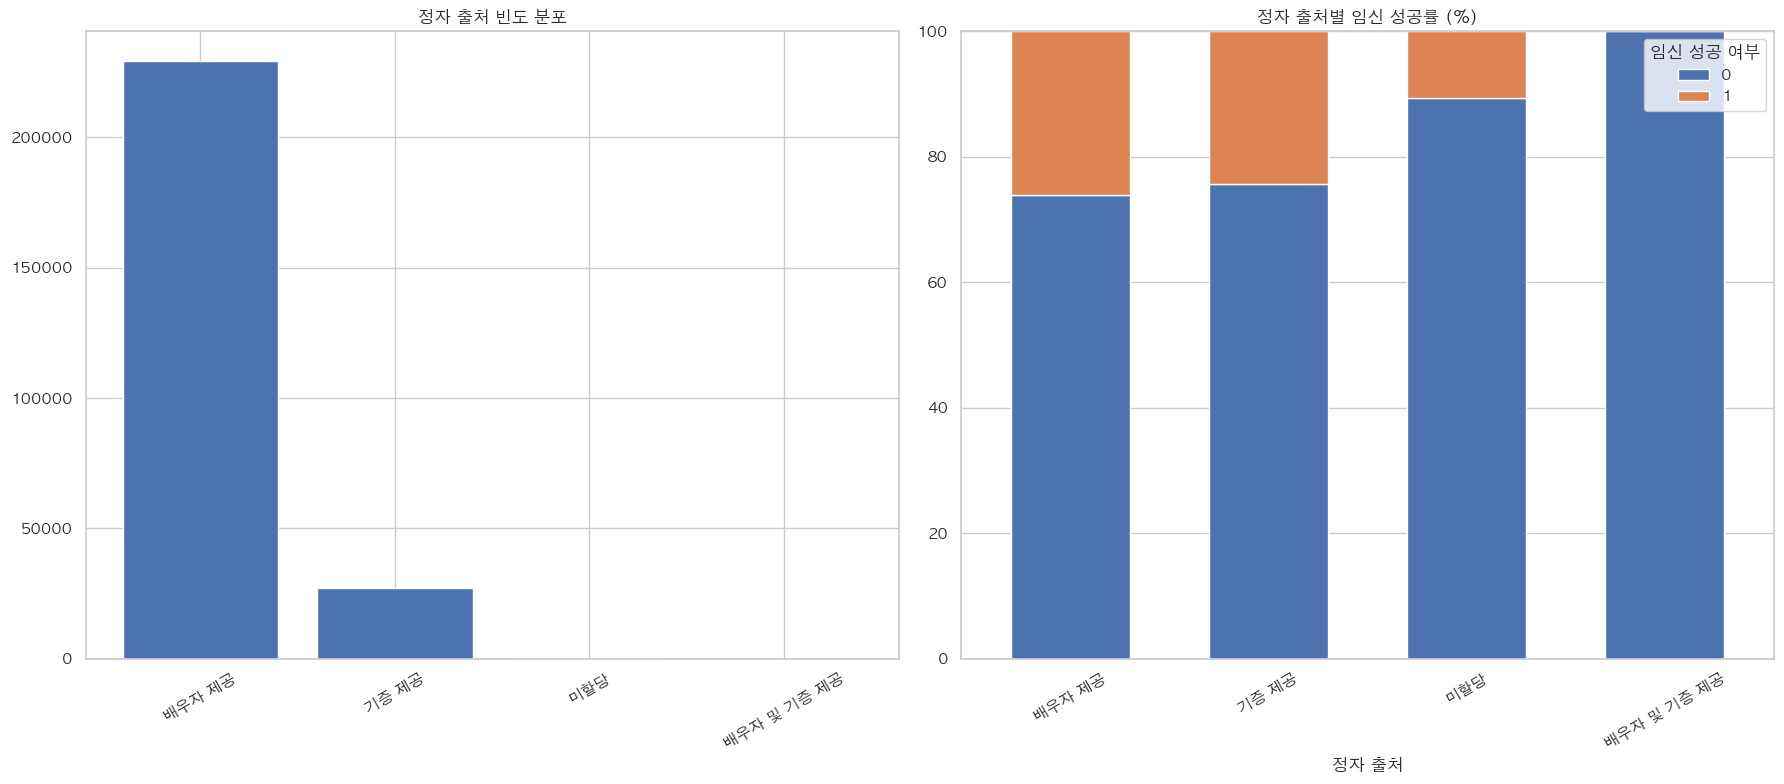

[19/20] 난자 기증자 나이


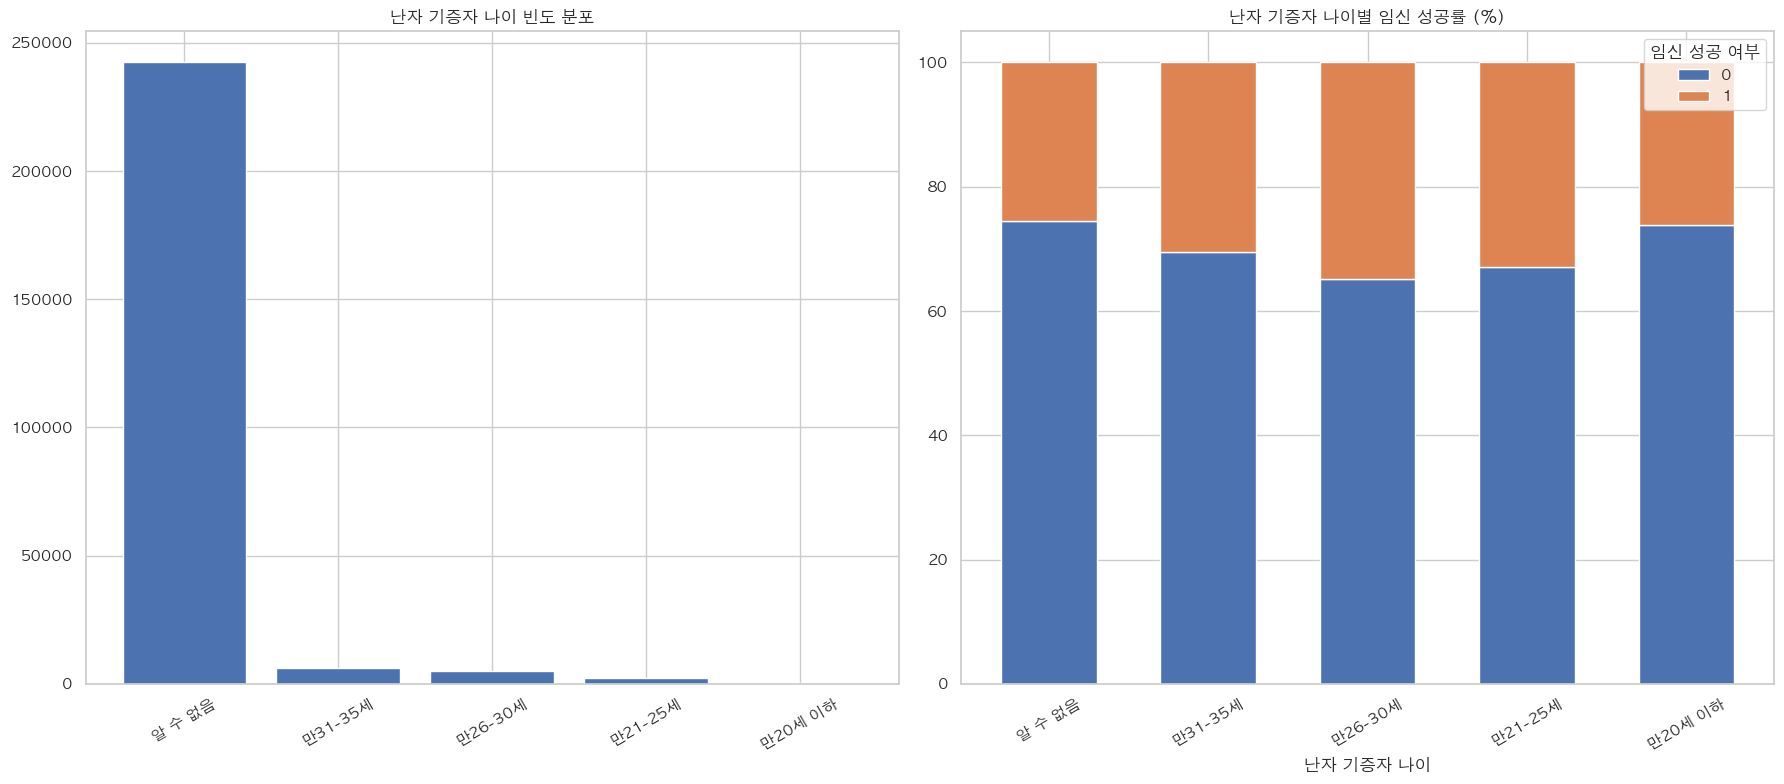

[20/20] 정자 기증자 나이


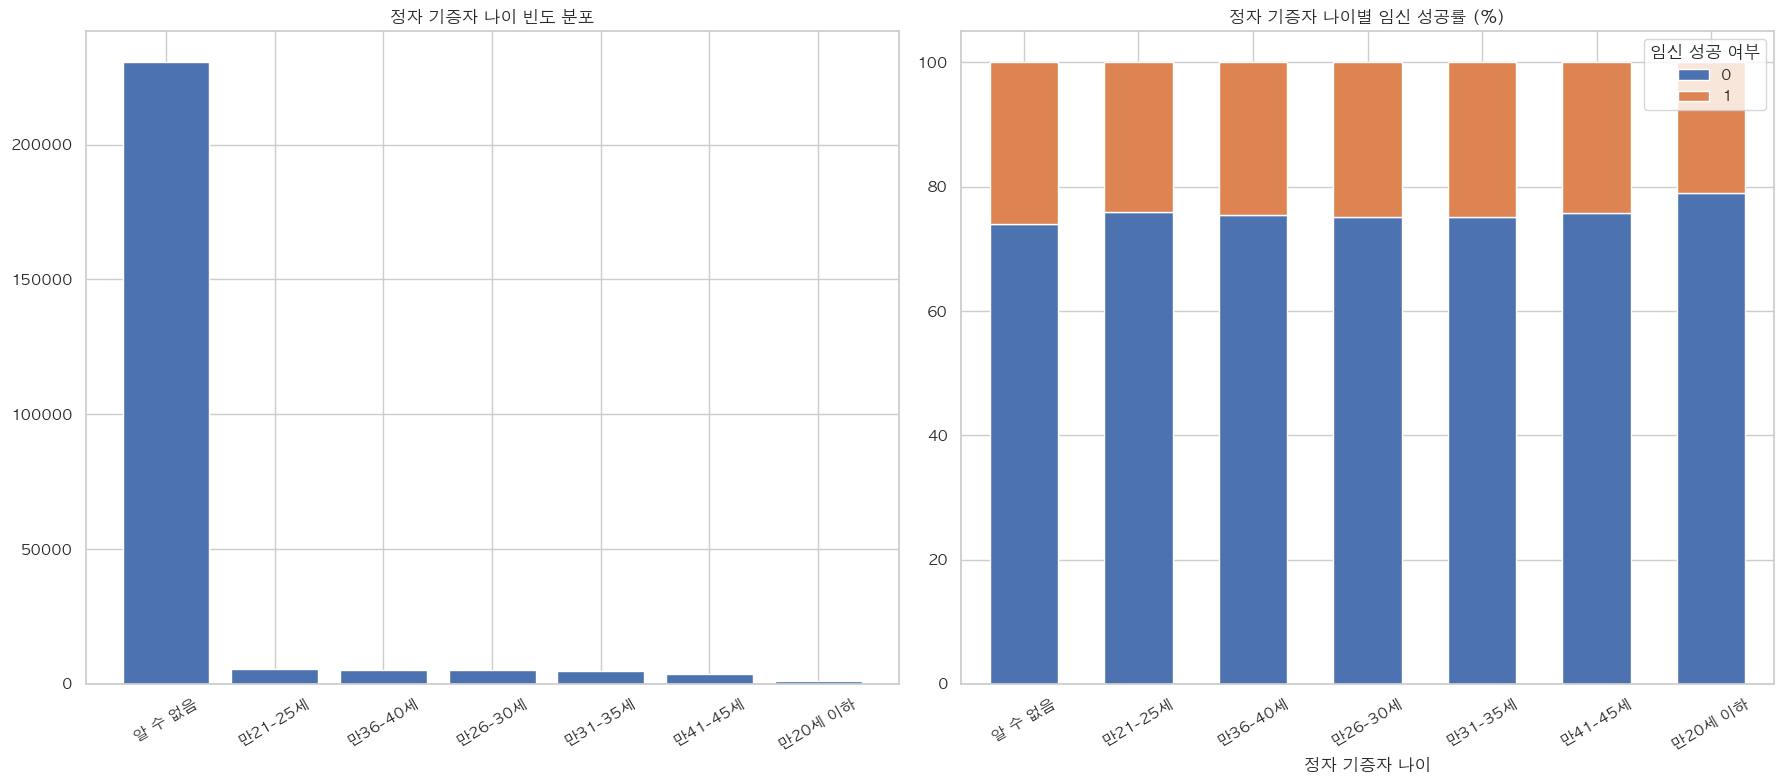

In [16]:
# 문자열(str) 변수 분석

# 문자열 변수의 카테고리 값 개수가 많은 feature - 가로로 시각화 처리
special_cols = ["특정 시술 유형", "배아 생성 주요 이유"]

for i, col in enumerate(str_columns):
    if col not in train.columns:
        continue

    print(f"[{i+1}/{len(str_columns)}] {col}")
    custom_order = train[col].value_counts().index.tolist()
    plot_df = train[train[col].isin(custom_order)]
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    counts = plot_df[col].value_counts().reindex(custom_order)

    # 가로 시각화
    if col in special_cols:
        axes[0].barh(counts.index.astype(str), counts.values)
        axes[0].set_title(f"{col} 빈도 분포")
        axes[0].invert_yaxis()
    # 세로 시각화
    else:
        axes[0].bar(counts.index.astype(str), counts.values)
        axes[0].tick_params(axis='x', rotation=30)
        axes[0].set_title(f"{col} 빈도 분포")

    # 임신 성공률 그래프
    cross_tab = (
        plot_df.groupby(col)['임신 성공 여부']
        .value_counts(normalize=True)
        .unstack(fill_value=0) * 100
    ).reindex(custom_order)

    # 가로 stacked bar
    if col in special_cols:
        cross_tab.plot(kind='barh', stacked=True, ax=axes[1])
        axes[1].invert_yaxis()
    # 세로 stacked bar
    else:
        cross_tab.plot(kind='bar', stacked=True, ax=axes[1], width=0.6)
        axes[1].tick_params(axis='x', rotation=30)

    axes[1].set_title(f"{col}별 임신 성공률 (%)")
    plt.tight_layout()
    plt.show()


[1/20] [연속형 분석] 변수명: 임신 시도 또는 마지막 임신 경과 연수
count    9370.000000
mean        9.270651
std         3.550313
min         0.000000
25%         7.000000
50%         9.000000
75%        11.000000
max        20.000000
Name: 임신 시도 또는 마지막 임신 경과 연수, dtype: float64
------------------------------------------------------------


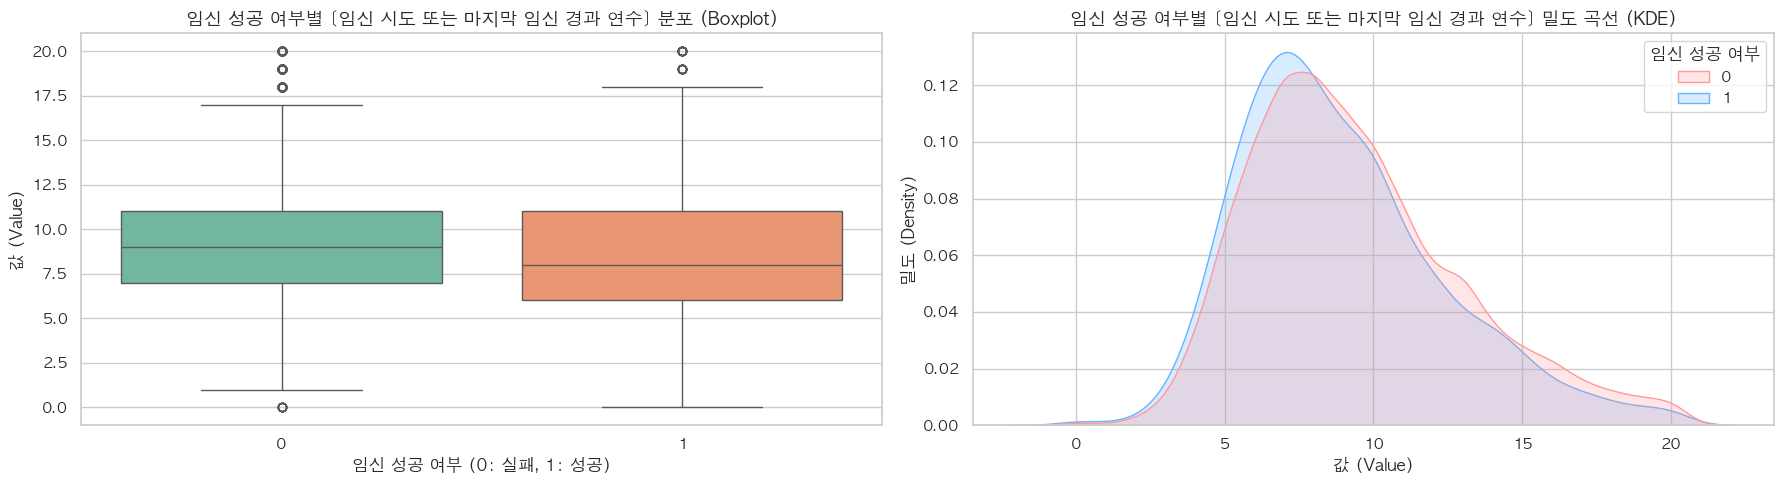


[2/20] [연속형 분석] 변수명: 총 생성 배아 수
count    250060.000000
mean          5.061145
std           4.664337
min           0.000000
25%           1.000000
50%           4.000000
75%           8.000000
max          51.000000
Name: 총 생성 배아 수, dtype: float64
------------------------------------------------------------


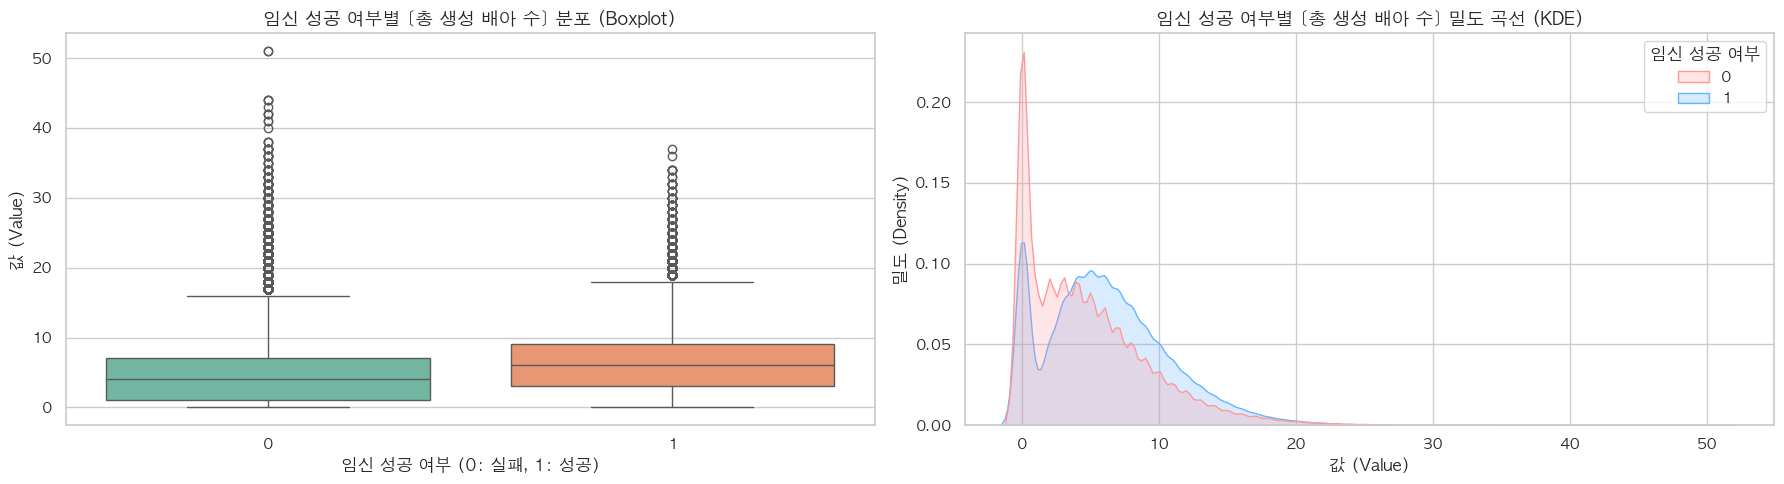


[3/20] [연속형 분석] 변수명: 미세주입된 난자 수
count    250060.000000
mean          4.170799
std           5.625943
min           0.000000
25%           0.000000
50%           0.000000
75%           7.000000
max          51.000000
Name: 미세주입된 난자 수, dtype: float64
------------------------------------------------------------


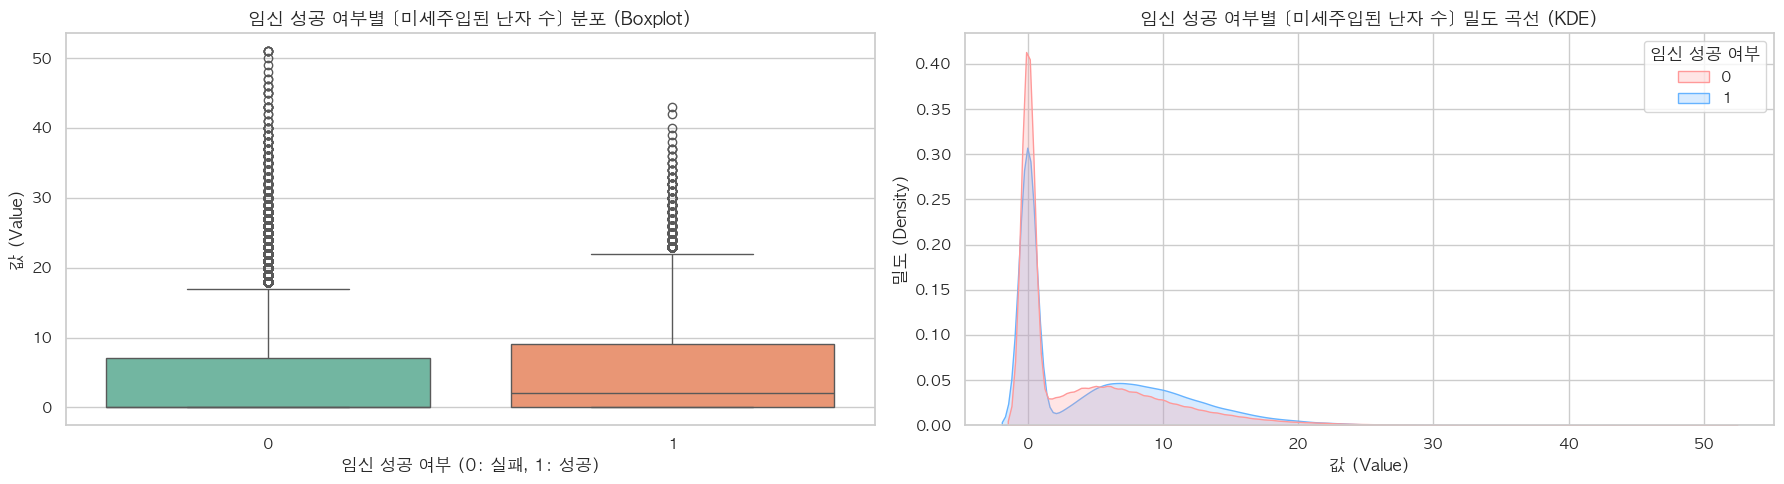


[4/20] [연속형 분석] 변수명: 미세주입에서 생성된 배아 수
count    250060.00000
mean          2.84365
std           4.09464
min           0.00000
25%           0.00000
50%           0.00000
75%           5.00000
max          43.00000
Name: 미세주입에서 생성된 배아 수, dtype: float64
------------------------------------------------------------


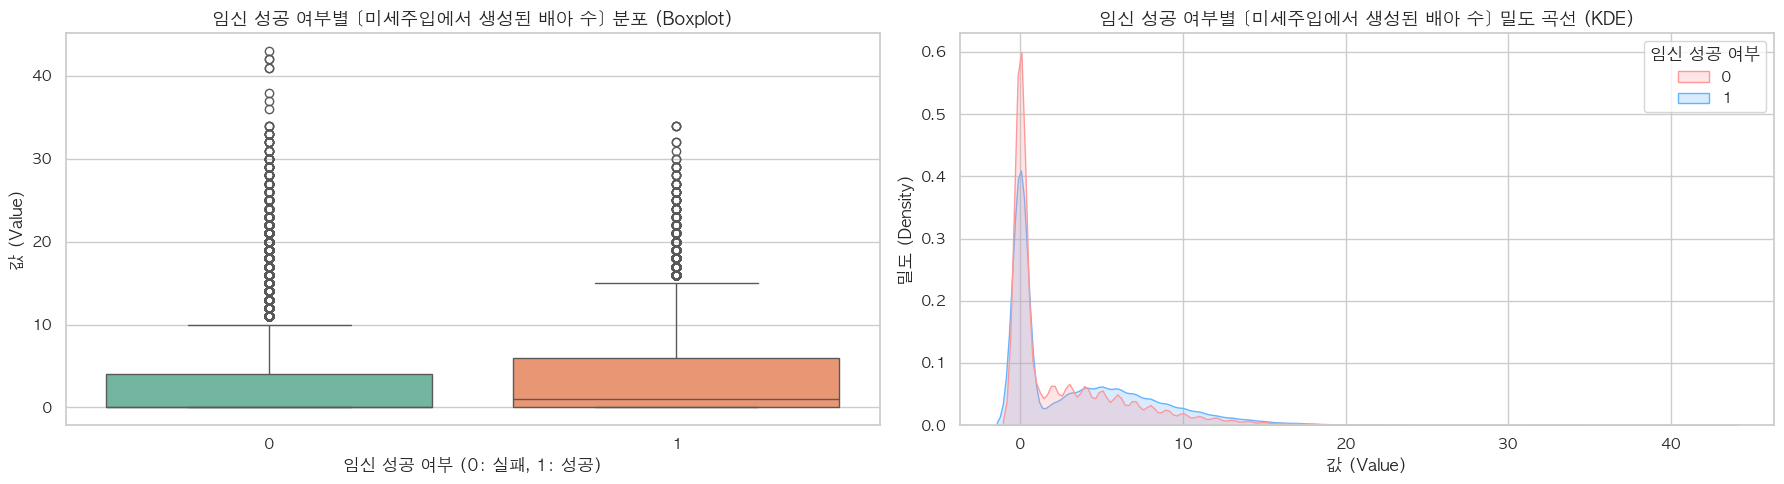


[5/20] [연속형 분석] 변수명: 이식된 배아 수
count    250060.000000
mean          1.368156
std           0.771961
min           0.000000
25%           1.000000
50%           1.000000
75%           2.000000
max           3.000000
Name: 이식된 배아 수, dtype: float64
------------------------------------------------------------


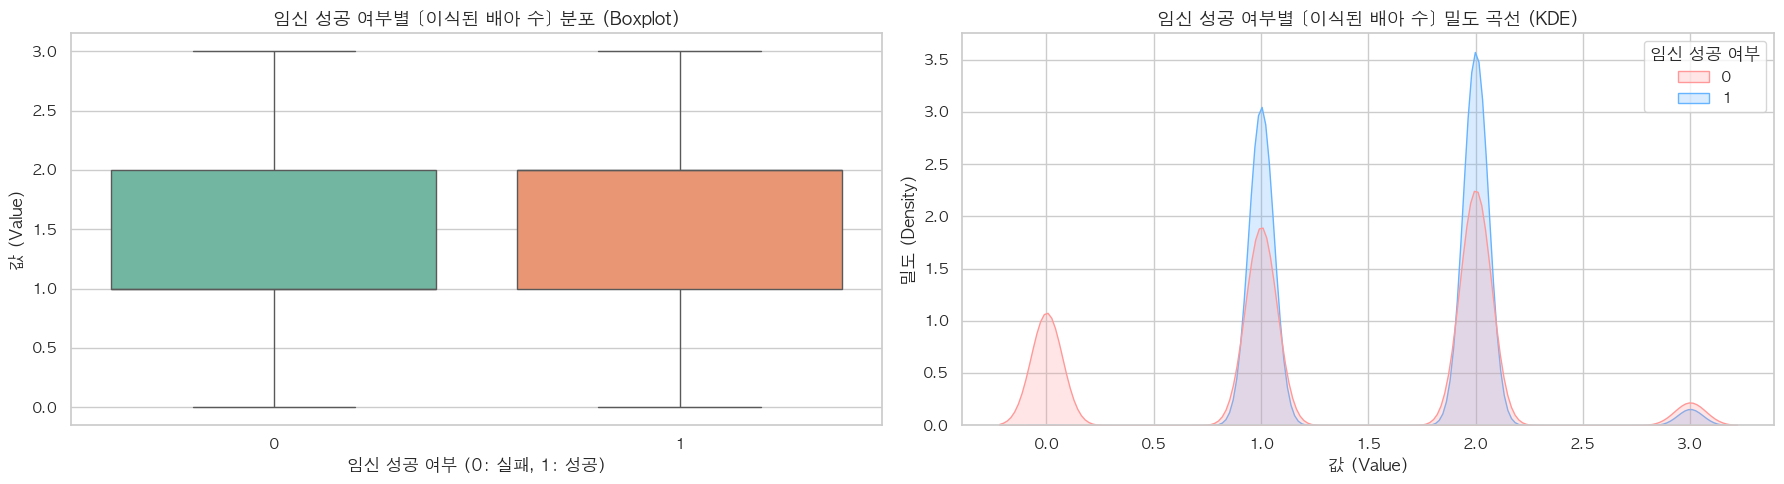


[6/20] [연속형 분석] 변수명: 미세주입 배아 이식 수
count    250060.000000
mean          0.724718
std           0.894352
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max           3.000000
Name: 미세주입 배아 이식 수, dtype: float64
------------------------------------------------------------


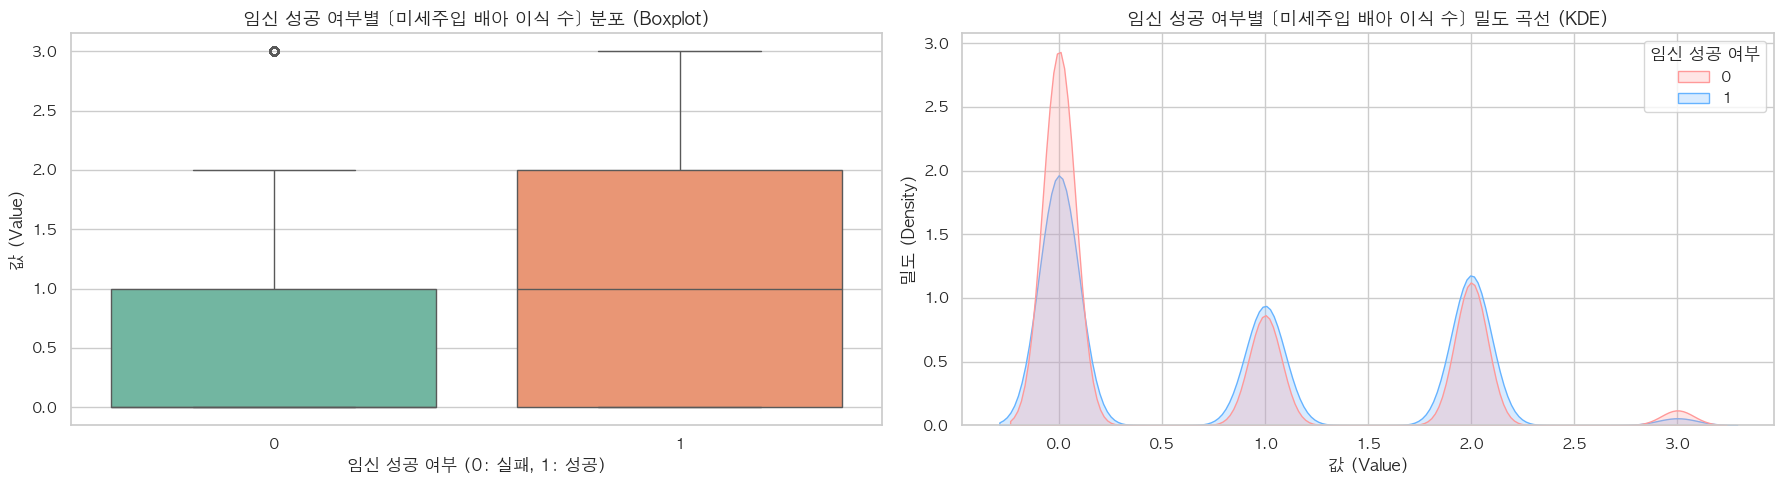


[7/20] [연속형 분석] 변수명: 저장된 배아 수
count    250060.000000
mean          1.185975
std           2.502318
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max          51.000000
Name: 저장된 배아 수, dtype: float64
------------------------------------------------------------


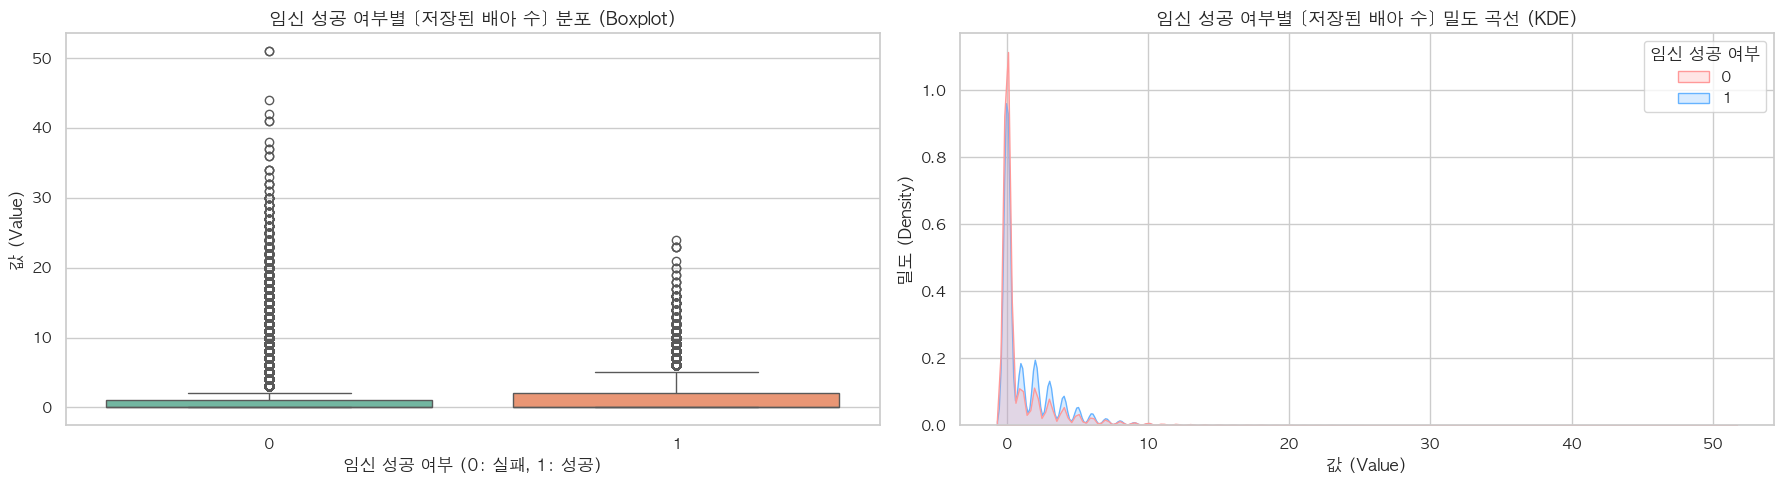


[8/20] [연속형 분석] 변수명: 미세주입 후 저장된 배아 수
count    250060.000000
mean          0.612933
std           1.842522
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          51.000000
Name: 미세주입 후 저장된 배아 수, dtype: float64
------------------------------------------------------------


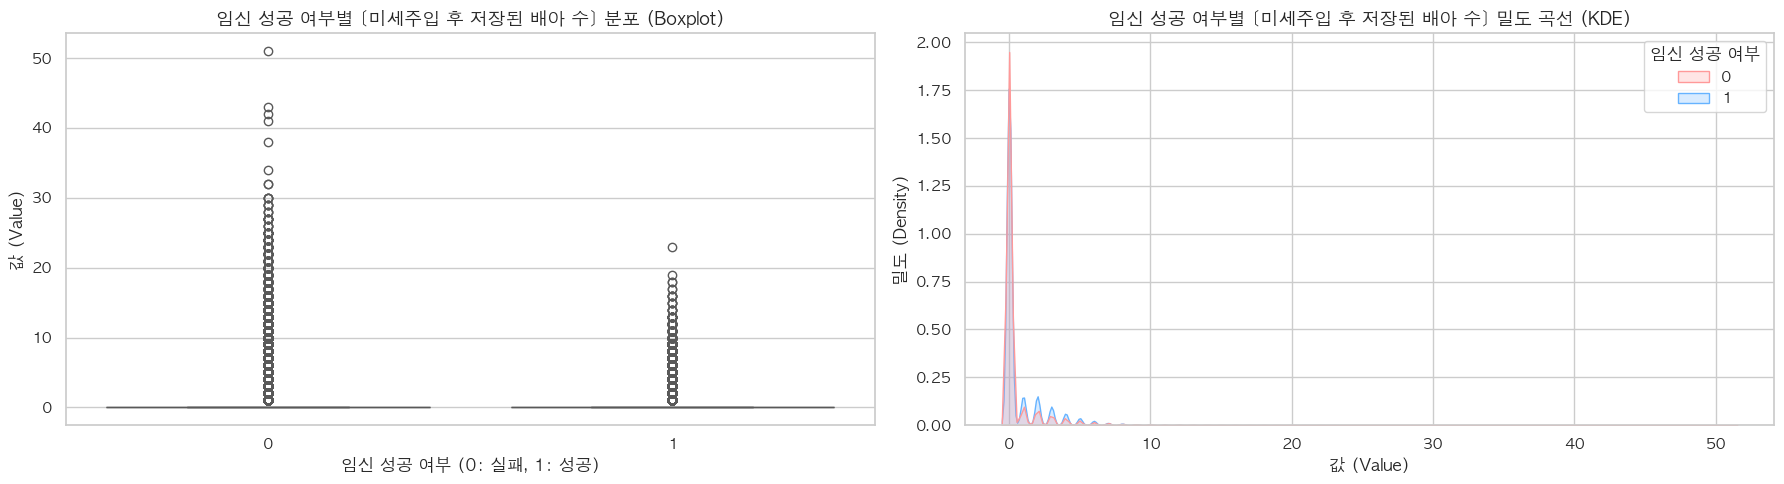


[9/20] [연속형 분석] 변수명: 해동된 배아 수
count    250060.000000
mean          0.454571
std           1.415320
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          32.000000
Name: 해동된 배아 수, dtype: float64
------------------------------------------------------------


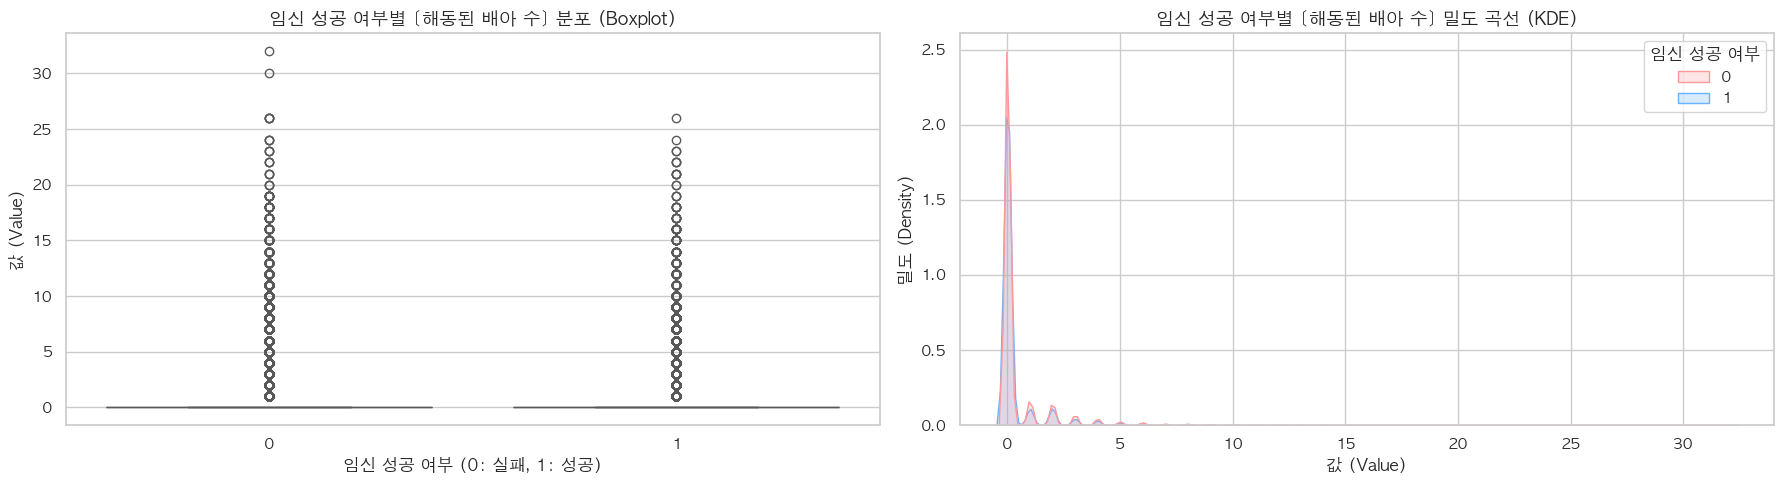


[10/20] [연속형 분석] 변수명: 해동 난자 수
count    250060.000000
mean          0.046401
std           0.688246
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          36.000000
Name: 해동 난자 수, dtype: float64
------------------------------------------------------------


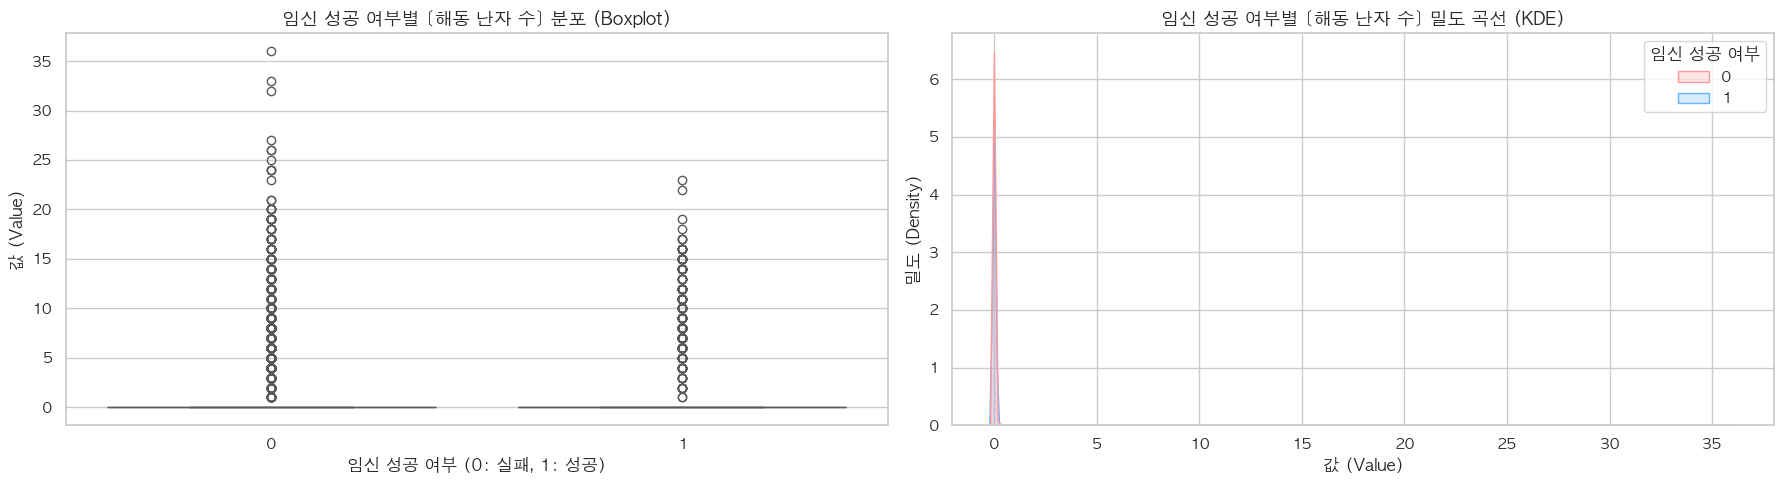


[11/20] [연속형 분석] 변수명: 수집된 신선 난자 수
count    250060.000000
mean          8.563717
std           7.317230
min           0.000000
25%           2.000000
50%           8.000000
75%          13.000000
max          51.000000
Name: 수집된 신선 난자 수, dtype: float64
------------------------------------------------------------


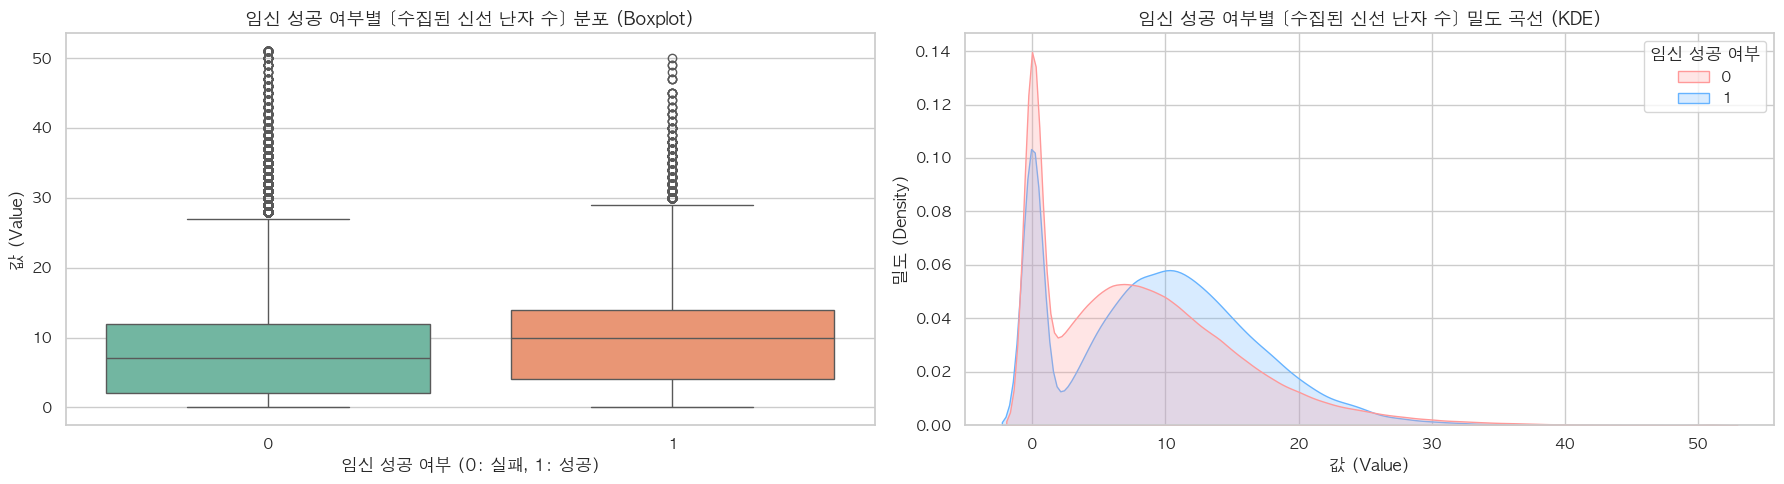


[12/20] [연속형 분석] 변수명: 저장된 신선 난자 수
count    250060.000000
mean          0.093418
std           1.105882
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          51.000000
Name: 저장된 신선 난자 수, dtype: float64
------------------------------------------------------------


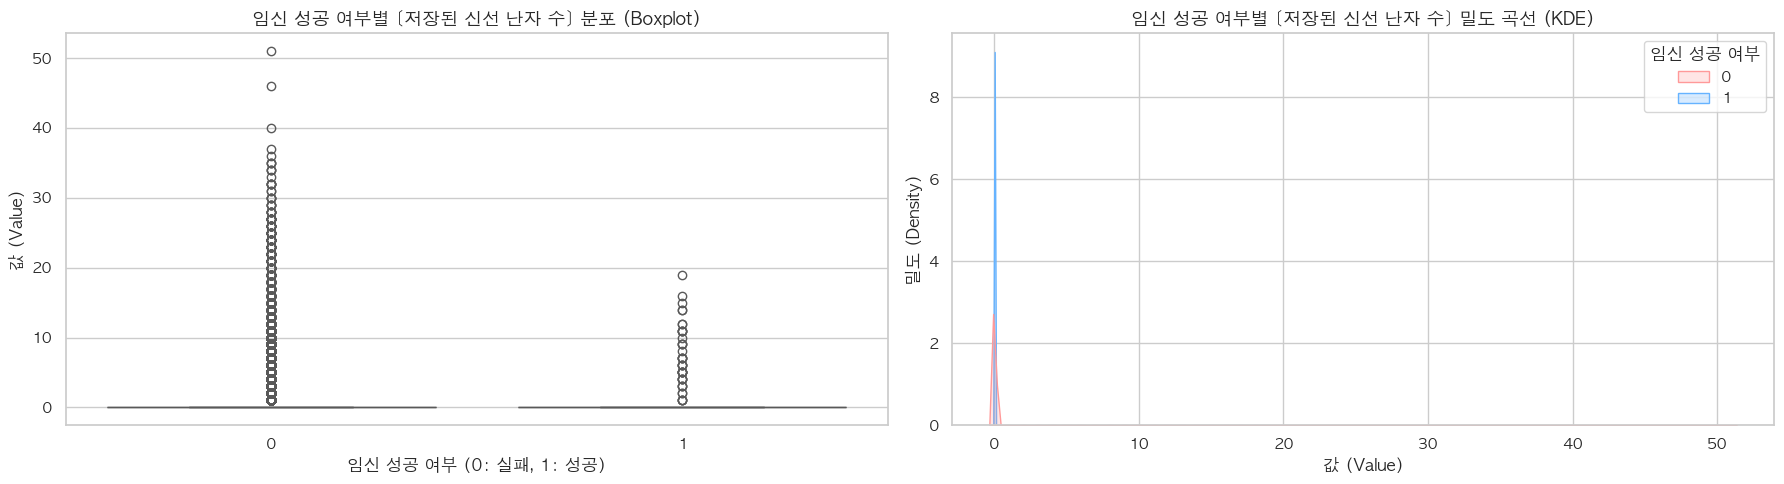


[13/20] [연속형 분석] 변수명: 혼합된 난자 수
count    250060.000000
mean          7.698928
std           6.451914
min           0.000000
25%           3.000000
50%           7.000000
75%          11.000000
max          51.000000
Name: 혼합된 난자 수, dtype: float64
------------------------------------------------------------


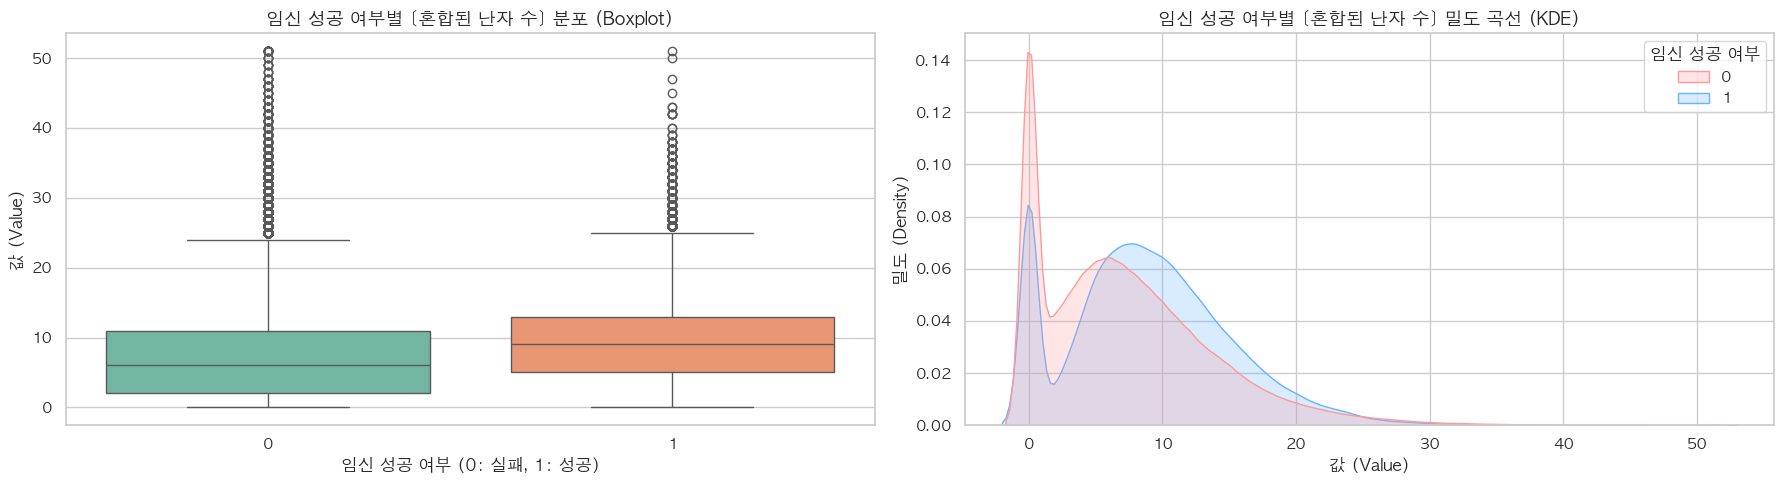


[14/20] [연속형 분석] 변수명: 파트너 정자와 혼합된 난자 수
count    250060.000000
mean          7.107326
std           6.532466
min           0.000000
25%           0.000000
50%           6.000000
75%          11.000000
max          51.000000
Name: 파트너 정자와 혼합된 난자 수, dtype: float64
------------------------------------------------------------


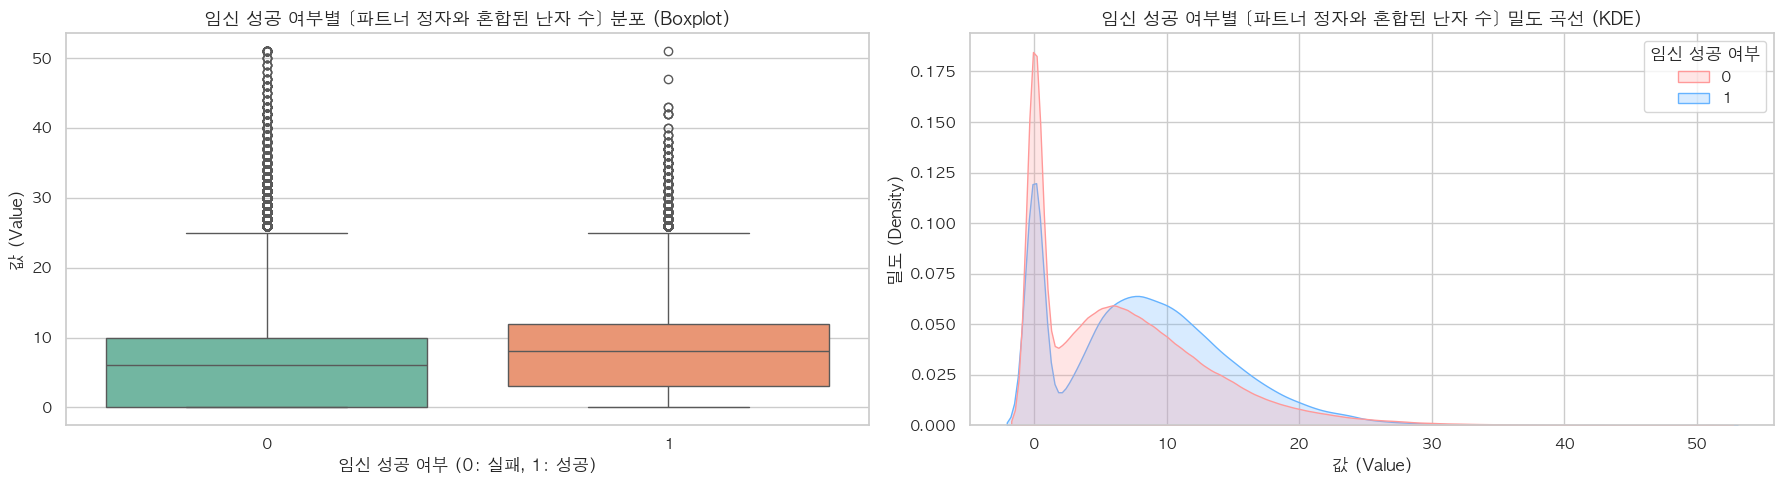


[15/20] [연속형 분석] 변수명: 기증자 정자와 혼합된 난자 수
count    250060.000000
mean          0.534728
std           2.509487
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          50.000000
Name: 기증자 정자와 혼합된 난자 수, dtype: float64
------------------------------------------------------------


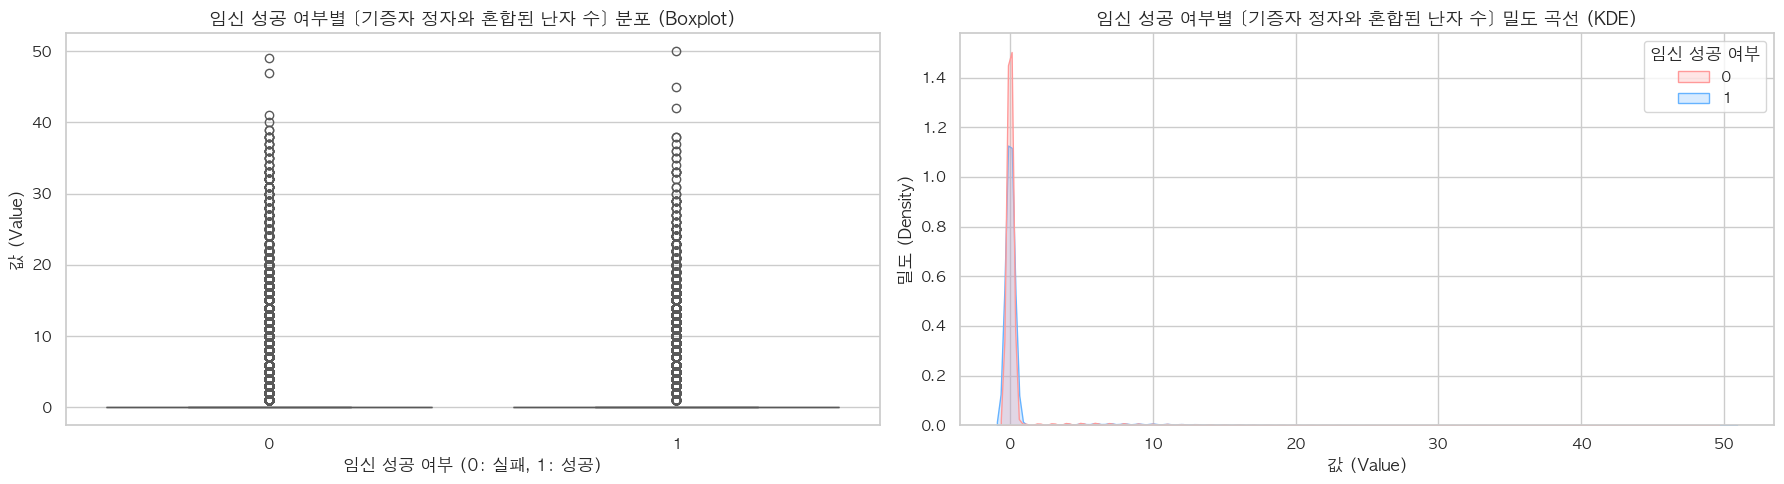


[16/20] [연속형 분석] 변수명: 난자 채취 경과일
count    198863.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: 난자 채취 경과일, dtype: float64
------------------------------------------------------------


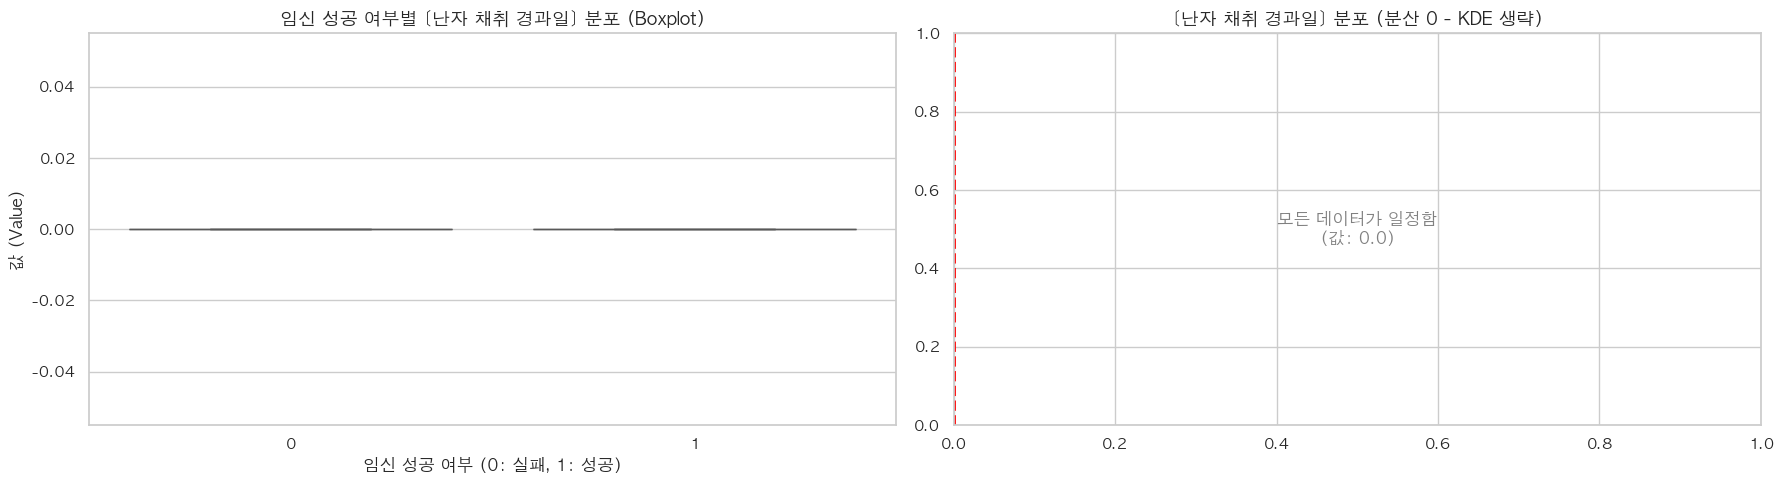


[17/20] [연속형 분석] 변수명: 난자 해동 경과일
count    1436.000000
mean        0.001393
std         0.037307
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: 난자 해동 경과일, dtype: float64
------------------------------------------------------------


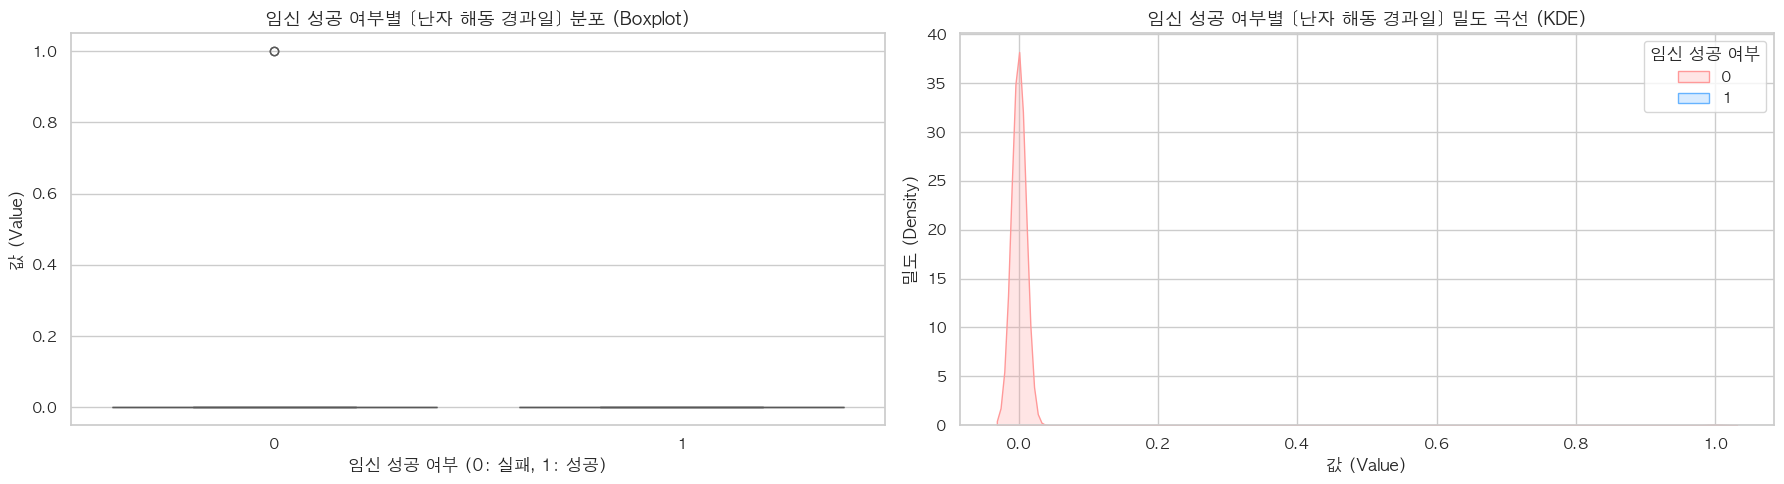


[18/20] [연속형 분석] 변수명: 난자 혼합 경과일
count    202616.000000
mean          0.005385
std           0.111504
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           7.000000
Name: 난자 혼합 경과일, dtype: float64
------------------------------------------------------------


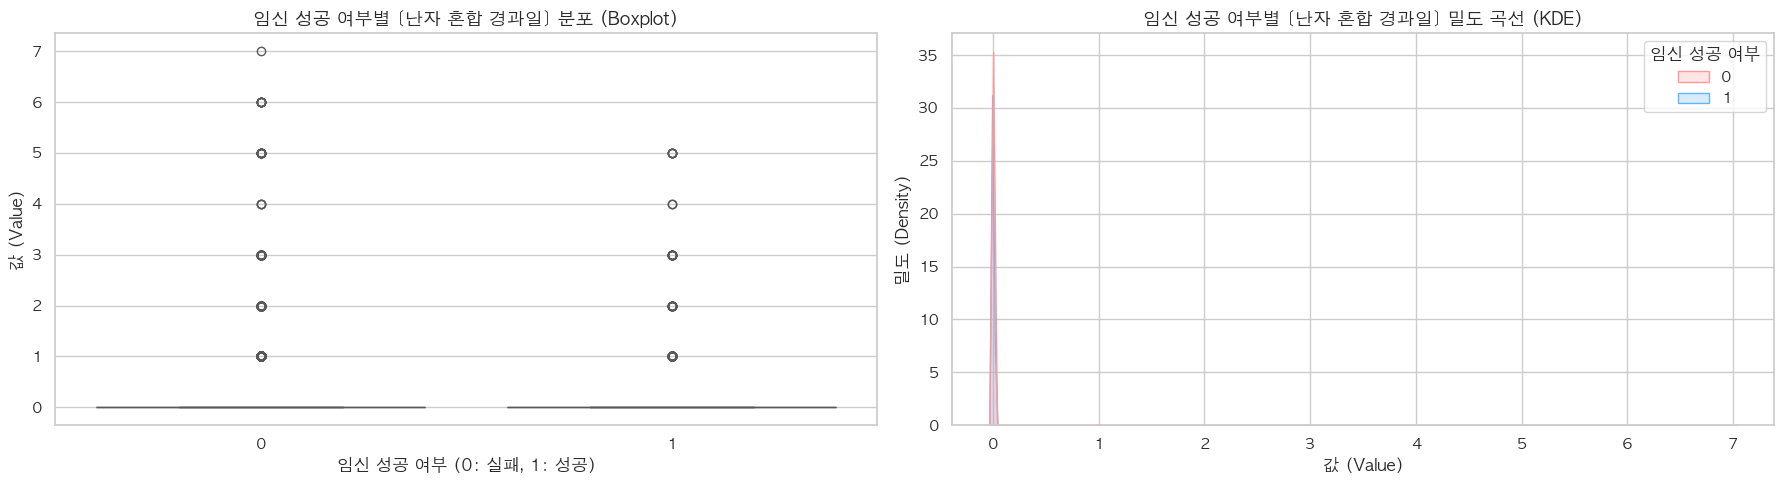


[19/20] [연속형 분석] 변수명: 배아 이식 경과일
count    212785.000000
mean          3.254741
std           1.715697
min           0.000000
25%           2.000000
50%           3.000000
75%           5.000000
max           7.000000
Name: 배아 이식 경과일, dtype: float64
------------------------------------------------------------


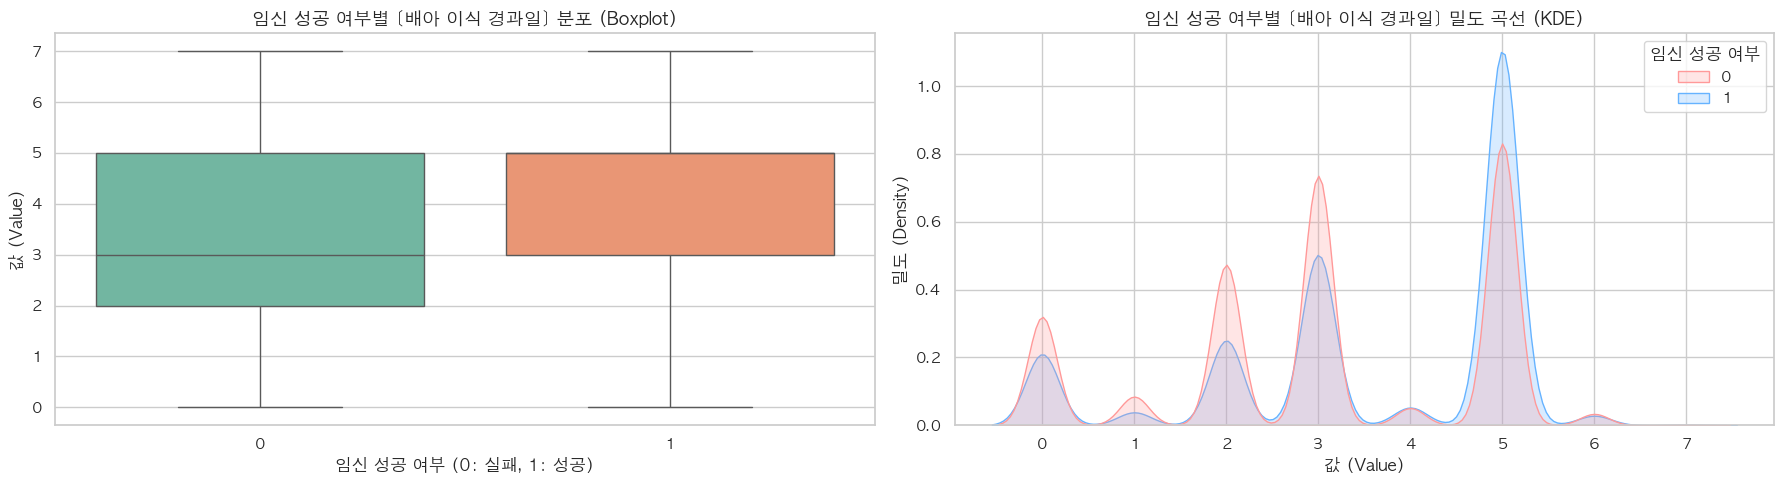


[20/20] [연속형 분석] 변수명: 배아 해동 경과일
count    40369.000000
mean         0.045629
std          0.418672
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          7.000000
Name: 배아 해동 경과일, dtype: float64
------------------------------------------------------------


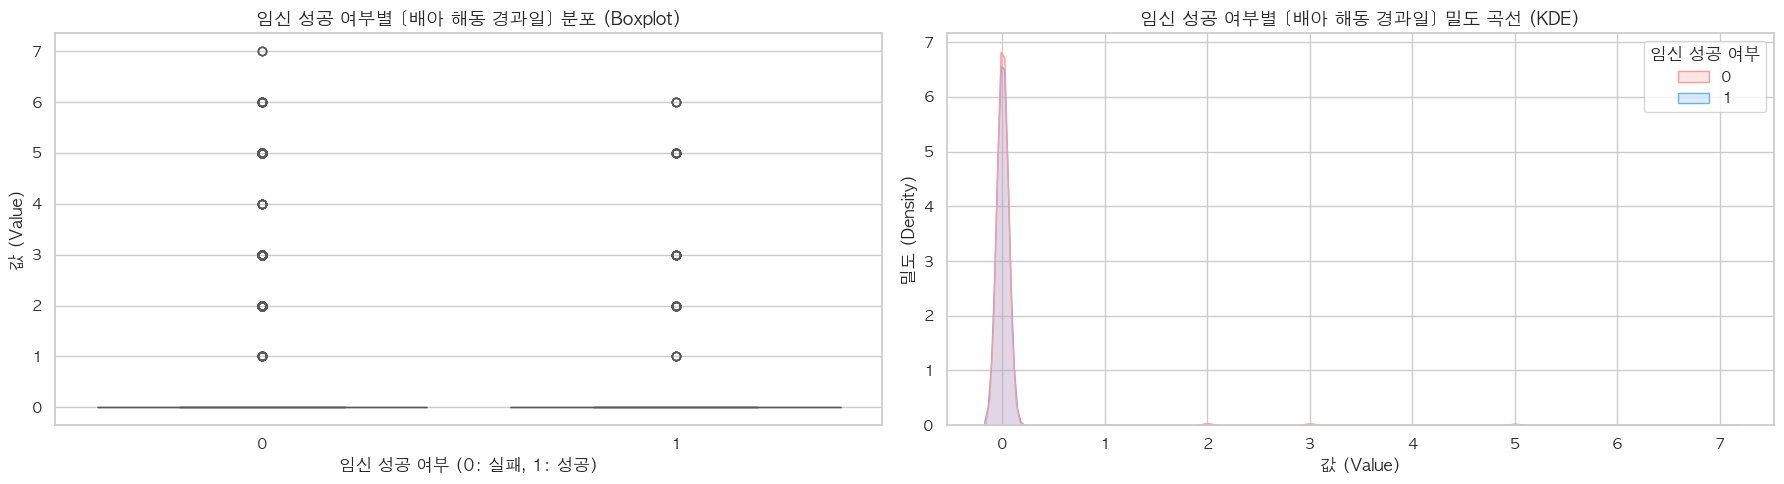

In [17]:
# 숫자형-연속형 변수 분석
for i, col in enumerate(continuous_numeric_columns):
    if col not in train.columns:
        continue

    print(f"\n[{i+1}/{len(continuous_numeric_columns)}] [연속형 분석] 변수명: {col}")
    print(train[col].describe())    # 기초 통계량(평균, 중앙값, 사분위수 등)
    print("-" * 60)

    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    # [왼쪽] boxplot - 임신 성공 여부 별 분포 및 이상치 확인
    sns.boxplot(
        data=train,
        x='임신 성공 여부',
        y=col,
        ax=axes[0],
        palette='Set2',
        hue='임신 성공 여부',
        legend=False
    )
    axes[0].set_title(f'임신 성공 여부별 [{col}] 분포 (Boxplot)', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('임신 성공 여부 (0: 실패, 1: 성공)')
    axes[0].set_ylabel('값 (Value)')

    # [오른쪽] KDE Plot - 임신 성공 여부 별 데이터 밀도 곡선 겹쳐보기
    clean_df = train.dropna(subset=[col])
    if not clean_df.empty:
        if clean_df[col].std() == 0:    # 데이터 표준편차(std)가 0인지 확인
            # 모든 값 같을 경우, KDE 대신 중앙값 선 하나로 안내 텍스트 표시
            single_value = clean_df[col].iloc[0]
            axes[1].axvline(
                x=single_value,
                color='red',
                linestyle='--',
                linewidth=2
            )
            axes[1].text(
                0.5, 0.5,
                f'모든 데이터가 일정함\n(값: {single_value})',
                ha='center',
                va='center',
                fontsize=12,
                color='gray',
                transform=axes[1].transAxes
            )
            axes[1].set_title(f'[{col}] 분포 (분산 0 - KDE 생략)', fontsize=13, fontweight='bold')
        else:   # 정상적인 경우에만 KDE Plot
            sns.kdeplot(
                data=clean_df,
                x=col,
                hue='임신 성공 여부',
                fill=True,
                common_norm=False,
                ax=axes[1],
                palette=['#ff9999', '#66b3ff']
            )
            axes[1].set_title(f'임신 성공 여부별 [{col}] 밀도 곡선 (KDE)', fontsize=13, fontweight='bold')
            axes[1].set_xlabel('값 (Value)')
            axes[1].set_ylabel('밀도 (Density)')
    else:
        axes[1].text(
            0.5, 0.5,
            '표시할 데이터가 없습니다 (전부 결측치)',
            ha='center',
            va='center',
            fontsize=12,
            color='gray',
            transform=axes[1].transAxes
        )
        axes[1].set_title(f'임신 성공 여부별 [{col}] 밀도 곡선 (KDE)')

    plt.tight_layout()
    plt.show()


[1/27] [범주형-숫자형 분석] 변수명: 배란 자극 여부


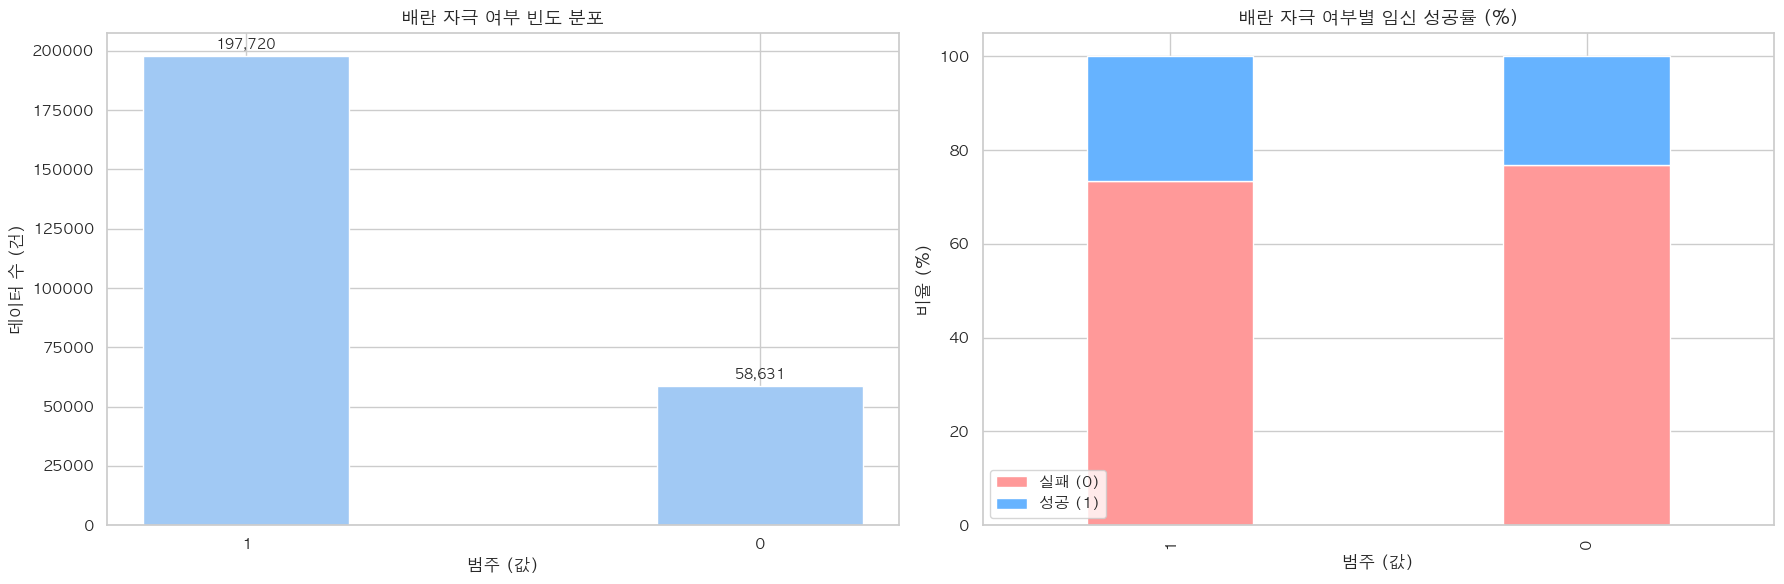


[2/27] [범주형-숫자형 분석] 변수명: 단일 배아 이식 여부


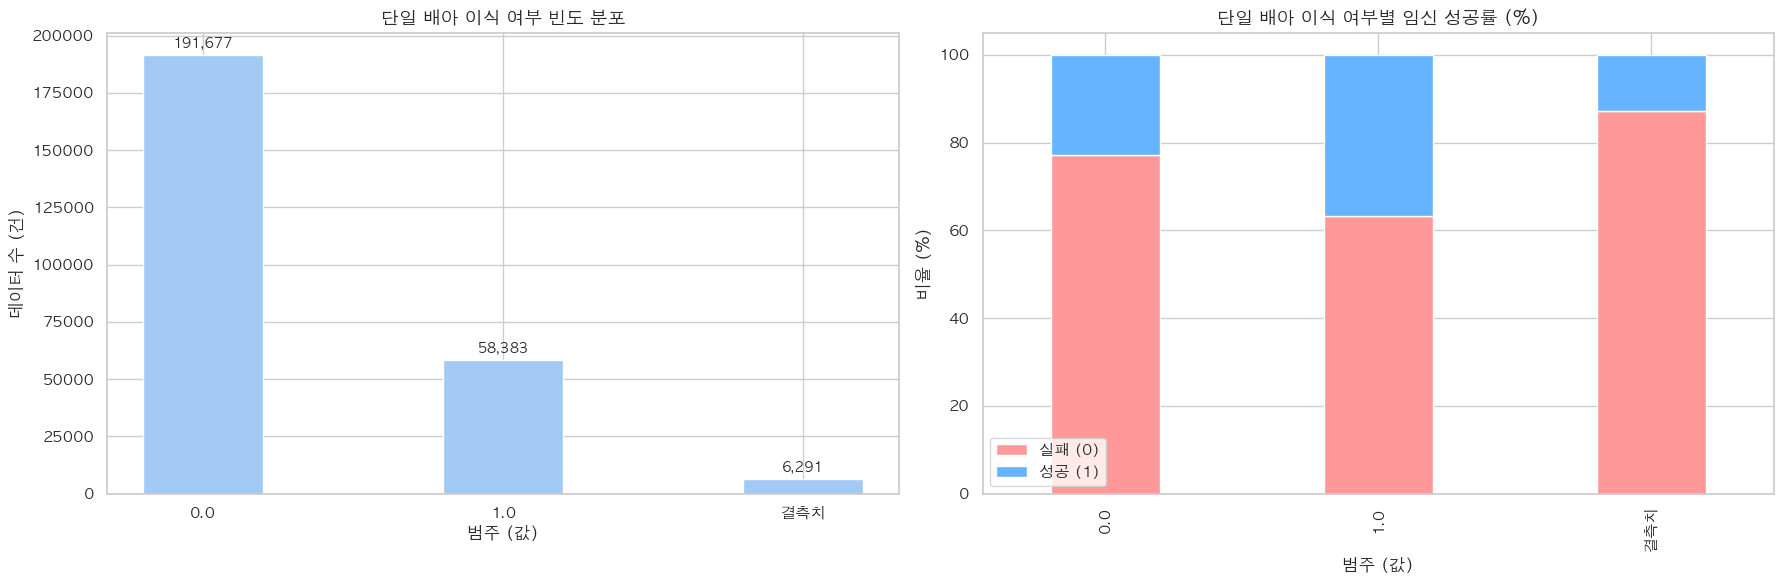


[3/27] [범주형-숫자형 분석] 변수명: 착상 전 유전 검사 사용 여부


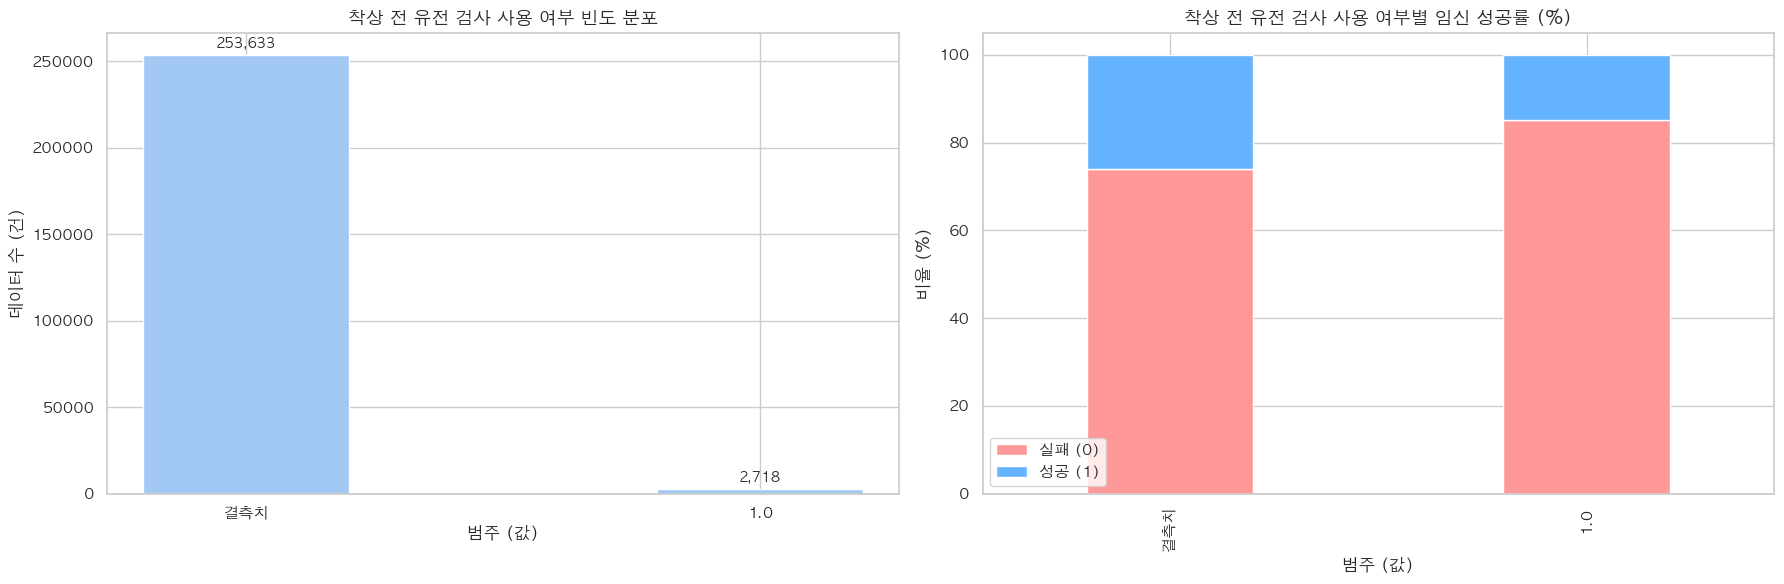


[4/27] [범주형-숫자형 분석] 변수명: 착상 전 유전 진단 사용 여부


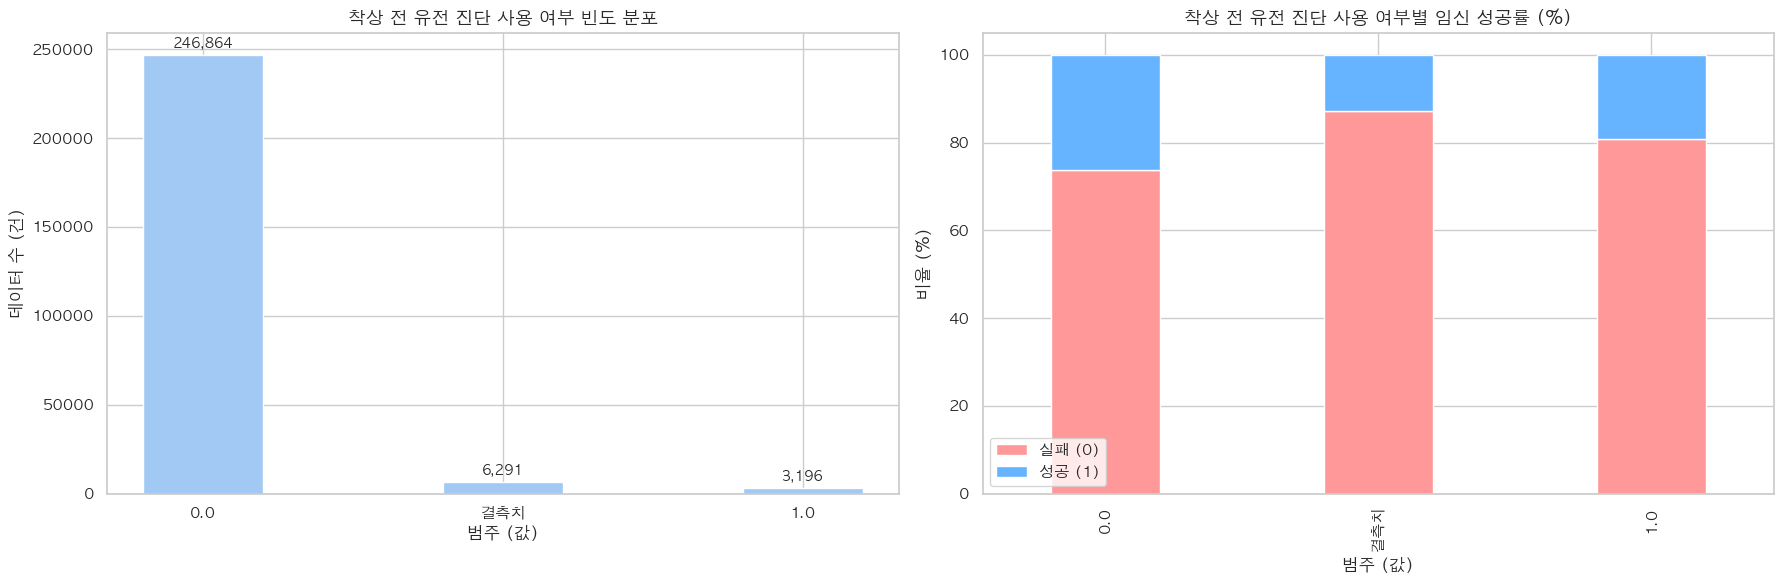


[5/27] [범주형-숫자형 분석] 변수명: 남성 주 불임 원인


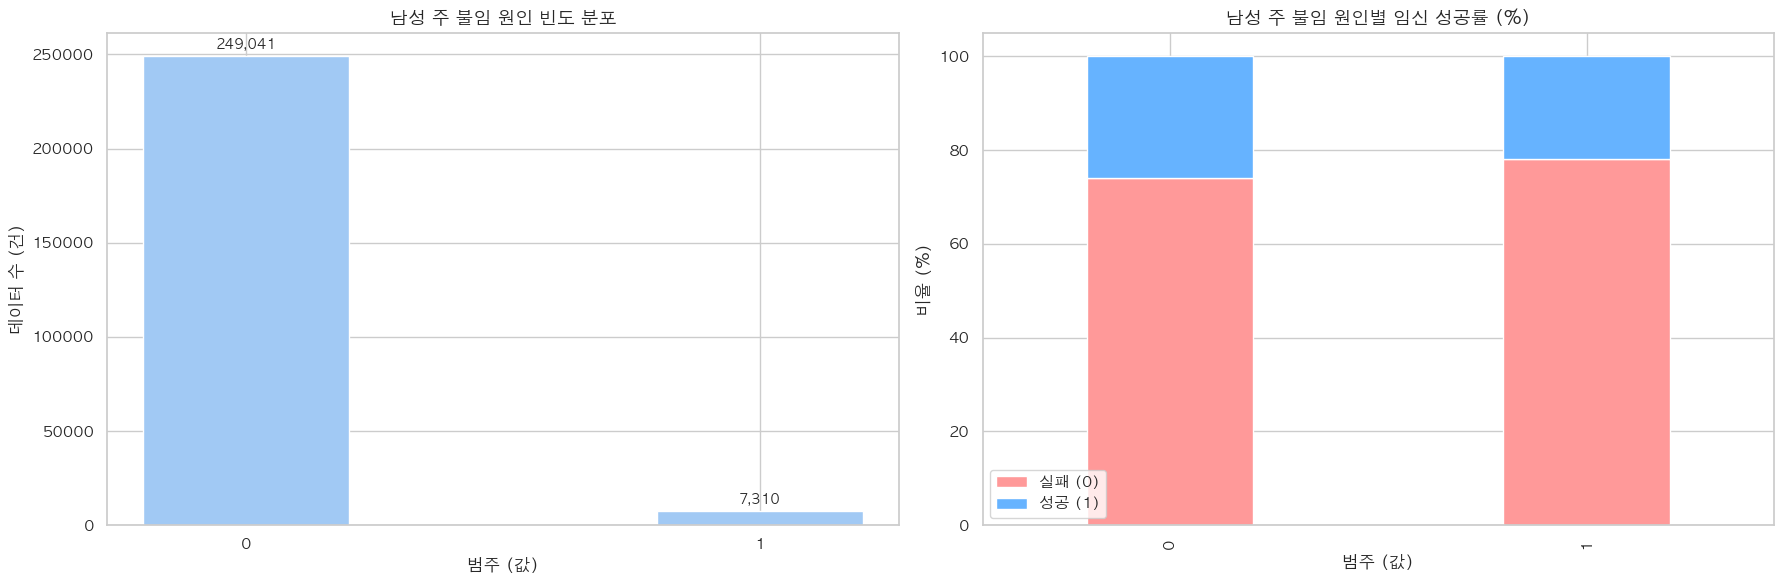


[6/27] [범주형-숫자형 분석] 변수명: 남성 부 불임 원인


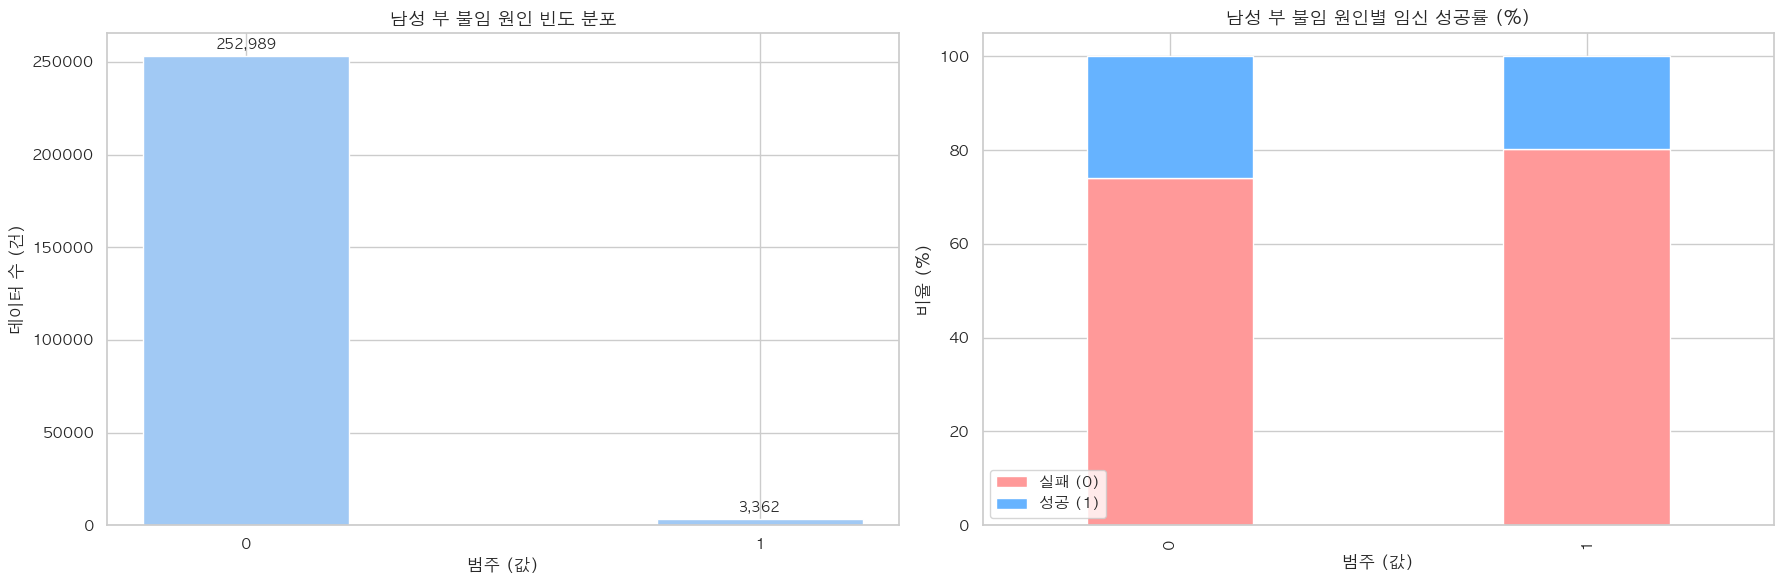


[7/27] [범주형-숫자형 분석] 변수명: 여성 주 불임 원인


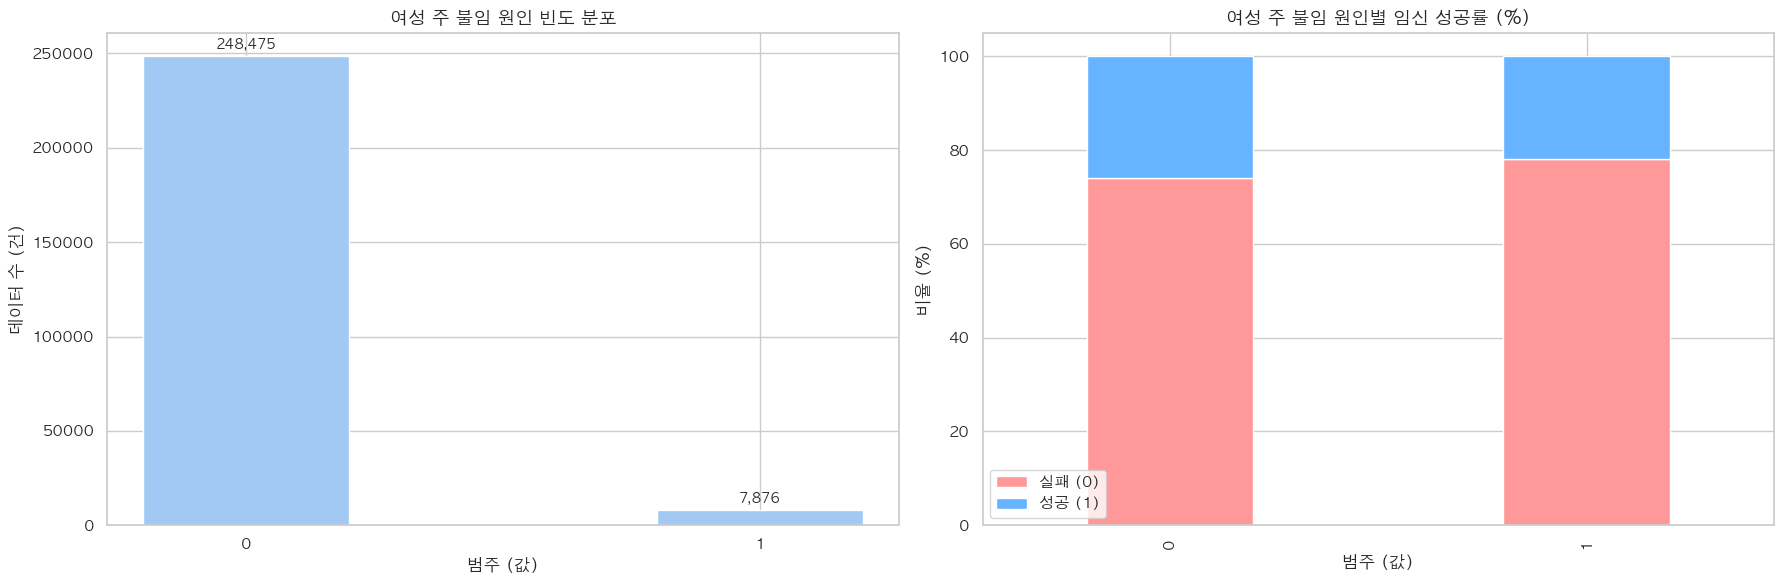


[8/27] [범주형-숫자형 분석] 변수명: 여성 부 불임 원인


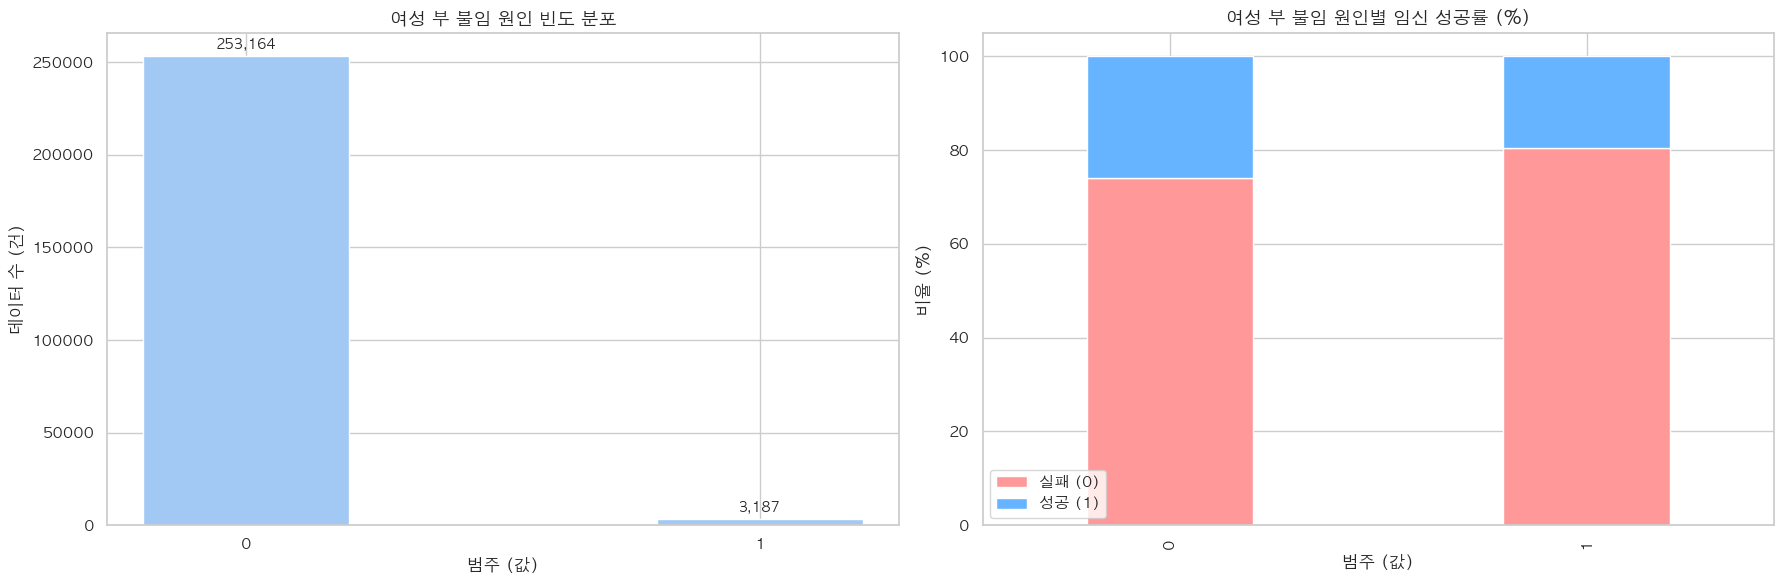


[9/27] [범주형-숫자형 분석] 변수명: 부부 주 불임 원인


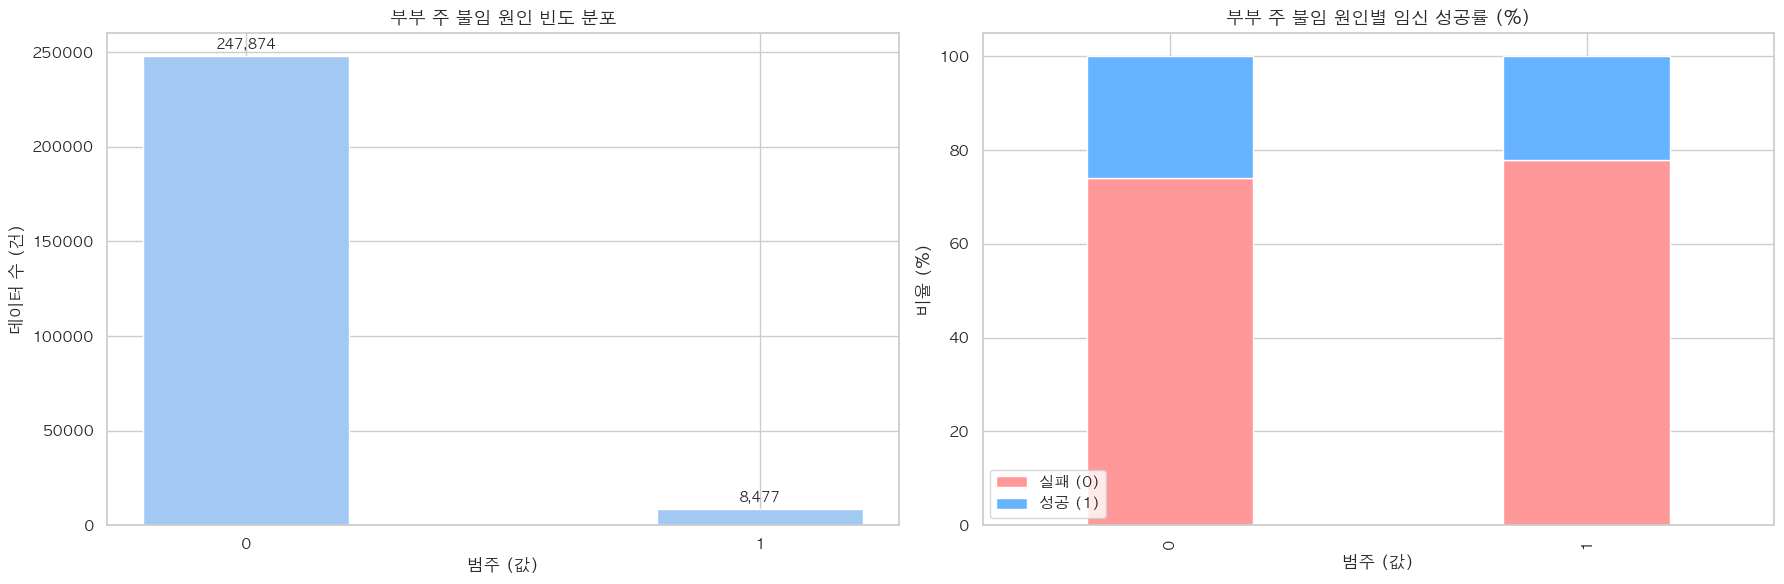


[10/27] [범주형-숫자형 분석] 변수명: 부부 부 불임 원인


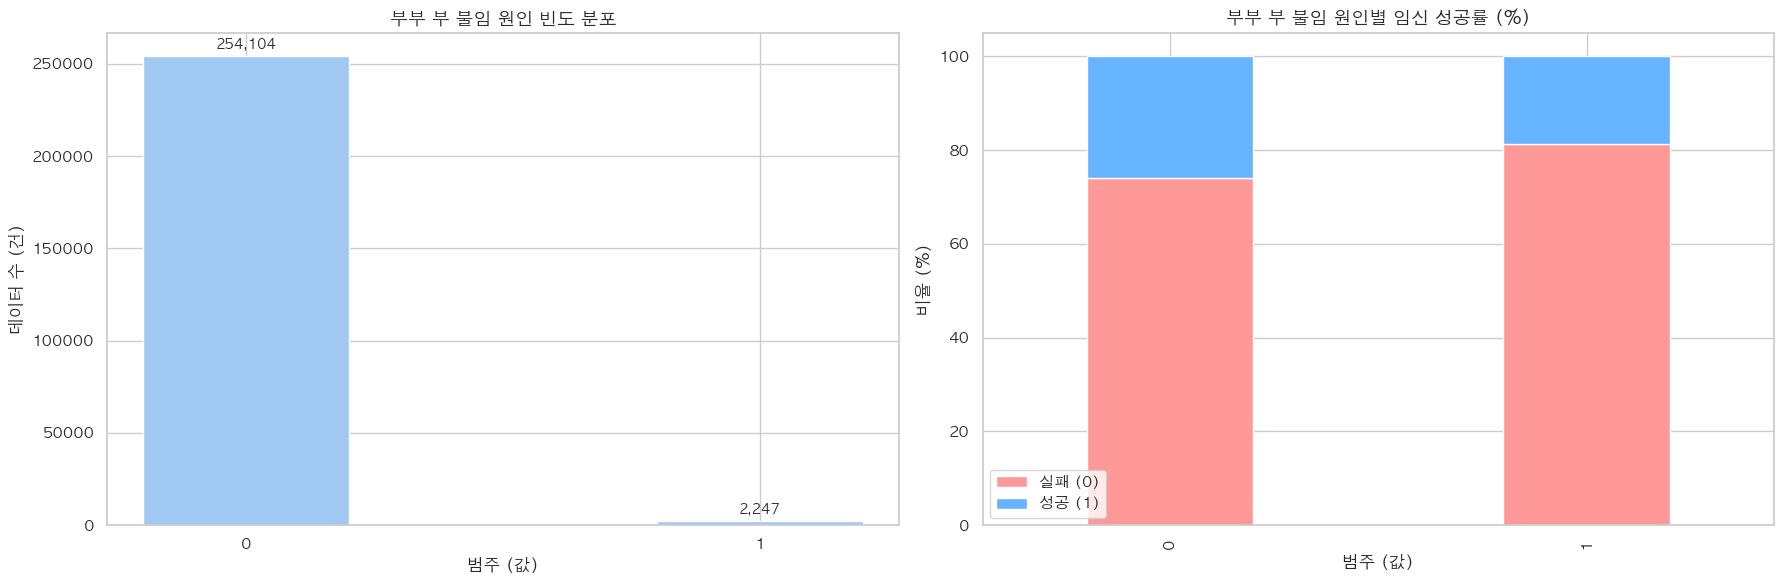


[11/27] [범주형-숫자형 분석] 변수명: 불명확 불임 원인


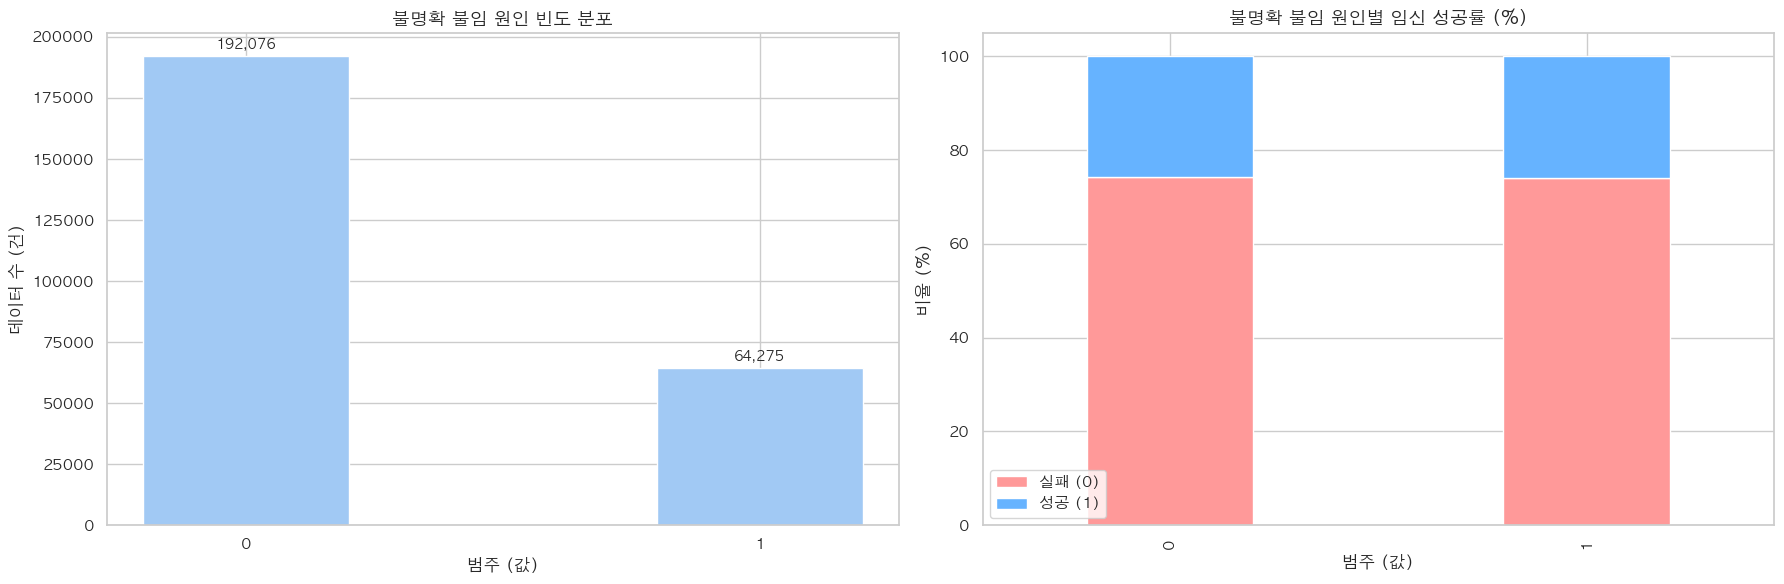


[12/27] [범주형-숫자형 분석] 변수명: 불임 원인 - 난관 질환


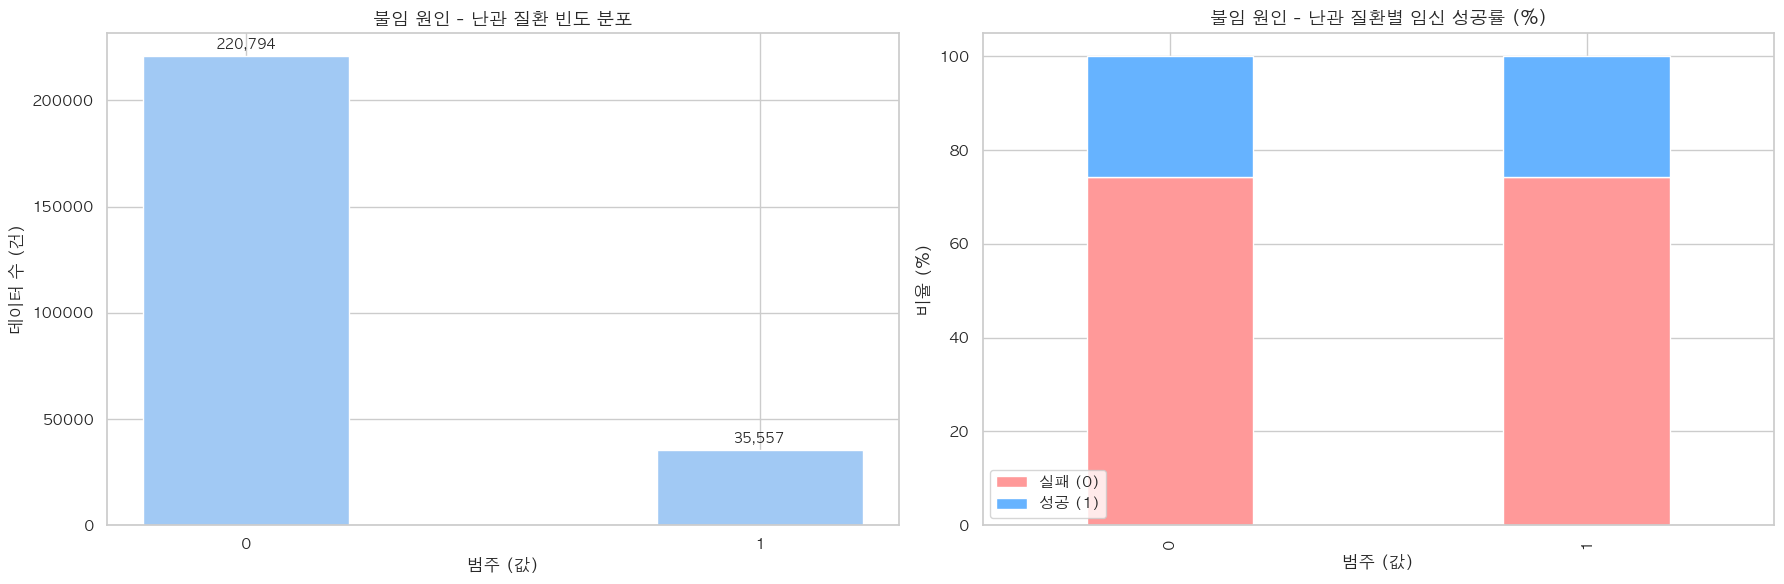


[13/27] [범주형-숫자형 분석] 변수명: 불임 원인 - 남성 요인


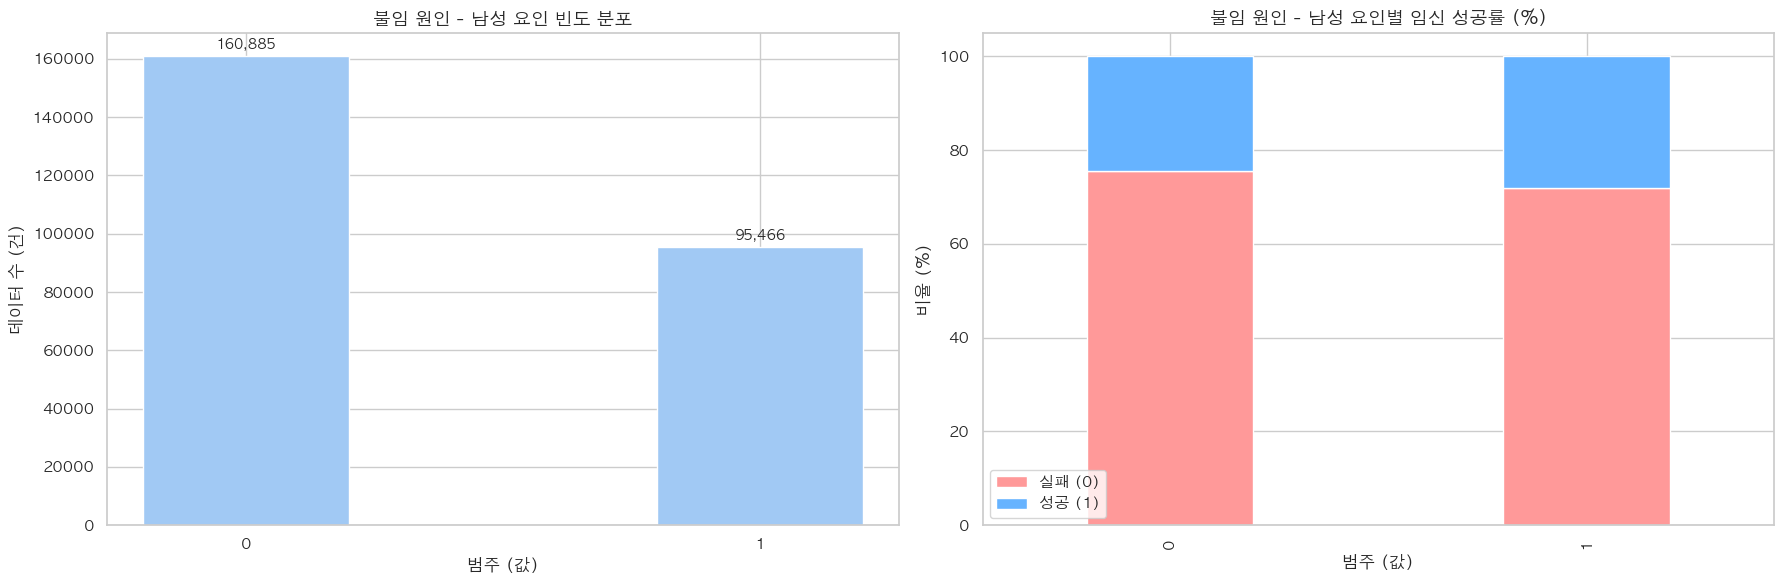


[14/27] [범주형-숫자형 분석] 변수명: 불임 원인 - 배란 장애


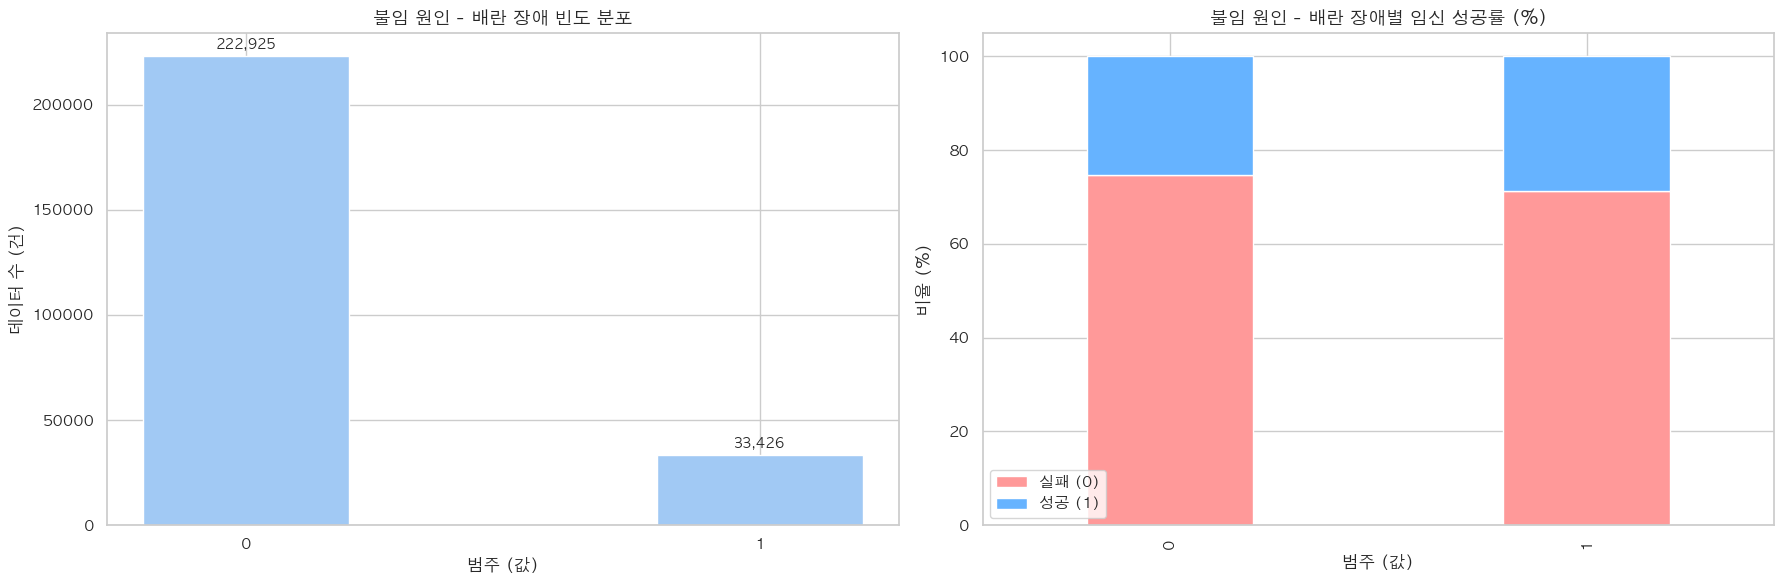


[15/27] [범주형-숫자형 분석] 변수명: 불임 원인 - 여성 요인


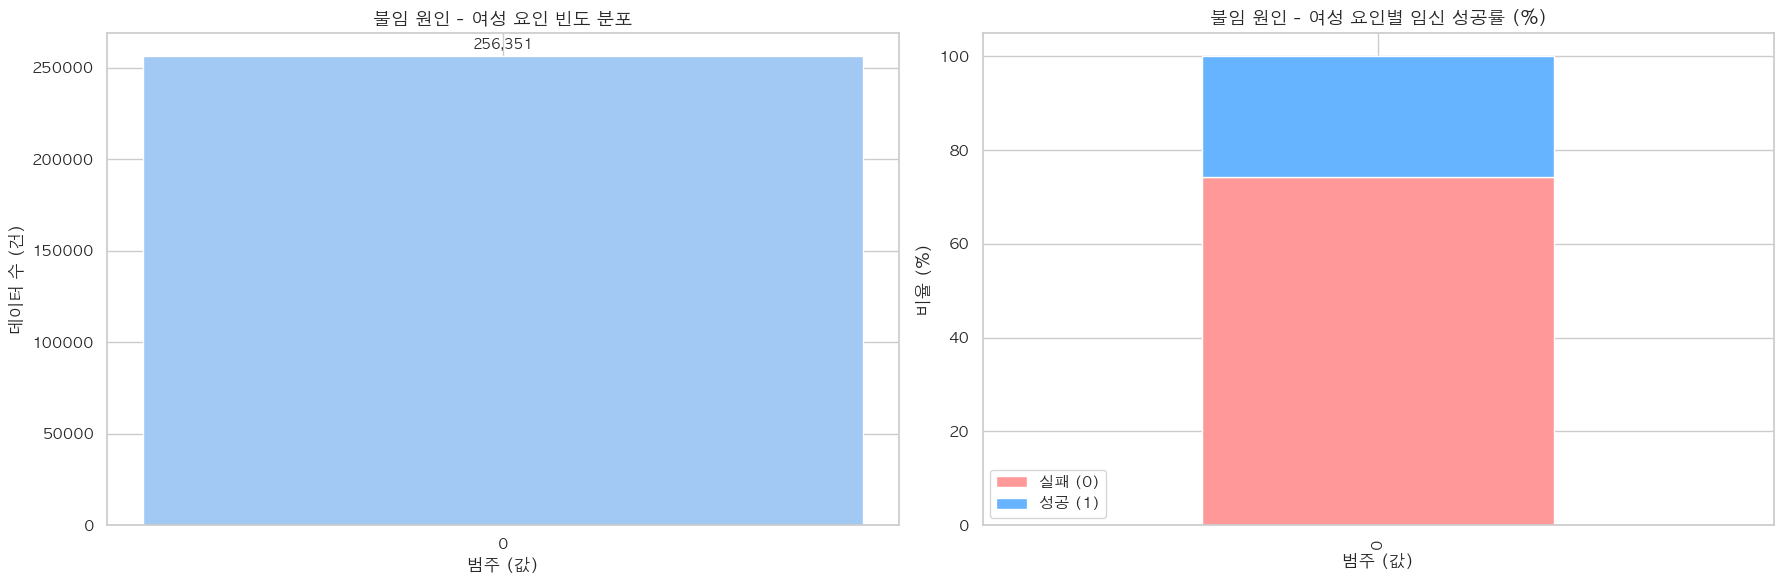


[16/27] [범주형-숫자형 분석] 변수명: 불임 원인 - 자궁경부 문제


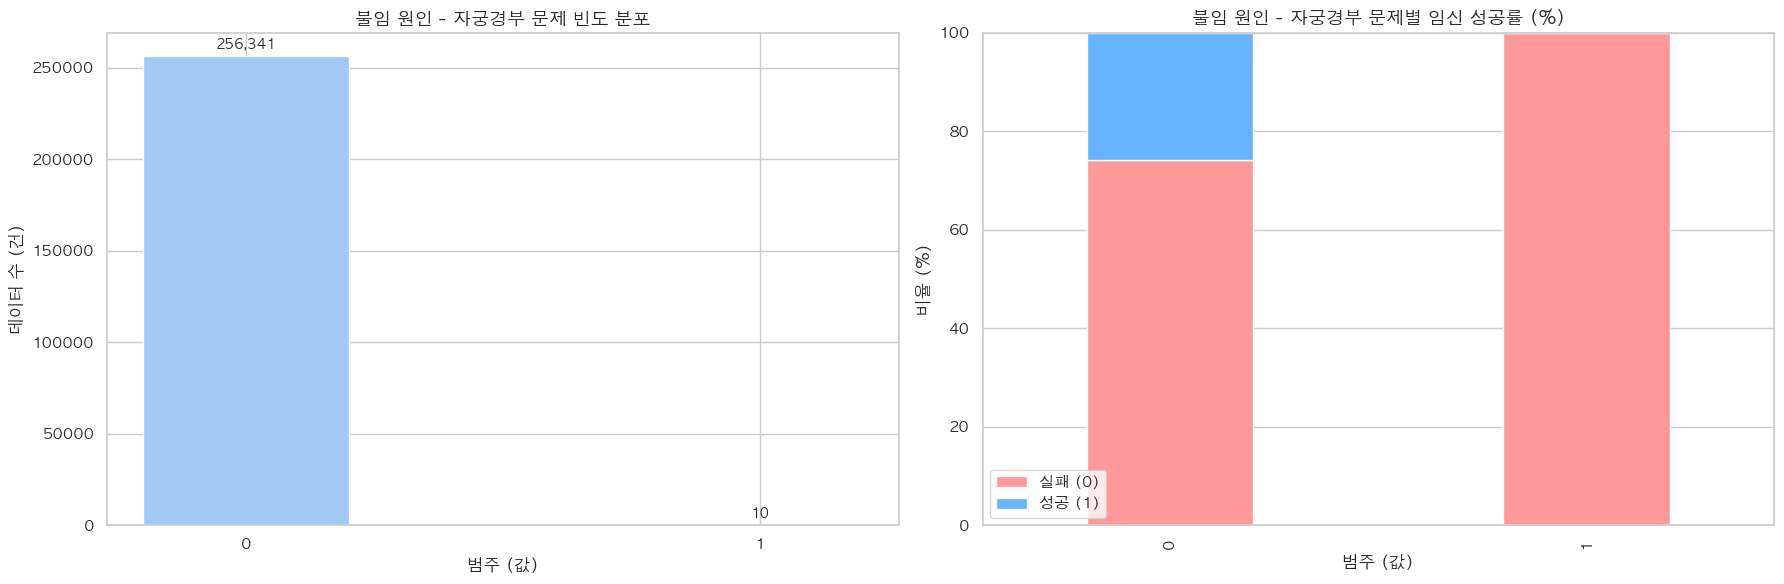


[17/27] [범주형-숫자형 분석] 변수명: 불임 원인 - 자궁내막증


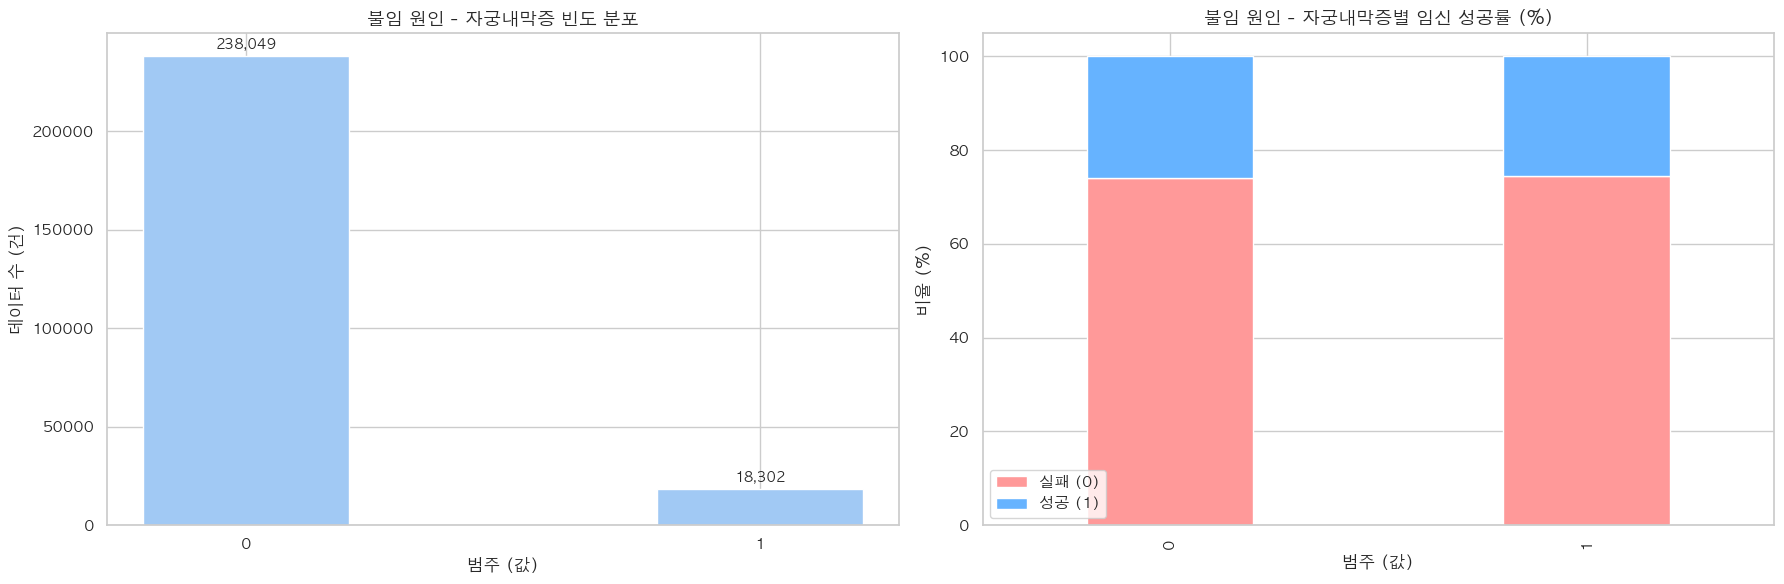


[18/27] [범주형-숫자형 분석] 변수명: 불임 원인 - 정자 농도


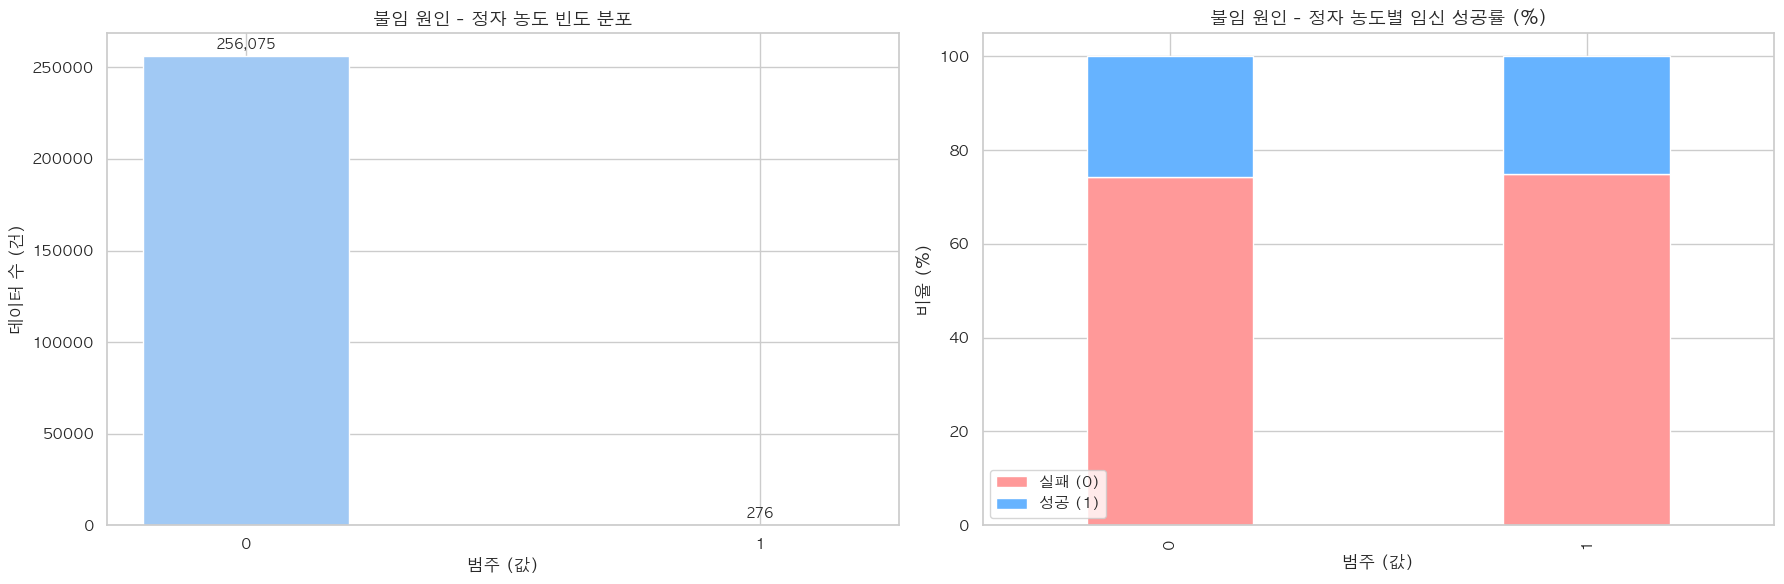


[19/27] [범주형-숫자형 분석] 변수명: 불임 원인 - 정자 면역학적 요인


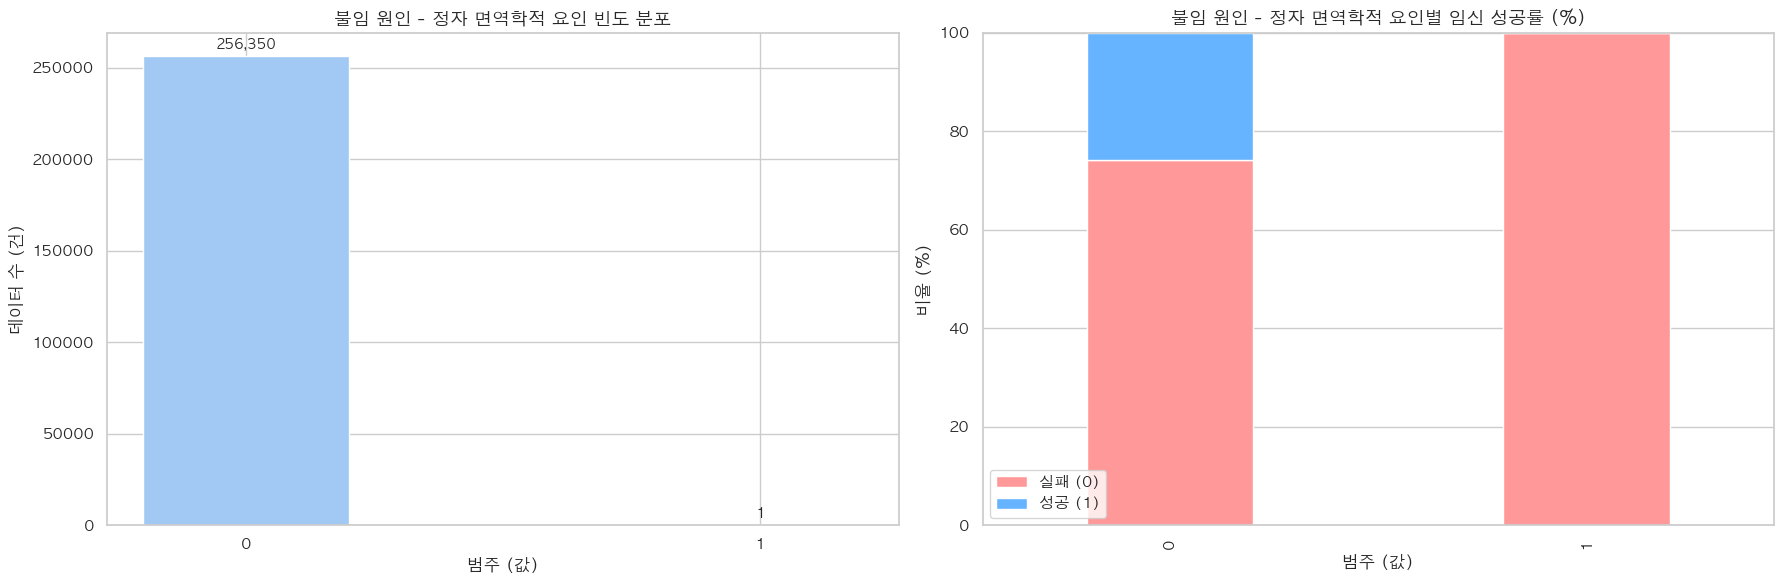


[20/27] [범주형-숫자형 분석] 변수명: 불임 원인 - 정자 운동성


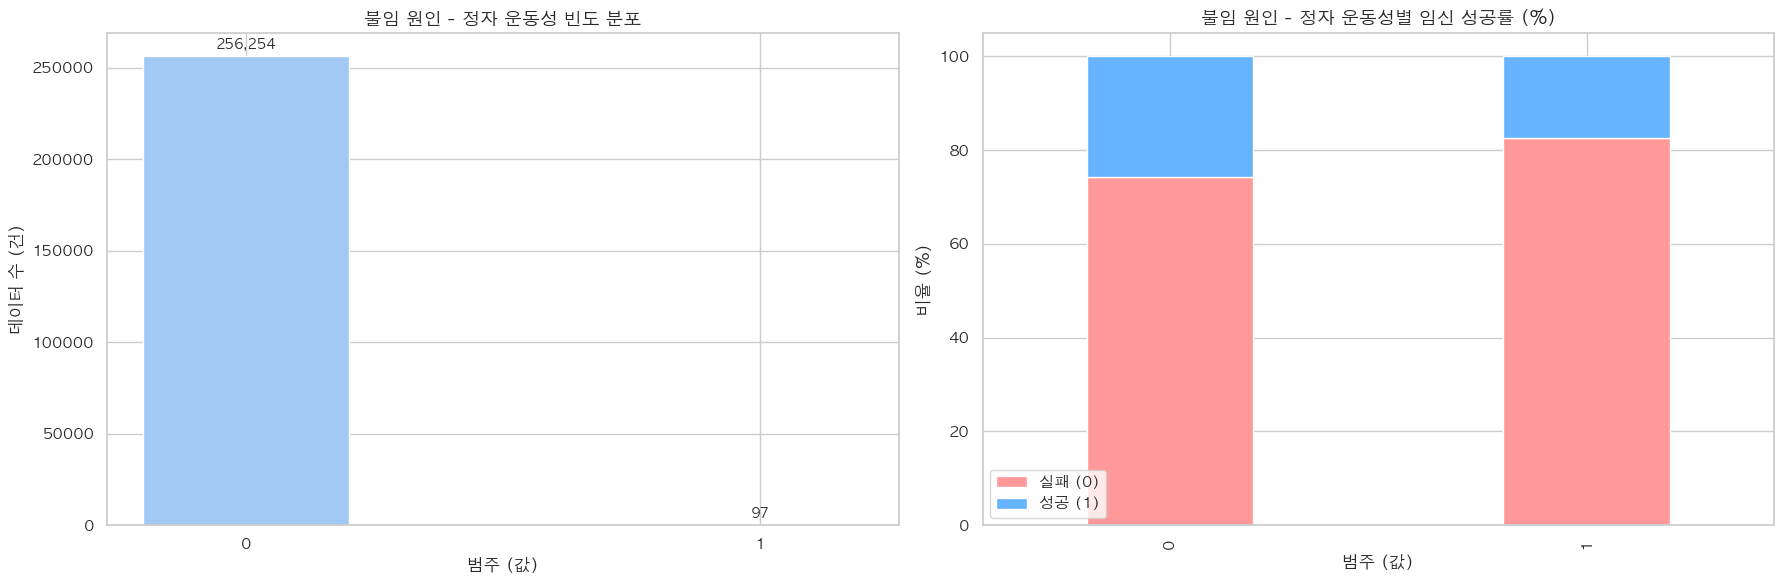


[21/27] [범주형-숫자형 분석] 변수명: 불임 원인 - 정자 형태


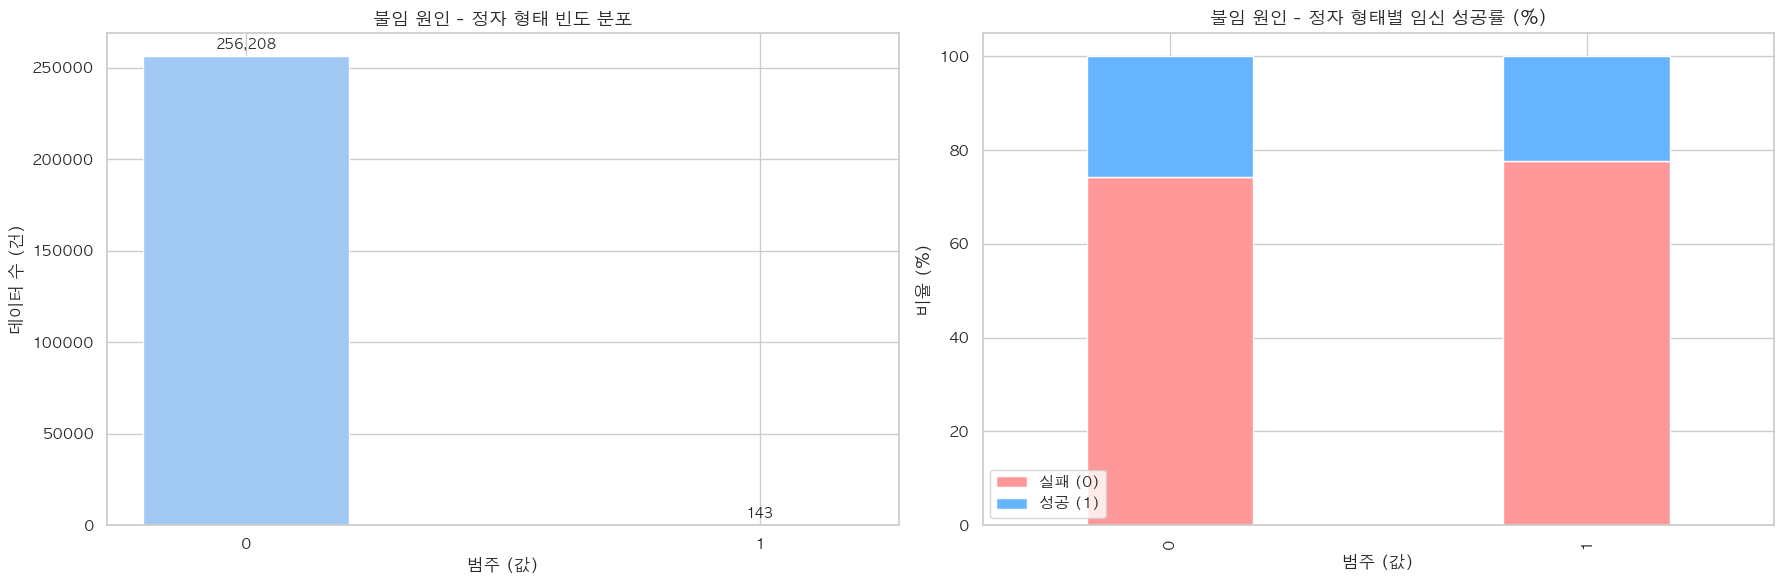


[22/27] [범주형-숫자형 분석] 변수명: 동결 배아 사용 여부


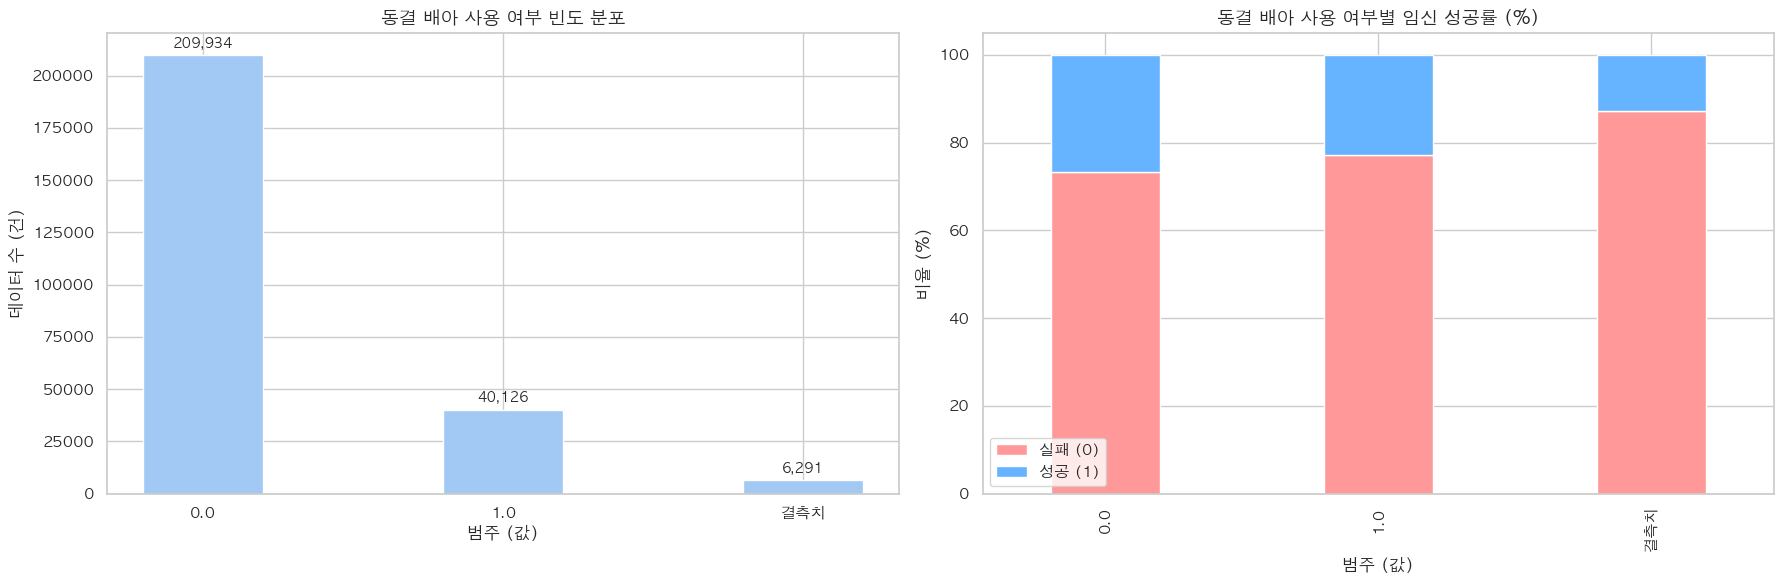


[23/27] [범주형-숫자형 분석] 변수명: 신선 배아 사용 여부


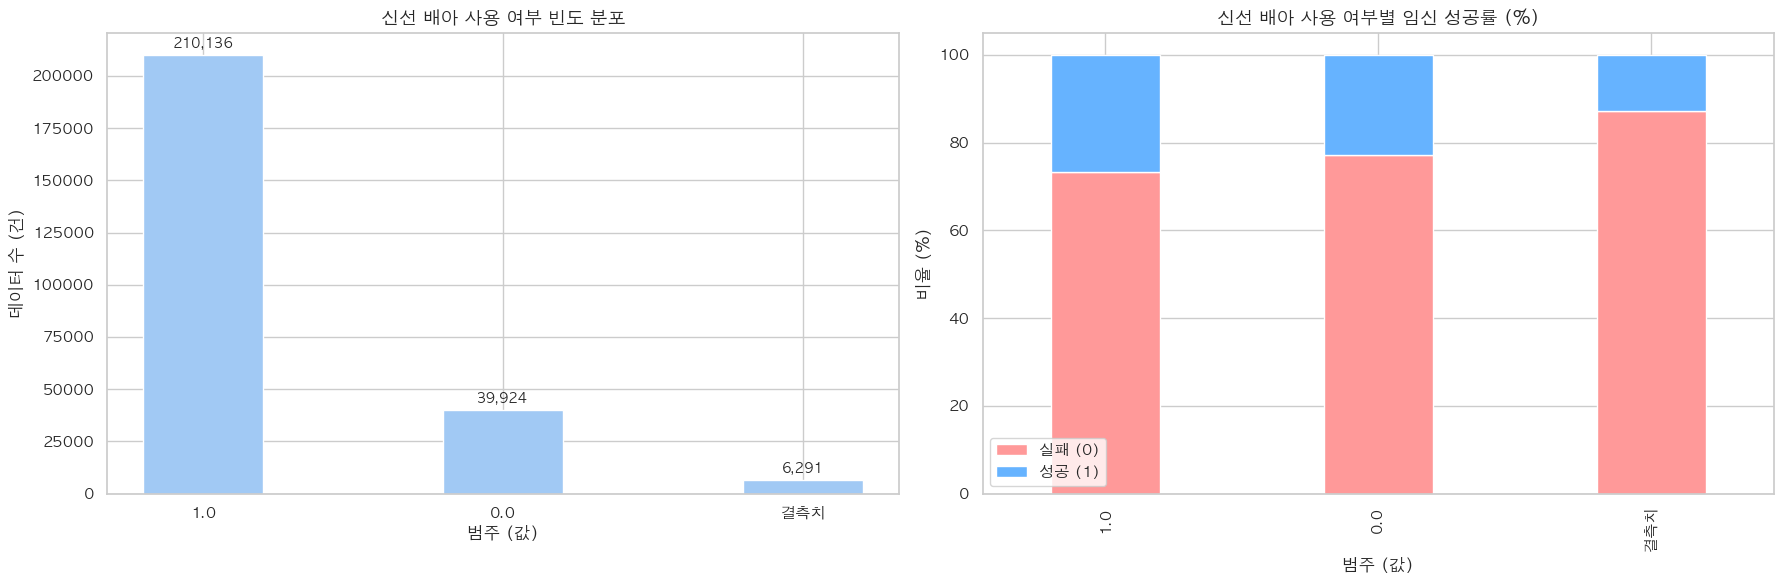


[24/27] [범주형-숫자형 분석] 변수명: 기증 배아 사용 여부


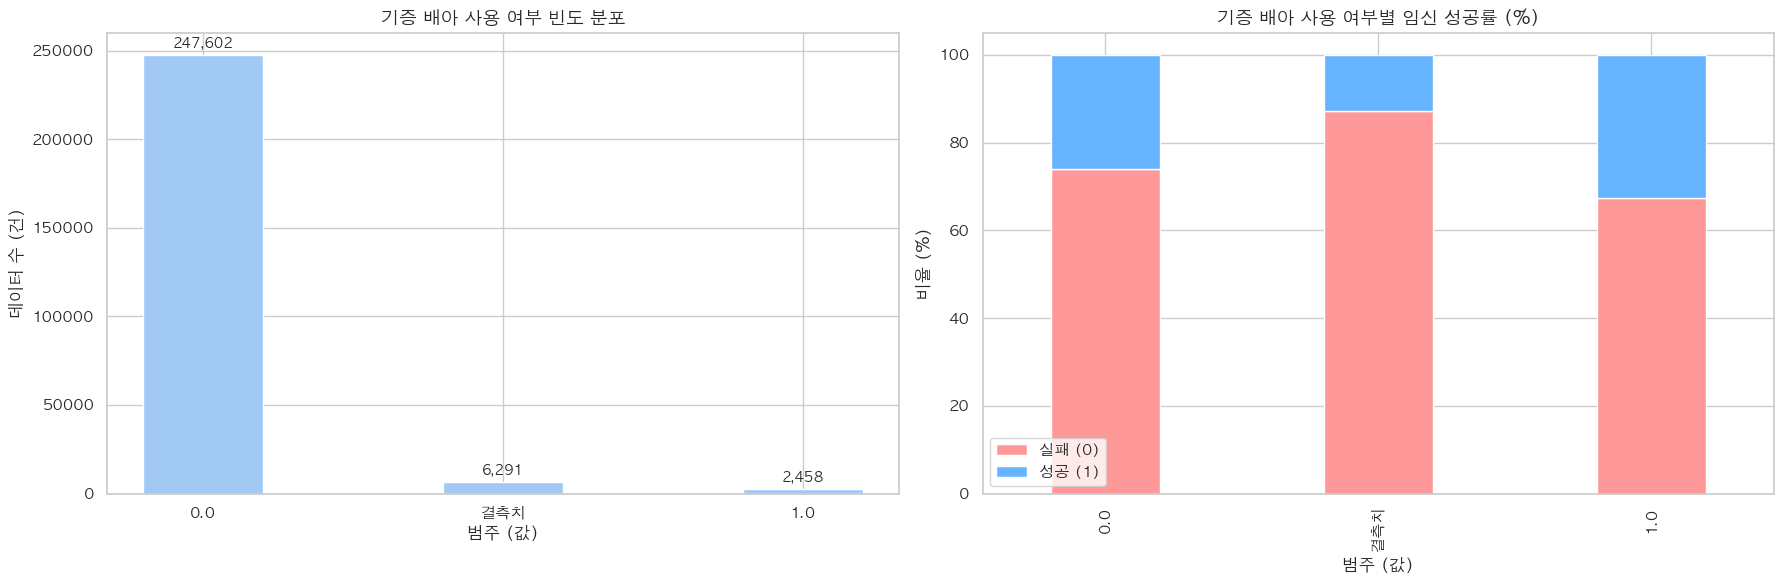


[25/27] [범주형-숫자형 분석] 변수명: 대리모 여부


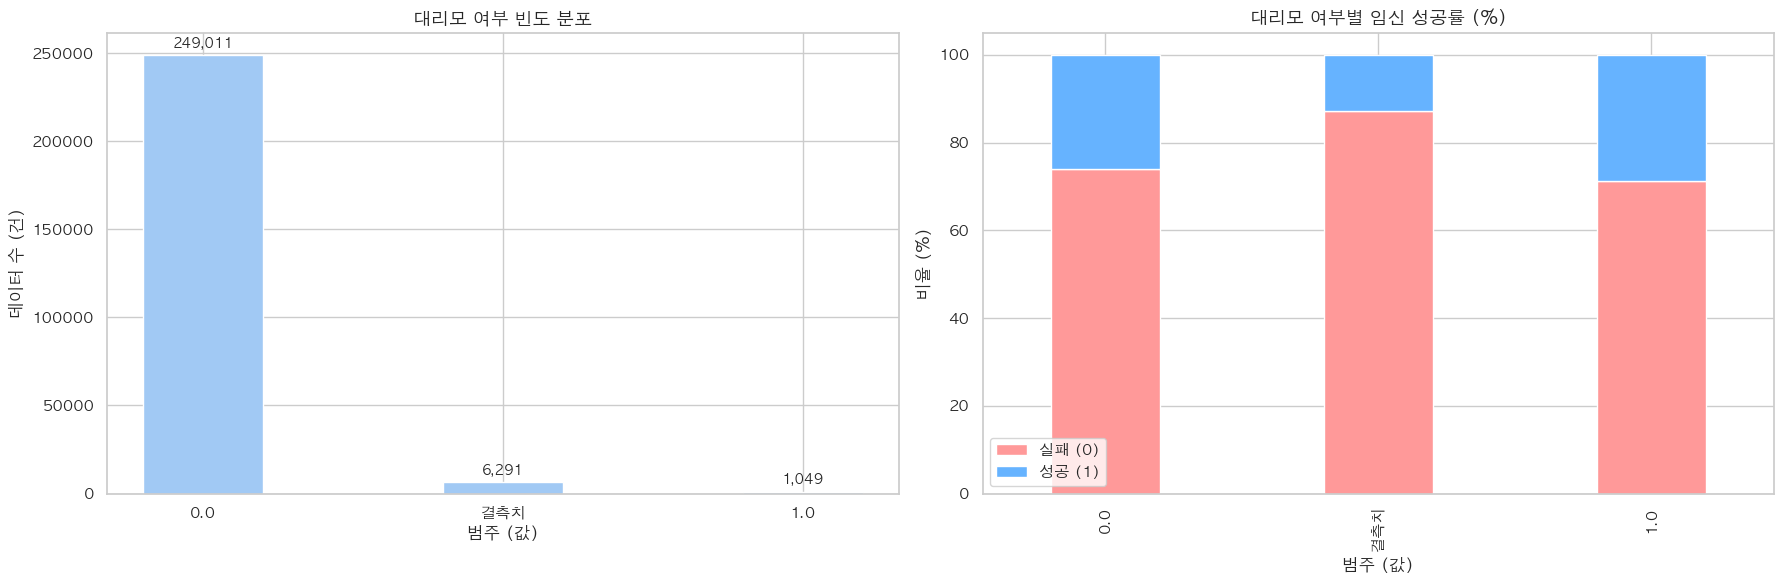


[26/27] [범주형-숫자형 분석] 변수명: PGD 시술 여부


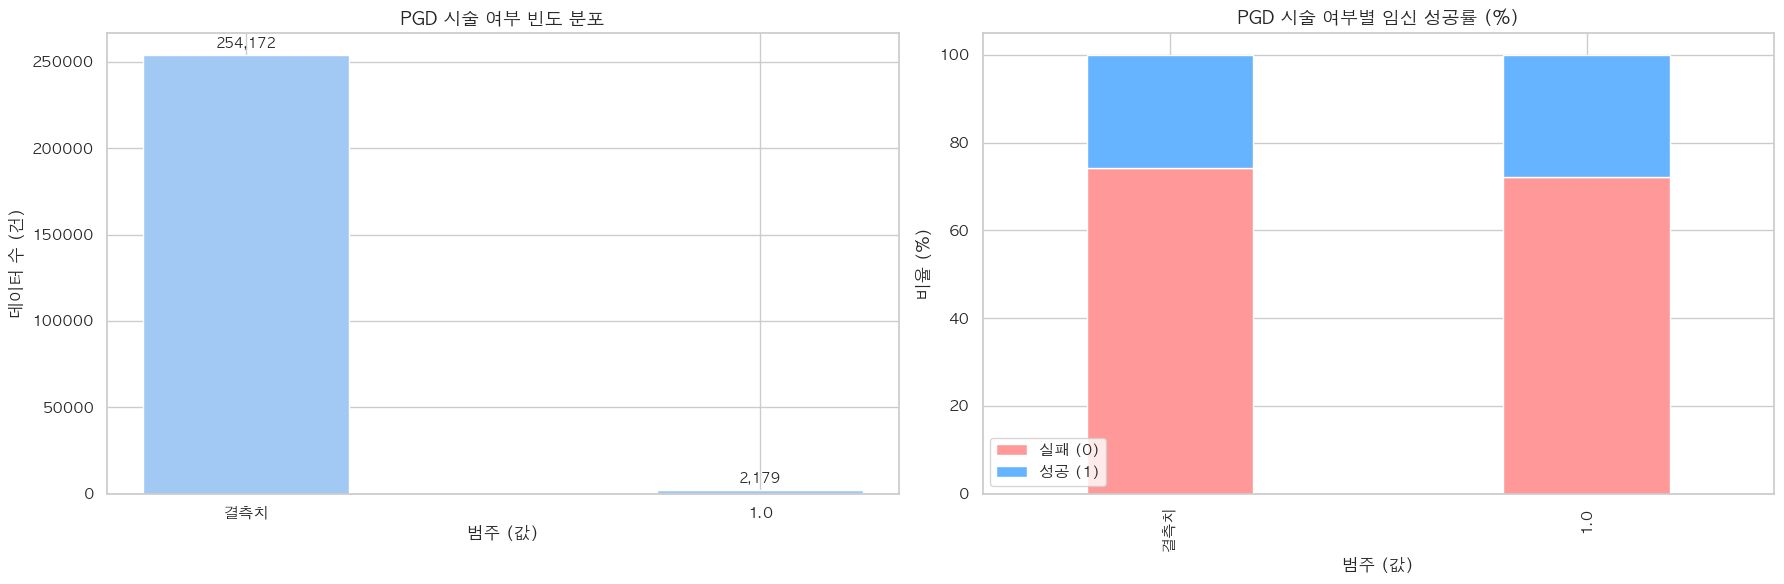


[27/27] [범주형-숫자형 분석] 변수명: PGS 시술 여부


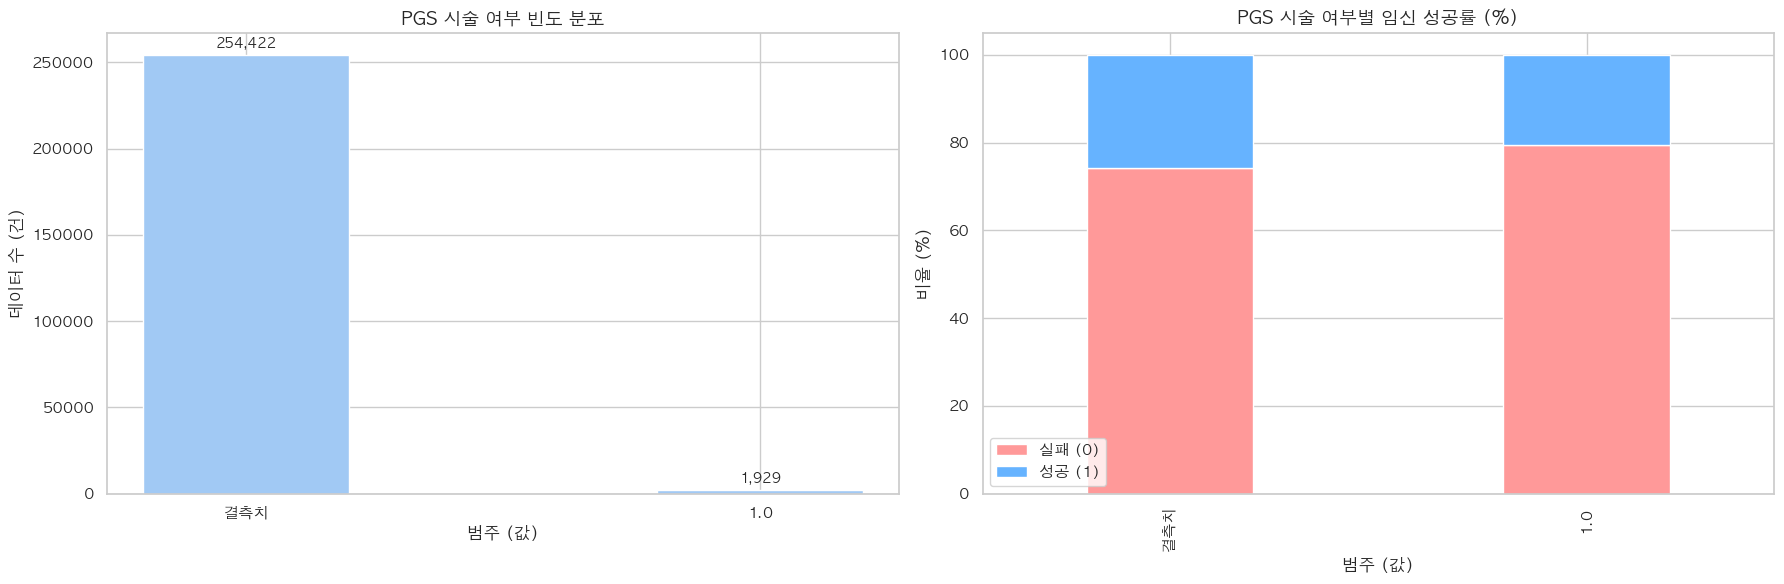

In [18]:
# 숫자형-범주형 변수 분석
for i, col in enumerate(categorical_numeric_columns):
    if col not in train.columns:
        continue

    print(f"\n[{i+1}/{len(categorical_numeric_columns)}] [범주형-숫자형 분석] 변수명: {col}")

    # 결측치가 "특정 시술, 검사 진행 X, ..." 같은 유의미함을 담고 있을 가능성이 있어
    # '결측치' 라는 문자열 범주로 채운 뒤 분석.
    plot_df = train[[col, '임신 성공 여부']].copy()
    plot_df[col] = plot_df[col].fillna('결측치').astype(str)

    custom_order = plot_df[col].value_counts().index.tolist()   # 빈도 높은 순대로 정렬 위한 인덱스 리스트

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    counts = plot_df[col].value_counts().reindex(custom_order)

    # [왼쪽] Count Bar Plot - 빈도 분포
    axes[0].bar(counts.index, counts.values, color='#a1c9f4', width=0.4)
    axes[0].set_title(f"{col} 빈도 분포", fontsize=13, fontweight='bold')
    axes[0].set_xlabel('범주 (값)')
    axes[0].set_ylabel('데이터 수 (건)')

    # 각 막대 상단에 빈도수 표시
    for rect in axes[0].patches:
        height = rect.get_height()
        axes[0].annotate(
            f'{int(height):,}',
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=10
        )

    # [오른쪽] Stacked Bar Plot - 임신 성공 여부
    cross_tab = (
        plot_df.groupby(col)['임신 성공 여부']
        .value_counts(normalize=True)
        .unstack(fill_value=0) * 100
    )

    # 특정 범주 에러 보장
    for c in [0, 1]:
        if c not in cross_tab.columns:
            cross_tab[c] = 0.0

    cross_tab = cross_tab[[0, 1]].reindex(custom_order) # 빈도순 행 정렬
    # 누적 막대 그래프
    cross_tab.plot(
        kind='bar',
        stacked=True,
        ax=axes[1],
        width=0.4,
        color=['#ff9999', '#66b3ff']
    )

    axes[1].set_title(f"{col}별 임신 성공률 (%)", fontsize=13, fontweight='bold')
    axes[1].set_xlabel('범주 (값)')
    axes[1].set_ylabel('비율 (%)')
    axes[1].legend(['실패 (0)', '성공 (1)'], loc='lower left')

    plt.tight_layout()
    plt.show()

### 2-3. 결측치 분석

> 각 변수의 결측치 개수 및 비율을 확인하고, 결측치가 존재하는 feature의 값 분포를 파악합니다.

In [19]:
# 결측치 분석
train.isnull().sum()

ID                            0
시술 시기 코드                      0
시술 당시 나이                      0
임신 시도 또는 마지막 임신 경과 연수    246981
시술 유형                         0
                          ...  
난자 해동 경과일                254915
난자 혼합 경과일                 53735
배아 이식 경과일                 43566
배아 해동 경과일                215982
임신 성공 여부                      0
Length: 69, dtype: int64

총 69개 변수 중 결측치가 존재하는 변수: 31개
                       결측치 개수  결측치 비율(%)
난자 해동 경과일              254915  99.439831
PGS 시술 여부              254422  99.247516
PGD 시술 여부              254172  99.149994
착상 전 유전 검사 사용 여부       253633  98.939735
임신 시도 또는 마지막 임신 경과 연수  246981  96.344855
배아 해동 경과일              215982  84.252451
난자 채취 경과일               57488  22.425503
난자 혼합 경과일               53735  20.961494
배아 이식 경과일               43566  16.994667
총 생성 배아 수                6291   2.454057
기증자 정자와 혼합된 난자 수         6291   2.454057
단일 배아 이식 여부              6291   2.454057
착상 전 유전 진단 사용 여부         6291   2.454057
배아 생성 주요 이유              6291   2.454057
대리모 여부                   6291   2.454057
기증 배아 사용 여부              6291   2.454057
신선 배아 사용 여부              6291   2.454057
동결 배아 사용 여부              6291   2.454057
파트너 정자와 혼합된 난자 수         6291   2.454057
미세주입된 난자 수               6291   2.454057
혼합된 난자 수                 6291   2.454057
저장된 신선 난자 수              6291   2.454057
해동 난자 수                  629

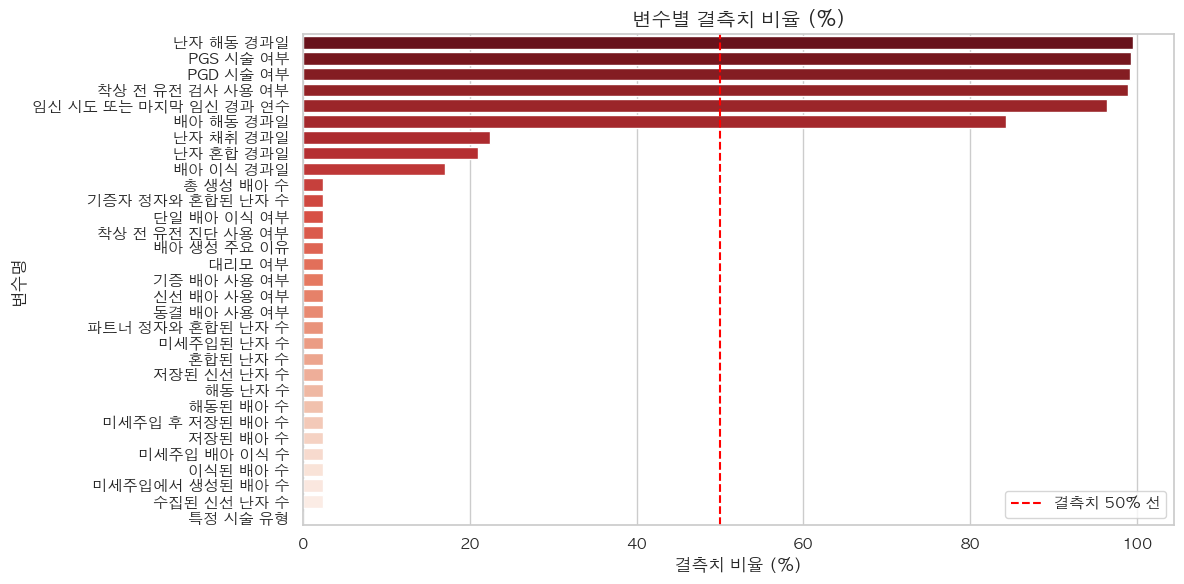

In [20]:
# 결측치 수치 요약 표 생성
missing_count = train.isnull().sum()    # 결측치 개수
missing_ratio = (train.isnull().sum() / len(train)) * 100   # 결측치 비율

missing_df = pd.DataFrame({'결측치 개수': missing_count, '결측치 비율(%)': missing_ratio})
missing_df = missing_df[missing_df['결측치 개수'] > 0].sort_values(by='결측치 비율(%)', ascending=False)

print("="*50)
print(f"총 {train.shape[1]}개 변수 중 결측치가 존재하는 변수: {len(missing_df)}개")
print("="*50)
print(missing_df)

if not missing_df.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(
        x=missing_df['결측치 비율(%)'],
        y=missing_df.index,
        palette='Reds_r',
        hue=missing_df.index,
        legend=False
    )
    plt.title('변수별 결측치 비율 (%)', fontsize=14, fontweight='bold')
    plt.xlabel('결측치 비율 (%)')
    plt.ylabel('변수명')
    plt.axvline(x=50, color='red', linestyle='--', linewidth=1.5, label='결측치 50% 선')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [21]:
# 결측치가 존재하는 feature 카테고리 별 분포도
features = [
    '임신 시도 또는 마지막 임신 경과 연수', '특정 시술 유형', '단일 배아 이식 여부',
    '착상 전 유전 검사 사용 여부', '착상 전 유전 진단 사용 여부', '배아 생성 주요 이유',
    '총 생성 배아 수', '미세주입된 난자 수', '미세주입에서 생성된 배아 수',
    '이식된 배아 수', '미세주입 배아 이식 수', '저장된 배아 수',
    '미세주입 후 저장된 배아 수', '해동된 배아 수', '해동 난자 수',
    '수집된 신선 난자 수', '저장된 신선 난자 수', '혼합된 난자 수',
    '파트너 정자와 혼합된 난자 수', '기증자 정자와 혼합된 난자 수',
    '동결 배아 사용 여부', '신선 배아 사용 여부', '기증 배아 사용 여부',
    '대리모 여부', 'PGD 시술 여부', 'PGS 시술 여부',
    '난자 채취 경과일', '난자 해동 경과일', '난자 혼합 경과일',
    '배아 이식 경과일', '배아 해동 경과일'
]

for col in features:
    print("=" * 60)
    print(f"[{col}]")
    counts = train[col].value_counts(dropna=False)
    ratios = train[col].value_counts(dropna=False, normalize=True) * 100
    result = pd.DataFrame({'count': counts, 'ratio(%)': ratios.round(2)})
    print(result)

[임신 시도 또는 마지막 임신 경과 연수]
                        count  ratio(%)
임신 시도 또는 마지막 임신 경과 연수                  
NaN                    246981     96.34
7.0                      1214      0.47
8.0                      1176      0.46
9.0                      1023      0.40
6.0                       991      0.39
10.0                      947      0.37
11.0                      701      0.27
5.0                       692      0.27
12.0                      510      0.20
13.0                      481      0.19
14.0                      331      0.13
4.0                       305      0.12
15.0                      254      0.10
16.0                      202      0.08
17.0                      140      0.05
18.0                      106      0.04
3.0                        89      0.03
19.0                       86      0.03
20.0                       83      0.03
2.0                        21      0.01
0.0                        12      0.00
1.0                         6      0.00
[특정 시술 유형]
     

### 2-4. 이상치 및 다중공선성 분석

> IQR 기반 이상치 및 왜도(Skewness)를 진단하고, 연속형 변수 간 상관관계 히트맵으로 다중공선성을 확인합니다.

 [이상치 및 왜도 진단 결과]
                  변수명  데이터 건수  평균값  최대값  IQR 상한선  이상치 개수  이상치 비율(%)  왜도(Skewness)
      미세주입 후 저장된 배아 수  250060 0.61 51.0      0.0   45766      18.30          5.33
             해동된 배아 수  250060 0.45 32.0      0.0   40385      16.15          5.13
     기증자 정자와 혼합된 난자 수  250060 0.53 50.0      0.0   15514       6.20          6.03
             저장된 배아 수  250060 1.19 51.0      5.0   14218       5.69          3.78
      미세주입에서 생성된 배아 수  250060 2.84 43.0     12.5    8524       3.41          1.74
임신 시도 또는 마지막 임신 경과 연수    9370 9.27 20.0     17.0     287       3.06          0.73
           미세주입된 난자 수  250060 4.17 51.0     17.5    7511       3.00          1.49
             혼합된 난자 수  250060 7.70 51.0     23.0    5314       2.13          0.99
            배아 해동 경과일   40369 0.05  7.0      0.0     568       1.41         10.37
            총 생성 배아 수  250060 5.06 51.0     18.5    3312       1.32          1.19
          수집된 신선 난자 수  250060 8.56 51.0     29.5    2733       1.09          0.8

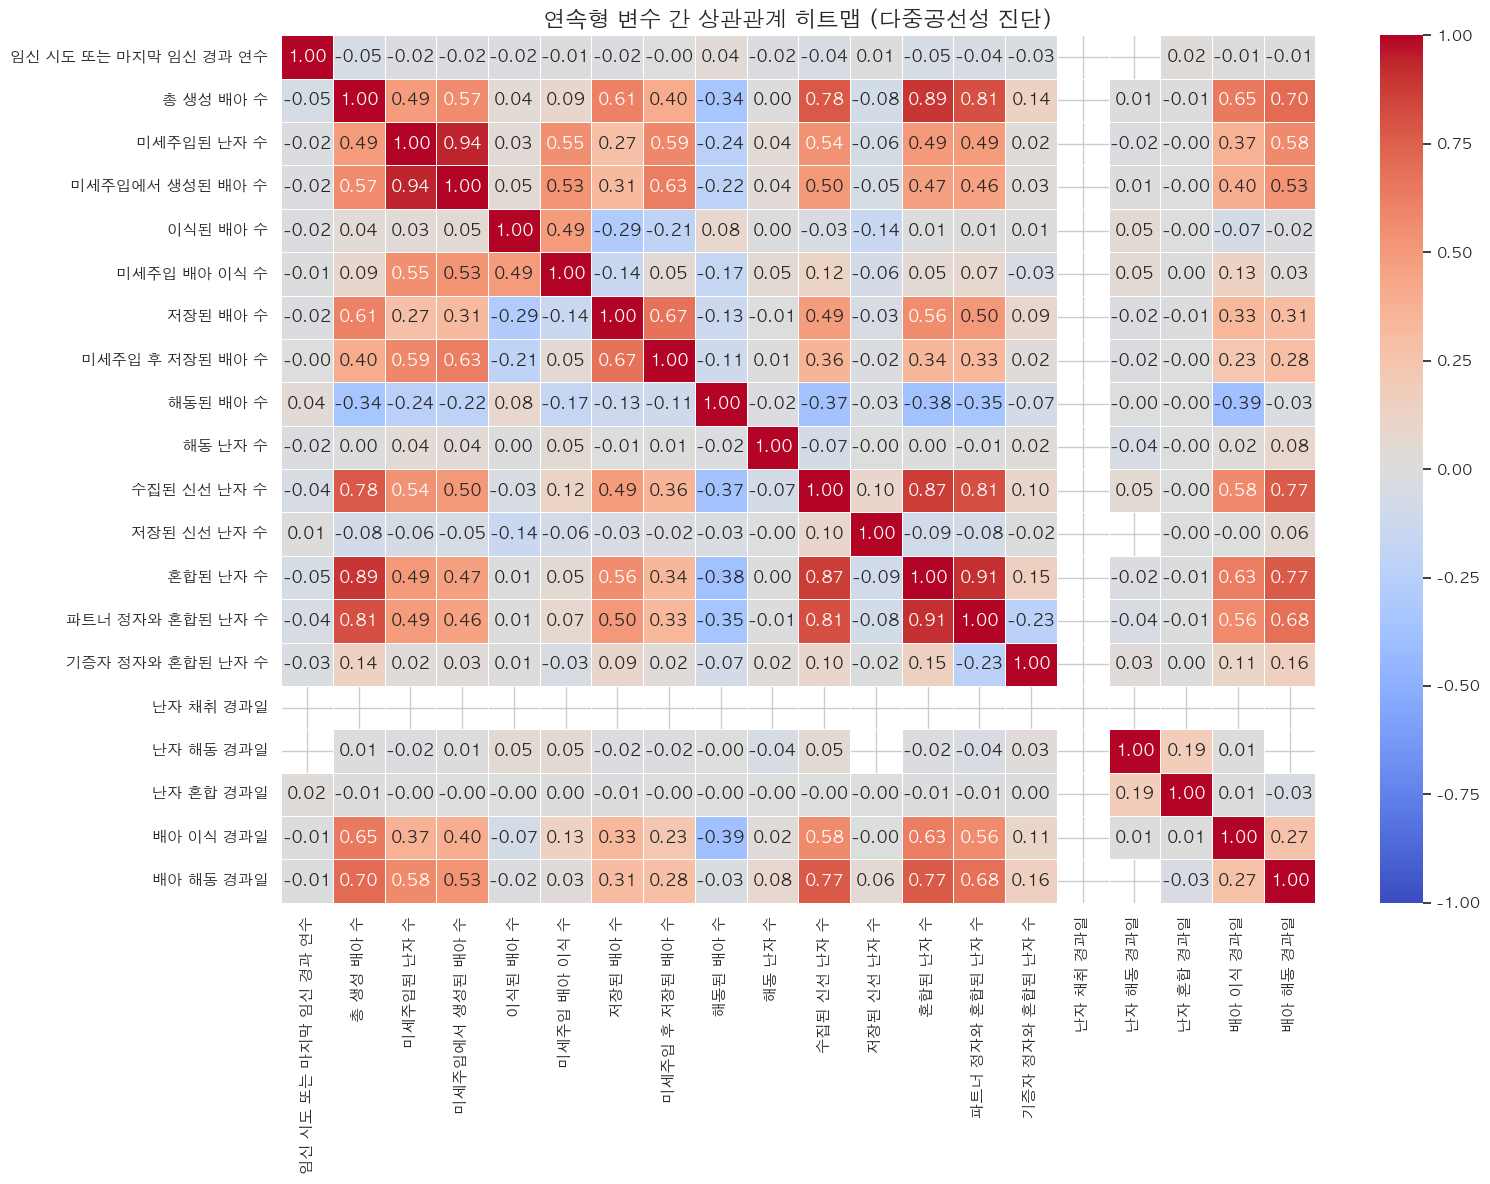

In [22]:
# 숫자형-연속형 변수에 대한 이상치 분석: 이상치 분석 -> 왜도 분석 -> 다중공선성 분석
def diagnose_numeric_columns(df, columns):
    diagnostic_summary = []
    for col in columns:
        if col not in df.columns:
            continue

        # 결측치 대리값(-1) 제외 순수 양수 데이터 추출해 분석
        pure_data = df[df[col] >= 0][col]

        if pure_data.empty:
            continue

        # 왜도 분석
        skewness = pure_data.skew()

        # IQR 기반 이상치 계산
        Q1, Q3 = pure_data.quantile(0.25), pure_data.quantile(0.75)
        IQR = Q3 - Q1
        upper_bound = Q3 + 1.5 * IQR
        lower_bound = Q1 - 1.5 * IQR
        outliers = pure_data[(pure_data < lower_bound) | (pure_data > upper_bound)]

        diagnostic_summary.append({
            '변수명': col,
            '데이터 건수': len(pure_data),
            '평균값': round(pure_data.mean(), 2),
            '최대값': pure_data.max(),
            'IQR 상한선': round(upper_bound, 2),
            '이상치 개수': len(outliers),
            '이상치 비율(%)': round((len(outliers) / len(pure_data)) * 100, 2),
            '왜도(Skewness)': round(skewness, 2)
        })
    return pd.DataFrame(diagnostic_summary).sort_values(by='이상치 비율(%)', ascending=False)

# 결측치 임시 처리 후 분석
train_for_diag = train.copy()
for col in continuous_numeric_columns:
    if col in train_for_diag.columns:
        train_for_diag[col] = train_for_diag[col].fillna(-1)

# 이상치 및 왜도 종합 진단
analysis_report = diagnose_numeric_columns(train_for_diag, continuous_numeric_columns)
print("=" * 85)
print(" [이상치 및 왜도 진단 결과]")
print("=" * 85)
print(analysis_report.to_string(index=False))

# 분석 대상 컬럼들만 추출(결측치 처리된 상태)
corr_df = train_for_diag[continuous_numeric_columns].replace(-1, np.nan)

# 상관관계 행렬 계산
corr_matrix = corr_df.corr()

# heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title('연속형 변수 간 상관관계 히트맵 (다중공선성 진단)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. 최종 전처리 파이프라인

In [23]:
# 결측치 처리
def final_data_preprocessing(df_input):
    df = df_input.copy()

    # 특정 시술 유형 (str) -> 단 2건이므로 기존 'Unknown' 범주로 대체
    if "특정 시술 유형" in df.columns:
        df["특정 시술 유형"] = df["특정 시술 유형"].fillna("Unknown")

    # 임신 시도 연수 결측치 -> -1 (정보 없음)
    if "임신 시도 또는 마지막 임신 경과 연수" in df.columns:
        df["임신 시도 또는 마지막 임신 경과 연수"] = df["임신 시도 또는 마지막 임신 경과 연수"].fillna(-1)

    # IVF 관련 수치형 변수 결측치 -> 0 (DI 환자에게 해당 없음)
    pattern1_numeric = [
        "총 생성 배아 수", "미세주입된 난자 수", "미세주입에서 생성된 배아 수",
        "이식된 배아 수", "미세주입 배아 이식 수", "저장된 배아 수",
        "미세주입 후 저장된 배아 수", "해동된 배아 수", "해동 난자 수",
        "수집된 신선 난자 수", "저장된 신선 난자 수", "혼합된 난자 수",
        "파트너 정자와 혼합된 난자 수", "기증자 정자와 혼합된 난자 수"
    ]
    for col in pattern1_numeric:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    # 여부형 범주형 변수 결측치 -> -1 (해당 시술 없음)
    pattern1_categorical = [
        "단일 배아 이식 여부", "동결 배아 사용 여부", "신선 배아 사용 여부",
        "기증 배아 사용 여부", "대리모 여부", "착상 전 유전 진단 사용 여부"
    ]
    for col in pattern1_categorical:
        if col in df.columns:
            df[col] = df[col].fillna(-1)

    # 배아 생성 주요 이유 결측치 -> 해당없음
    if "배아 생성 주요 이유" in df.columns:
        df["배아 생성 주요 이유"] = df["배아 생성 주요 이유"].fillna("해당없음")

    # 유전 검사 변수 결측치 -> 0 (미시행)
    pattern2_cols = ["PGS 시술 여부", "PGD 시술 여부", "착상 전 유전 검사 사용 여부"]
    for col in pattern2_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    # 경과일 변수 결측치 -> -1 (시술 방식 차이)
    pattern3_cols = [
        "난자 채취 경과일", "난자 해동 경과일", "난자 혼합 경과일",
        "배아 이식 경과일", "배아 해동 경과일"
    ]
    for col in pattern3_cols:
        if col in df.columns:
            df[col] = df[col].fillna(-1)

    # 분산이 0인 예측력 없는 변수 제거
    if "불임 원인 - 여성 요인" in df.columns:
        df = df.drop(columns=["불임 원인 - 여성 요인"])

    return df

# 최종 결측치 개수 확인
train_preprocessed = final_data_preprocessing(train)
test_preprocessed  = final_data_preprocessing(test)
print(f"train 결측치: {train_preprocessed.isnull().sum().sum()}개")
print(f"test  결측치: {test_preprocessed.isnull().sum().sum()}개")

train 결측치: 0개
test  결측치: 0개


In [24]:
# 희소 범주 처리: train 기준으로 파악 후 train/test 동시 적용
def handle_rare_categories(train_df, test_df, cols, threshold_ratio=0.001):
    threshold = max(10, int(len(train_df) * threshold_ratio))
    rare_map = {}

    for col in cols:
        if col not in train_df.columns:
            continue
        value_counts   = train_df[col].value_counts()
        rare_cats      = value_counts[value_counts <= threshold].index.tolist()
        rare_map[col]  = rare_cats

        train_df[col] = train_df[col].replace(rare_cats, 'Unknown')
        if col in test_df.columns:
            test_df[col] = test_df[col].replace(rare_cats, 'Unknown')

    return train_df, test_df, rare_map

rare_cols = ["특정 시술 유형", "배란 유도 유형", "배아 생성 주요 이유"]
train_preprocessed, test_preprocessed, rare_map = handle_rare_categories(
    train_preprocessed, test_preprocessed, rare_cols
)
print("희소 범주 처리 완료:")
for col, cats in rare_map.items():
    print(f"  [{col}] 희소 범주 {len(cats)}개 → Unknown 처리")

희소 범주 처리 완료:
  [특정 시술 유형] 희소 범주 12개 → Unknown 처리
  [배란 유도 유형] 희소 범주 2개 → Unknown 처리
  [배아 생성 주요 이유] 희소 범주 8개 → Unknown 처리


In [25]:
# 파생 변수 생성

AGE_MIDPOINT = {
    '만18-34세': 30, '만35-37세': 36, '만38-39세': 38.5,
    '만40-42세': 41, '만43-44세': 43.5, '만45-50세': 47, '알 수 없음': np.nan
}
DONOR_AGE_MIDPOINT = {
    '만20세 이하': 20, '만21-25세': 23, '만26-30세': 28,
    '만31-35세': 33, '만36-40세': 38, '만41-45세': 43, '알 수 없음': np.nan
}

def create_derived_features(df):
    new_df = df.copy()

    # 배아/난자 품질 비율 변수 5종
    new_df["난자 대비 배아 생성률"]  = new_df["총 생성 배아 수"] / (new_df["혼합된 난자 수"] + 1e-5)
    new_df["생성 배아 대비 이식률"]  = new_df["이식된 배아 수"] / (new_df["총 생성 배아 수"] + 1e-5)
    new_df["생성 배아 대비 저장률"]  = new_df["저장된 배아 수"] / (new_df["총 생성 배아 수"] + 1e-5)
    new_df["미세주입 성공률"]        = new_df["미세주입에서 생성된 배아 수"] / (new_df["미세주입된 난자 수"] + 1e-5)
    new_df["난자 활용률"]            = new_df["혼합된 난자 수"] / (new_df["수집된 신선 난자 수"] + 1e-5)

    # 시술 이행 여부 이진 변수 3종
    new_df["이식 시행 여부"]    = (new_df["이식된 배아 수"] > 0).astype(int)
    new_df["동결 배아 보유 여부"] = (new_df["저장된 배아 수"] > 0).astype(int)
    new_df["미세주입 시행 여부"] = (new_df["미세주입된 난자 수"] > 0).astype(int)

    # 이식 배아 중 미세주입 비율
    new_df["이식 중 미세주입 비율"] = new_df["미세주입 배아 이식 수"] / (new_df["이식된 배아 수"] + 1e-5)

    # 기증 난자 사용 여부 (단순 binary)
    new_df["is_donor_egg"] = (new_df["난자 출처"] == "기증 제공").astype(int)

    # effective_maternal_age: 기증이면 donor 나이, 아니면 환자 나이
    # 배아 품질은 난자 제공자 나이에 의존
    patient_age_num = new_df["시술 당시 나이"].map(AGE_MIDPOINT)
    donor_age_num   = new_df["난자 기증자 나이"].map(DONOR_AGE_MIDPOINT)
    new_df["effective_maternal_age"] = np.where(
        new_df["is_donor_egg"] == 1,
        donor_age_num,
        patient_age_num
    )
    # 이식 경과일 이진 피처
    new_df["이식_5일이상"] = (new_df["배아 이식 경과일"] >= 5).astype(int)

    # 이식일 × 배아수 교호작용
    # 배아를 몇 일째에 이식했는지에 따라 배아 수가 임신 성공에 미치는 영향이 달라질 수 있다는 관계를 모델이 학습하도록 만든 변수
    new_df["이식일_배아수_상호작용"] = new_df["이식_5일이상"] * new_df["이식된 배아 수"] # 여기까지가 최고점.

    return new_df

train_preprocessed = create_derived_features(train_preprocessed)
test_preprocessed  = create_derived_features(test_preprocessed)
print(f"train 컬럼 수: {train_preprocessed.shape[1]}")
print(f"test  컬럼 수: {test_preprocessed.shape[1]}")
print(f"추가된 파생변수: is_donor_egg, effective_maternal_age")


train 컬럼 수: 81
test  컬럼 수: 80
추가된 파생변수: is_donor_egg, effective_maternal_age


In [26]:
# 숫자형-범주형 변수 - 노이즈 확인
print("=" * 60)
print("수치형-범주형 변수들의 고유값 검증")
print("=" * 60)
for col in categorical_numeric_columns:
    if col in train_preprocessed.columns:
        unique_vals = train_preprocessed[col].unique()
        print(f"[{col}] 존재 값: {unique_vals}")

수치형-범주형 변수들의 고유값 검증
[배란 자극 여부] 존재 값: [1 0]
[단일 배아 이식 여부] 존재 값: [ 0.  1. -1.]
[착상 전 유전 검사 사용 여부] 존재 값: [0. 1.]
[착상 전 유전 진단 사용 여부] 존재 값: [ 0. -1.  1.]
[남성 주 불임 원인] 존재 값: [0 1]
[남성 부 불임 원인] 존재 값: [0 1]
[여성 주 불임 원인] 존재 값: [0 1]
[여성 부 불임 원인] 존재 값: [0 1]
[부부 주 불임 원인] 존재 값: [0 1]
[부부 부 불임 원인] 존재 값: [0 1]
[불명확 불임 원인] 존재 값: [0 1]
[불임 원인 - 난관 질환] 존재 값: [0 1]
[불임 원인 - 남성 요인] 존재 값: [1 0]
[불임 원인 - 배란 장애] 존재 값: [1 0]
[불임 원인 - 자궁경부 문제] 존재 값: [0 1]
[불임 원인 - 자궁내막증] 존재 값: [0 1]
[불임 원인 - 정자 농도] 존재 값: [0 1]
[불임 원인 - 정자 면역학적 요인] 존재 값: [0 1]
[불임 원인 - 정자 운동성] 존재 값: [0 1]
[불임 원인 - 정자 형태] 존재 값: [0 1]
[동결 배아 사용 여부] 존재 값: [ 0.  1. -1.]
[신선 배아 사용 여부] 존재 값: [ 1.  0. -1.]
[기증 배아 사용 여부] 존재 값: [ 0. -1.  1.]
[대리모 여부] 존재 값: [ 0. -1.  1.]
[PGD 시술 여부] 존재 값: [0. 1.]
[PGS 시술 여부] 존재 값: [0. 1.]


## 4. 모델 학습

### 4-1. 인코딩 준비

> 순서형 변수에 수동 라벨 인코딩을 적용하고, 명목형 문자 변수에 OOF 방식의 타겟 인코딩(누수 방지)을 적용합니다.

In [27]:
# 데이터 인코딩
print("=" * 60)
print(" [1단계] 인코딩 준비")
print("=" * 60)

test_ids = test_preprocessed['ID'].copy()

X_train_full = train_preprocessed.drop(columns=['ID', '임신 성공 여부'])
y_train_full = train_preprocessed['임신 성공 여부']
X_test = test_preprocessed.drop(columns=['ID'])

# 숫자형-범주형 변수 -> 수동 라벨 인코딩 (순서 의미 강제 주입)

# 환자 시술 나이
age_order = {
    '만18-34세': 0, '만35-37세': 1, '만38-39세': 2,
    '만40-42세': 3, '만43-44세': 4, '만45-50세': 5, '알 수 없음': -1
}

# 기증자 나이
donor_age_order = {
    '만20세 이하': 0, '만21-25세': 1, '만26-30세': 2,
    '만31-35세':   3, '만36-40세': 4, '만41-45세': 5, '알 수 없음': -1
}

count_order = {
    '0회': 0, '1회': 1, '2회': 2, '3회': 3,
    '4회': 4, '5회': 5, '6회 이상': 6
}

label_cols_mapping = {
    "시술 당시 나이":        age_order,
    "난자 기증자 나이":      donor_age_order,
    "정자 기증자 나이":      donor_age_order,
    "총 시술 횟수":          count_order,
    "클리닉 내 총 시술 횟수": count_order,
    "IVF 시술 횟수":         count_order,
    "DI 시술 횟수":          count_order,
    "총 임신 횟수":          count_order,
    "IVF 임신 횟수":         count_order,
    "DI 임신 횟수":          count_order,
    "총 출산 횟수":          count_order,
    "IVF 출산 횟수":         count_order,
    "DI 출산 횟수":          count_order,
}

for col, mapping in label_cols_mapping.items():
    if col in X_train_full.columns:
        X_train_full[col] = X_train_full[col].map(mapping).fillna(-1).astype(int)
        X_test[col] = X_test[col].map(mapping).fillna(-1).astype(int)

print("라벨 인코딩 완료")
print(f"X_train_full shape: {X_train_full.shape}")
print(f"X_test shape:       {X_test.shape}")

 [1단계] 인코딩 준비
라벨 인코딩 완료
X_train_full shape: (256351, 79)
X_test shape:       (90067, 79)


In [28]:
# 명목형 문자열 변수 7개
target_enc_cols = [
    "시술 시기 코드", "시술 유형", "특정 시술 유형",
    "배란 유도 유형", "배아 생성 주요 이유", "난자 출처", "정자 출처"
]
global_mean = y_train_full.mean()

# test용 인코딩 맵
test_encoding_maps = {}
for col in target_enc_cols:
    if col in X_train_full.columns:
        test_encoding_maps[col] = y_train_full.groupby(X_train_full[col]).mean().to_dict()
        X_test[col] = X_test[col].apply(lambda x: test_encoding_maps[col].get(x, global_mean))

X_test = X_test.astype(np.float32)
print("test 타겟 인코딩 완료")
print(f"타겟 인코딩 적용 컬럼: {target_enc_cols}")


test 타겟 인코딩 완료
타겟 인코딩 적용 컬럼: ['시술 시기 코드', '시술 유형', '특정 시술 유형', '배란 유도 유형', '배아 생성 주요 이유', '난자 출처', '정자 출처']


In [29]:
# 클래스 불균형 비율: 데이터 기반 자동 계산
neg = (y_train_full == 0).sum()
pos = (y_train_full == 1).sum()
scale_pos_weight = neg / pos

print(f"클래스 분포 | 실패(0): {neg:,}건 | 성공(1): {pos:,}건")
print(f"scale_pos_weight: {scale_pos_weight:.4f}")

클래스 분포 | 실패(0): 190,123건 | 성공(1): 66,228건
scale_pos_weight: 2.8707


### 4-2. Optuna 하이퍼파라미터 최적화

> TPESampler + MedianPruner를 사용한 베이지안 최적화로 LightGBM, XGBoost, CatBoost의 최적 하이퍼파라미터를 탐색합니다.

In [30]:
print("=" * 60)
print(" [2단계] Optuna 하이퍼파라미터 최적화")
print("=" * 60)

# 튜닝용 단일 Fold 분할
skf_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tune_train_idx, tune_val_idx = next(skf_tune.split(X_train_full, y_train_full))

X_tr_tune = X_train_full.iloc[tune_train_idx].copy()
X_va_tune = X_train_full.iloc[tune_val_idx].copy()
y_tr_tune = y_train_full.iloc[tune_train_idx]
y_va_tune = y_train_full.iloc[tune_val_idx]

for col in target_enc_cols:
    if col in X_tr_tune.columns:
        fold_map = y_tr_tune.groupby(X_tr_tune[col]).mean().to_dict()
        X_tr_tune[col] = X_tr_tune[col].apply(lambda x: fold_map.get(x, global_mean))
        X_va_tune[col] = X_va_tune[col].apply(lambda x: fold_map.get(x, global_mean))

X_tr_tune = X_tr_tune.astype(np.float32)
X_va_tune = X_va_tune.astype(np.float32)

sampler = TPESampler(seed=42)
pruner  = MedianPruner(n_startup_trials=5, n_warmup_steps=10)
N_TRIALS = 75

# LightGBM 최적화
def objective_lgb(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'verbose': -1,
        'random_state': 42,
        'scale_pos_weight': scale_pos_weight,
        'learning_rate':      trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves':         trial.suggest_int('num_leaves', 15, 127),
        'max_depth':          trial.suggest_int('max_depth', 4, 12),
        'min_child_samples':  trial.suggest_int('min_child_samples', 10, 100),
        'subsample':          trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':   trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':          trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':         trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
    }
    dtrain = lgb.Dataset(X_tr_tune, label=y_tr_tune)
    dval   = lgb.Dataset(X_va_tune, label=y_va_tune, reference=dtrain)
    model  = lgb.train(
        params, dtrain,
        num_boost_round=500,
        valid_sets=[dval],
        callbacks=[
            lgb.early_stopping(30, verbose=False),
            lgb.log_evaluation(period=-1)
        ]
    )
    score = roc_auc_score(y_va_tune, model.predict(X_va_tune))
    trial.report(score, step=model.best_iteration)
    if trial.should_prune():
        raise optuna.exceptions.TrialPruned()
    return score

# XGBoost 최적화
def objective_xgb(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'random_state': 42,
        'scale_pos_weight': scale_pos_weight,
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth':        trial.suggest_int('max_depth', 4, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
    }
    model = xgb.XGBClassifier(
        **params,
        n_estimators=500,
        early_stopping_rounds=30,
        verbosity=0
    )
    model.fit(X_tr_tune, y_tr_tune, eval_set=[(X_va_tune, y_va_tune)], verbose=False)
    return roc_auc_score(y_va_tune, model.predict_proba(X_va_tune)[:, 1])

# CatBoost 최적화
def objective_cat(trial):
    params = {
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'random_seed': 42,
        'verbose': False,
        'class_weights': {0: 1.0, 1: float(scale_pos_weight)},
        'learning_rate':       trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth':               trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg':         trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength':     trial.suggest_float('random_strength', 1e-3, 10.0, log=True),
    }
    model = CatBoostClassifier(**params, iterations=500, early_stopping_rounds=30)
    model.fit(X_tr_tune, y_tr_tune, eval_set=(X_va_tune, y_va_tune), use_best_model=True)
    return roc_auc_score(y_va_tune, model.predict_proba(X_va_tune)[:, 1])

# 베이지안 서치 튜닝 가동
optuna.logging.set_verbosity(optuna.logging.WARNING)

study_lgb = optuna.create_study(direction='maximize', sampler=sampler, pruner=pruner)
study_lgb.optimize(objective_lgb, n_trials=N_TRIALS, show_progress_bar=True)
print(f"LGB 최적 AUC: {study_lgb.best_value:.4f}")
print(f"LGB 최적 파라미터: {study_lgb.best_params}")

study_xgb = optuna.create_study(direction='maximize', sampler=sampler, pruner=pruner)
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=True)
print(f"XGB 최적 AUC: {study_xgb.best_value:.4f}")
print(f"XGB 최적 파라미터: {study_xgb.best_params}")

study_cat = optuna.create_study(direction='maximize', sampler=sampler, pruner=pruner)
study_cat.optimize(objective_cat, n_trials=N_TRIALS, show_progress_bar=True)
print(f"CAT 최적 AUC: {study_cat.best_value:.4f}")
print(f"CAT 최적 파라미터: {study_cat.best_params}")


 [2단계] Optuna 하이퍼파라미터 최적화


  0%|          | 0/75 [00:00<?, ?it/s]

LGB 최적 AUC: 0.7385
LGB 최적 파라미터: {'learning_rate': 0.05145647901779739, 'num_leaves': 93, 'max_depth': 5, 'min_child_samples': 96, 'subsample': 0.8864550600123169, 'colsample_bytree': 0.5038788416660758, 'reg_alpha': 8.23945624262162, 'reg_lambda': 0.0015791156583273662}


  0%|          | 0/75 [00:00<?, ?it/s]

XGB 최적 AUC: 0.7388
XGB 최적 파라미터: {'learning_rate': 0.04459084710634396, 'max_depth': 4, 'min_child_weight': 5, 'subsample': 0.7355236291004573, 'colsample_bytree': 0.6735931155206629, 'reg_alpha': 6.1849782967104225, 'reg_lambda': 0.0001699790943889461}


  0%|          | 0/75 [00:00<?, ?it/s]

CAT 최적 AUC: 0.7386
CAT 최적 파라미터: {'learning_rate': 0.04404990380393765, 'depth': 5, 'l2_leaf_reg': 1.734321728857215, 'bagging_temperature': 0.38887592055765613, 'random_strength': 0.09737486544478541}


### 4-3. 10-Fold × 3-Seed OOF 스태킹

> 10-Fold 교차 검증과 3개 랜덤 시드를 조합(총 90회 학습)하여 OOF 예측값과 테스트 예측값을 생성합니다.

In [31]:
print("=" * 60)
print(" [3단계] 10-Fold × 3-Seed OOF 스태킹")
print("=" * 60)

SEEDS    = [42, 0, 7]
N_SPLITS = 10

# 누적 배열 초기화
lgb_oof        = np.zeros(len(X_train_full))
xgb_oof        = np.zeros(len(X_train_full))
cat_oof        = np.zeros(len(X_train_full))
lgb_test_preds = np.zeros(len(X_test))
xgb_test_preds = np.zeros(len(X_test))
cat_test_preds = np.zeros(len(X_test))

last_lgb_model     = None
last_lgb_best_iter = 0

total_runs = N_SPLITS * len(SEEDS)
run_count  = 0

for seed in SEEDS:
    # seed별 OOF 배열
    lgb_oof_seed = np.zeros(len(X_train_full))
    xgb_oof_seed = np.zeros(len(X_train_full))
    cat_oof_seed = np.zeros(len(X_train_full))

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_full, y_train_full)):
        run_count += 1
        X_tr = X_train_full.iloc[train_idx].copy()
        X_va = X_train_full.iloc[val_idx].copy()
        y_tr = y_train_full.iloc[train_idx]
        y_va = y_train_full.iloc[val_idx]

        for col in target_enc_cols:
            if col in X_tr.columns:
                fold_map = y_tr.groupby(X_tr[col]).mean().to_dict()
                X_tr[col] = X_tr[col].apply(lambda x: fold_map.get(x, global_mean))
                X_va[col] = X_va[col].apply(lambda x: fold_map.get(x, global_mean))

        X_tr = X_tr.astype(np.float32)
        X_va = X_va.astype(np.float32)

        # LightGBM
        lgb_params = {
            'objective': 'binary', 'metric': 'auc',
            'verbose': -1, 'random_state': seed,
            'scale_pos_weight': scale_pos_weight
        }
        lgb_params.update(study_lgb.best_params)
        dtrain    = lgb.Dataset(X_tr, label=y_tr)
        dval      = lgb.Dataset(X_va, label=y_va, reference=dtrain)
        model_lgb = lgb.train(
            lgb_params, dtrain, num_boost_round=1000,
            valid_sets=[dval],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)]
        )
        lgb_oof_seed[val_idx]  = model_lgb.predict(X_va)
        lgb_test_preds        += model_lgb.predict(X_test) / total_runs
        last_lgb_model         = model_lgb
        last_lgb_best_iter     = model_lgb.best_iteration

        # XGBoost
        xgb_params = {
            'objective': 'binary:logistic', 'eval_metric': 'auc',
            'random_state': seed, 'scale_pos_weight': scale_pos_weight, 'verbosity': 0
        }
        xgb_params.update(study_xgb.best_params)
        model_xgb = xgb.XGBClassifier(**xgb_params, n_estimators=1000, early_stopping_rounds=50)
        model_xgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        xgb_oof_seed[val_idx]  = model_xgb.predict_proba(X_va)[:, 1]
        xgb_test_preds        += model_xgb.predict_proba(X_test)[:, 1] / total_runs

        # CatBoost
        cat_params = {
            'loss_function': 'Logloss', 'eval_metric': 'AUC',
            'random_seed': seed, 'verbose': False,
            'class_weights': {0: 1.0, 1: float(scale_pos_weight)}
        }
        cat_params.update(study_cat.best_params)
        model_cat = CatBoostClassifier(**cat_params, iterations=1000, early_stopping_rounds=50)
        model_cat.fit(X_tr, y_tr, eval_set=(X_va, y_va), use_best_model=True)
        cat_oof_seed[val_idx]  = model_cat.predict_proba(X_va)[:, 1]
        cat_test_preds        += model_cat.predict_proba(X_test)[:, 1] / total_runs

        print(f"[Seed {seed} | Fold {fold+1:2d}/{N_SPLITS}] "
              f"LGB: {roc_auc_score(y_va, lgb_oof_seed[val_idx]):.4f} | "
              f"XGB: {roc_auc_score(y_va, xgb_oof_seed[val_idx]):.4f} | "
              f"CAT: {roc_auc_score(y_va, cat_oof_seed[val_idx]):.4f} "
              f"({run_count}/{total_runs})")

    # seed별 OOF AUC 출력
    print(f"\n[Seed {seed} OOF AUC]")
    print(f"  LGB: {roc_auc_score(y_train_full, lgb_oof_seed):.4f}")
    print(f"  XGB: {roc_auc_score(y_train_full, xgb_oof_seed):.4f}")
    print(f"  CAT: {roc_auc_score(y_train_full, cat_oof_seed):.4f}")
    print()

    # seed별 OOF를 전체 OOF에 누적 평균
    lgb_oof += lgb_oof_seed / len(SEEDS)
    xgb_oof += xgb_oof_seed / len(SEEDS)
    cat_oof += cat_oof_seed / len(SEEDS)

# 최종 전체 OOF AUC
print("=" * 60)
print("[최종 전체 OOF AUC (10-Fold × 3-Seed 평균)]")
print(f"  LGB: {roc_auc_score(y_train_full, lgb_oof):.4f}")
print(f"  XGB: {roc_auc_score(y_train_full, xgb_oof):.4f}")
print(f"  CAT: {roc_auc_score(y_train_full, cat_oof):.4f}")
print("=" * 60)

 [3단계] 10-Fold × 3-Seed OOF 스태킹
[Seed 42 | Fold  1/10] LGB: 0.7438 | XGB: 0.7438 | CAT: 0.7434 (1/30)
[Seed 42 | Fold  2/10] LGB: 0.7325 | XGB: 0.7325 | CAT: 0.7330 (2/30)
[Seed 42 | Fold  3/10] LGB: 0.7396 | XGB: 0.7396 | CAT: 0.7393 (3/30)
[Seed 42 | Fold  4/10] LGB: 0.7461 | XGB: 0.7465 | CAT: 0.7464 (4/30)
[Seed 42 | Fold  5/10] LGB: 0.7429 | XGB: 0.7434 | CAT: 0.7431 (5/30)
[Seed 42 | Fold  6/10] LGB: 0.7373 | XGB: 0.7377 | CAT: 0.7369 (6/30)
[Seed 42 | Fold  7/10] LGB: 0.7372 | XGB: 0.7372 | CAT: 0.7367 (7/30)
[Seed 42 | Fold  8/10] LGB: 0.7398 | XGB: 0.7405 | CAT: 0.7403 (8/30)
[Seed 42 | Fold  9/10] LGB: 0.7418 | XGB: 0.7419 | CAT: 0.7413 (9/30)
[Seed 42 | Fold 10/10] LGB: 0.7402 | XGB: 0.7404 | CAT: 0.7399 (10/30)

[Seed 42 OOF AUC]
  LGB: 0.7401
  XGB: 0.7403
  CAT: 0.7400

[Seed 0 | Fold  1/10] LGB: 0.7426 | XGB: 0.7431 | CAT: 0.7428 (11/30)
[Seed 0 | Fold  2/10] LGB: 0.7363 | XGB: 0.7357 | CAT: 0.7357 (12/30)
[Seed 0 | Fold  3/10] LGB: 0.7427 | XGB: 0.7428 | CAT: 0.7424 (13

### 4-4. SHAP 분석 + Noise Pruning

> 최종 LGB 모델 기반 SHAP으로 변수 중요도를 분석하고, FI=0 및 타겟 저상관 노이즈 변수를 제거합니다.

 [4단계] SHAP 분석 + Noise Pruning


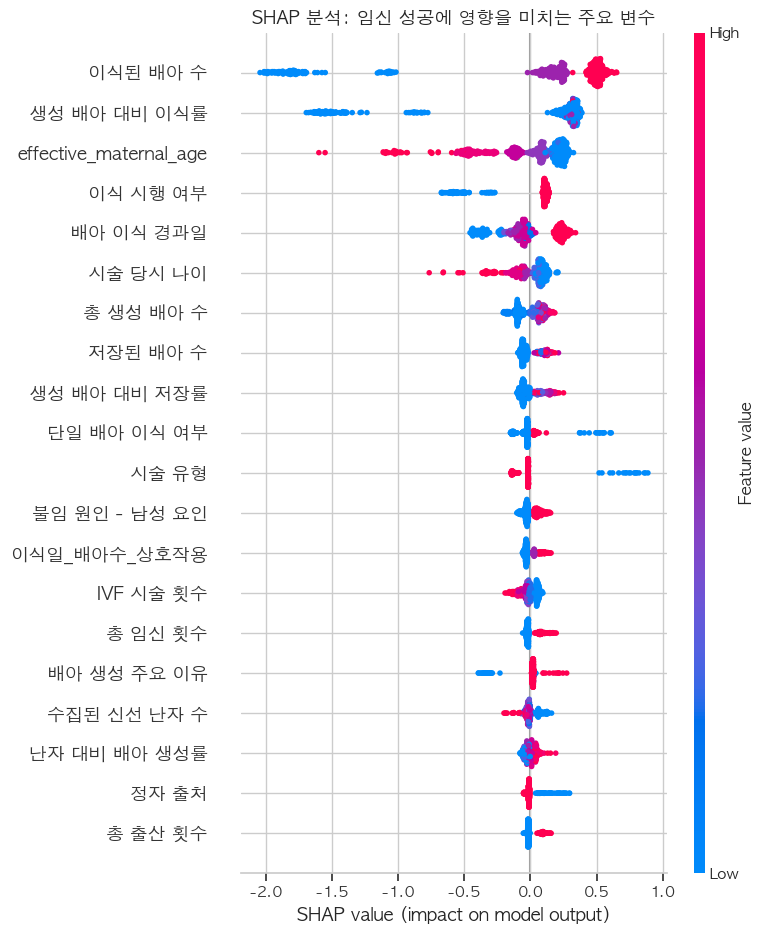


Feature Importance Top 20:
               feature    importance
              이식된 배아 수 234806.466880
          생성 배아 대비 이식률 150994.478768
             배아 이식 경과일 121929.263791
effective_maternal_age  90708.741478
              저장된 배아 수  33111.393109
                 시술 유형  31392.644541
              시술 당시 나이  29801.382285
              이식 시행 여부  26104.894665
           단일 배아 이식 여부  24015.039254
             총 생성 배아 수  22018.622615
          생성 배아 대비 저장률  18474.069605
          이식일_배아수_상호작용  15049.166400
      착상 전 유전 진단 사용 여부  10515.022167
           동결 배아 보유 여부   9913.128459
               이식_5일이상   8866.092305
           배아 생성 주요 이유   7865.939656
           수집된 신선 난자 수   7177.020986
              시술 시기 코드   4880.420047
                 난자 출처   3951.497938
             IVF 시술 횟수   3883.732460

FI=0 제거 변수 (6개): ['불임 원인 - 정자 운동성', '불임 원인 - 정자 면역학적 요인', '불임 원인 - 정자 형태', '저장된 신선 난자 수', '불임 원인 - 정자 농도', '불임 원인 - 자궁경부 문제']
저상관 제거 변수 (28개): ['불임 원인 - 난관 질환', '불명확 불임 원인', '해동 난자 수', '불임 원인 - 

In [32]:
print("=" * 60)
print(" [4단계] SHAP 분석 + Noise Pruning")
print("=" * 60)

X_full_encoded = X_train_full.copy()
for col in target_enc_cols:
    if col in X_full_encoded.columns:
        full_map = y_train_full.groupby(X_train_full[col]).mean().to_dict()
        X_full_encoded[col] = X_train_full[col].apply(lambda x: full_map.get(x, global_mean))
X_full_encoded = X_full_encoded.astype(np.float32)

# SHAP용 최종 LGB 모델 재학습
lgb_final_params = {
    'objective': 'binary', 'metric': 'auc',
    'verbose': -1, 'random_state': 42,
    'scale_pos_weight': scale_pos_weight
}
lgb_final_params.update(study_lgb.best_params)
dtrain_full   = lgb.Dataset(X_full_encoded, label=y_train_full)
model_lgb_shap = lgb.train(lgb_final_params, dtrain_full, num_boost_round=last_lgb_best_iter)

# SHAP 계산
np.random.seed(42)
sample_idx    = np.random.choice(len(X_full_encoded), size=min(500, len(X_full_encoded)), replace=False)
X_shap_sample = X_full_encoded.iloc[sample_idx]

explainer = shap.TreeExplainer(model_lgb_shap)
shap_vals  = explainer(X_shap_sample)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_vals, X_shap_sample, show=False)
plt.title('SHAP 분석: 임신 성공에 영향을 미치는 주요 변수', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── FI=0 변수만 제거
fi_df = pd.DataFrame({
    'feature':    X_full_encoded.columns,
    'importance': model_lgb_shap.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

print("\nFeature Importance Top 20:")
print(fi_df.head(20).to_string(index=False))


# ── [수정] 2단계 Pruning: FI=0 제거 + 저상관 노이즈 제거

# 1단계: FI=0 제거
zero_fi_cols = fi_df[fi_df['importance'] == 0]['feature'].tolist()
if zero_fi_cols:
    print(f"\nFI=0 제거 변수 ({len(zero_fi_cols)}개): {zero_fi_cols}")
    X_train_full.drop(columns=[c for c in zero_fi_cols if c in X_train_full.columns], inplace=True)
    X_test.drop(columns=[c for c in zero_fi_cols if c in X_test.columns], inplace=True)

# 2단계: 저상관 노이즈 피처 추가 제거 (target 상관 0.02 미만)
low_corr_cols = [
    # ── 0.02 미만
    '불임 원인 - 난관 질환',   # 상관 0.0005
    '불명확 불임 원인',        # 상관 0.0015
    '해동 난자 수',            # 상관 0.0021
    '불임 원인 - 자궁내막증',  # 상관 0.0022
    '난자 혼합 경과일',        # 상관 0.0086
    '해동된 배아 수',          # 상관 0.0149
    '기증 배아 사용 여부',     # 상관 0.0149
    '남성 주 불임 원인',       # 상관 0.0150
    '부부 부 불임 원인',       # 상관 0.0153
    '여성 주 불임 원인',       # 상관 0.0159
    '남성 부 불임 원인',       # 상관 0.0160
    '여성 부 불임 원인',       # 상관 0.0160
    '부부 주 불임 원인',       # 상관 0.0161
    '배아 해동 경과일',        # 상관 0.0173
    '난자 해동 경과일',        # 상관 0.0200
    # ── 신규 추가: 0.02~0.05 미만
    '미세주입 후 저장된 배아 수',           # 상관 0.0217
    '불임 원인 - 배란 장애',               # 상관 0.0250
    '기증자 정자와 혼합된 난자 수',         # 상관 0.0262
    '신선 배아 사용 여부',                 # 상관 0.0318
    '동결 배아 사용 여부',                 # 상관 0.0320
    '배란 자극 여부',                     # 상관 0.0332
    '불임 원인 - 남성 요인',               # 상관 0.0379
    '임신 시도 또는 마지막 임신 경과 연수', # 결측 96% + 상관 0.0519
    '불임 원인 - 여성 요인',               # 전체가 0 → 분산 없음
    '난자 채취 경과일',                   # 값이 모두 0 → 분산 없음
    '대리모 여부',                        # 상관 0.0040
    '착상 전 유전 검사 사용 여부',          # n=2718만 1, 역방향 signal
    'PGD 시술 여부',                      # n=2179만 1 → 소수 그룹
    'PGS 시술 여부',                      # n=1929만 1 → 소수 그룹
]

# FI Top20에 포함된 피처는 보호
fi_top20 = fi_df.head(20)['feature'].tolist()
safe_low_corr = [c for c in low_corr_cols if c not in fi_top20]
actual_removed = [c for c in safe_low_corr if c in X_train_full.columns]

if actual_removed:
    X_train_full.drop(columns=actual_removed, inplace=True)
    X_test.drop(columns=[c for c in actual_removed if c in X_test.columns], inplace=True)
    print(f"저상관 제거 변수 ({len(actual_removed)}개): {actual_removed}")

print(f"\nPruning 후 feature 수: {X_train_full.shape[1]}")


### 4-5. 스태킹 메타 모델

> LGB/XGB/CatBoost의 OOF 예측값을 피처로 사용하여 로지스틱 회귀 메타 모델로 최종 앙상블합니다.

In [33]:
print("=" * 60)
print(" 스태킹 메타 모델 결합 및 신뢰 가능한 OOF 평가")
print("=" * 60)

X_meta_train = pd.DataFrame({'lgb': lgb_oof,        'xgb': xgb_oof,        'cat': cat_oof})
X_meta_test  = pd.DataFrame({'lgb': lgb_test_preds, 'xgb': xgb_test_preds, 'cat': cat_test_preds})

# 메타모델 OOF 평가 (5-Fold CV)
meta_oof_prob = np.zeros(len(X_meta_train))
skf_meta = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

for train_idx, val_idx in skf_meta.split(X_meta_train, y_train_full):
    tmp_meta = LogisticRegression(random_state=42, max_iter=1000)
    tmp_meta.fit(X_meta_train.iloc[train_idx], y_train_full.iloc[train_idx])
    meta_oof_prob[val_idx] = tmp_meta.predict_proba(X_meta_train.iloc[val_idx])[:, 1]

meta_oof_auc = roc_auc_score(y_train_full, meta_oof_prob)
print(f"메타 모델 OOF AUC (신뢰 가능한 수치): {meta_oof_auc:.4f}")

final_oof_pred = (meta_oof_prob >= 0.5).astype(int)
print(f"메타 모델 OOF Accuracy: {accuracy_score(y_train_full, final_oof_pred):.4f}")
print("-" * 60)
print(classification_report(y_train_full, final_oof_pred, target_names=['임신 실패(0)', '임신 성공(1)']))

# 최종 예측: 전체 데이터로 메타모델 재학습
meta_model = LogisticRegression(random_state=42, max_iter=1000)
meta_model.fit(X_meta_train, y_train_full)
final_test_prob = meta_model.predict_proba(X_meta_test)[:, 1]


 [5단계] 스태킹 메타 모델 결합 및 신뢰 가능한 OOF 평가
메타 모델 OOF AUC (신뢰 가능한 수치): 0.7406
메타 모델 OOF Accuracy: 0.7455
------------------------------------------------------------
              precision    recall  f1-score   support

    임신 실패(0)       0.77      0.94      0.85    190123
    임신 성공(1)       0.52      0.17      0.26     66228

    accuracy                           0.75    256351
   macro avg       0.64      0.56      0.55    256351
weighted avg       0.70      0.75      0.70    256351



## 5. 최종 제출 파일 생성

> 메타 모델의 최종 예측 확률을 `submission_타임스탬프.csv`로 저장합니다.

In [34]:
print("=" * 60)
print(" 최종 제출 파일 생성")
print("=" * 60)

from datetime import datetime
timestamp   = datetime.now().strftime("%Y%m%d_%H%M%S")
output_path = f'submission_{timestamp}.csv'

submission_df = pd.DataFrame({
    'ID':          test_ids.values,
    'probability': final_test_prob
})

submission_df.to_csv(output_path, index=False)
print(f"✅ 제출 파일 저장 완료: {output_path}")
print(f"   예측 샘플 수       : {len(submission_df):,}건")
print(f"   probability 범위  : {submission_df['probability'].min():.4f} ~ {submission_df['probability'].max():.4f}")
print(f"   최종 OOF AUC      : {meta_oof_auc:.4f}")
print()
print(submission_df.head(10))


 [6단계] 최종 제출 파일 생성
✅ 제출 파일 저장 완료: submission_20260601_103708.csv
   예측 샘플 수       : 90,067건
   probability 범위  : 0.0245 ~ 0.6975
   최종 OOF AUC      : 0.7406

           ID  probability
0  TEST_00000     0.025791
1  TEST_00001     0.028668
2  TEST_00002     0.130919
3  TEST_00003     0.087861
4  TEST_00004     0.520388
5  TEST_00005     0.105987
6  TEST_00006     0.476418
7  TEST_00007     0.373271
8  TEST_00008     0.245514
9  TEST_00009     0.025546
